In [1]:
import os
import pandas as pd

# Define paths
folder_path = "/home/ray/Dispa-SET/Database/PowerPlants"
output_path = "/home/ray/Downloads/Downloads/DispaSET_Technical_Parameters_Data_Base.csv"

# Initialize an empty DataFrame to store the merged data
merged_data = pd.DataFrame()

# Iterate through all subfolders
for root, dirs, files in os.walk(folder_path):
    for subfolder in dirs:
        subfolder_path = os.path.join(root, subfolder)
        csv_files = [f for f in os.listdir(subfolder_path) if f.endswith('.csv')]

        # Iterate through all CSV files in the subfolder
        for csv_file in csv_files:
            file_path = os.path.join(subfolder_path, csv_file)
            df = pd.read_csv(file_path)

            # If merged_data is empty, copy all columns from the first file
            if merged_data.empty:
                merged_data = df.copy()
            else:
                # Ensure all columns in the current file exist in merged_data
                for column in df.columns:
                    if column not in merged_data.columns:
                        merged_data[column] = None  # Add new column with None values

                # Append rows from the current file to merged_data
                merged_data = pd.concat([merged_data, df], ignore_index=True, sort=False)

                # Fill missing values in new columns for previous rows
                for column in df.columns:
                    if column not in merged_data.columns:
                        merged_data[column] = None

# Save the merged data to the output path
merged_data.to_csv(output_path, index=False)

print(f"Merged data saved to {output_path}")


Merged data saved to /home/ray/Downloads/Downloads/DispaSET_Technical_Parameters_Data_Base.csv


/tmp/ipykernel_255504/2487697262.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged_data = pd.concat([merged_data, df], ignore_index=True, sort=False)
/tmp/ipykernel_255504/2487697262.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged_data = pd.concat([merged_data, df], ignore_index=True, sort=False)
/tmp/ipykernel_255504/2487697262.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer 

In [8]:
import pandas as pd
import numpy as np

# Define the path to your input and output CSV files
input_csv_path = "/home/ray/Dispa-SET_Unleash/scripts/Unleash_PyPSA_DispaSET_Raw_Data_Processing/Coeficients_Sources/TechnoEconomic_Features_Dictionary_1.csv"  # Replace with your input file path
output_csv_path = "/home/ray/Downloads/Downloads/Average_TechnoEconomic_Features_Dictionary.csv"  # Replace with your desired output file path

# Read the input CSV file
df = pd.read_csv(input_csv_path)

# Replace empty strings with NaN for consistent handling
df = df.replace(r'^\s*$', np.nan, regex=True)

# Group by the specified columns, including NaN values
grouped = df.groupby(["Fuel", "Technology", "Type / Class", "CHPType"], dropna=False)

# Calculate the average for all other columns
averaged_df = grouped.mean().reset_index()

# Save the result to a new CSV file
averaged_df.to_csv(output_csv_path, index=False)

print(f"Averaged data saved to {output_csv_path}")


Averaged data saved to /home/ray/Downloads/Downloads/Average_TechnoEconomic_Features_Dictionary.csv


In [19]:
import pandas as pd
import numpy as np

# --- Configuration ---
input_csv_path = "/home/ray/Dispa-SET_Unleash/scripts/Unleash_PyPSA_DispaSET_Raw_Data_Processing/Coeficients_Sources/TechnoEconomic_Features_Dictionary_2.csv"
output_csv_path = "/home/ray/Downloads/Downloads/Average_TechnoEconomic_Features_Dictionary_2.csv"

# Columns used for grouping (define the unique category)
GROUPING_COLS = ["Fuel", "Technology"]

# Columns to explicitly EXCLUDE from the final average calculation
# These are identifiers, categorical attributes, or specific metrics you don't want averaged.
EXCLUDE_FROM_AVERAGE_COLS = [
    "Unit",
    "CHPType",
    "Zone",
    "PowerCapacity",
    "STOCapacity",
    "Unnamed: 0",
    "StartUpCost_pu",
    "Nunits",	
    "CHPPowerLossFactor",	
    "CHPMaxHeat",
    "InitialPower",
    "Type",
    "JRC_id",	
    "RampUpMax",	
    "RampDownMax",	
    "RampStartUpMaximum",
    "RampShutDownMaximum",	
    "CostFixed",
    "STOMaxChargingPower",
    "CHPPowerToHeat"
]

# --- Data Loading and Cleaning ---

try:
    df = pd.read_csv(input_csv_path)
except FileNotFoundError:
    print(f"Error: Input file not found at {input_csv_path}")
    exit()

# Replace empty strings with NaN for consistent missing value handling
df = df.replace(r'^\s*$', np.nan, regex=True)

# --- Averaging Logic ---

# 1. Group by the specified columns
grouped = df.groupby(GROUPING_COLS, dropna=False)

# 2. Identify all columns in the original DataFrame
all_cols = set(df.columns)

# 3. Identify columns that should be averaged (All columns - Grouping columns - Excluded columns)
cols_to_average = list(all_cols - set(GROUPING_COLS) - set(EXCLUDE_FROM_AVERAGE_COLS))

# 4. Calculate the mean ONLY for the selected columns
# We use .agg() with a dictionary to ensure only the desired columns are processed
aggregation_dict = {col: 'mean' for col in cols_to_average}

# 5. Calculate the means
averaged_df = grouped.agg(aggregation_dict).reset_index()

# Note: Any columns in EXCLUDE_FROM_AVERAGE_COLS that were NOT in GROUPING_COLS 
# (like 'CHPType' or 'Type / Class') are now completely dropped from the final output.


# --- Saving the Result ---

averaged_df.to_csv(output_csv_path, index=False)

print(f"Successfully calculated and averaged data by {GROUPING_COLS}.")
print(f"Columns averaged: {cols_to_average}")
print(f"Resulting DataFrame shape: {averaged_df.shape}")
print(f"Averaged data saved to {output_csv_path}")

Successfully calculated and averaged data by ['Fuel', 'Technology'].
Columns averaged: ['MinDownTime', 'Efficiency', 'NoLoadCost_pu', 'RampingCost', 'StartUpCost', 'StartUpTime', 'CO2Intensity', 'MinUpTime', 'RampDownRate', 'PartLoadMin', 'STOChargingEfficiency', 'RampUpRate', 'STOSelfDischarge', 'NoLoadCost_pu.1', 'MinEfficiency']
Resulting DataFrame shape: (24, 17)
Averaged data saved to /home/ray/Downloads/Downloads/Average_TechnoEconomic_Features_Dictionary_2.csv


In [16]:
import pandas as pd
import numpy as np

# --- Configuration ---
input_csv_path = "/home/ray/Dispa-SET_Unleash/scripts/Unleash_PyPSA_DispaSET_Raw_Data_Processing/Coeficients_Sources/TechnoEconomic_Features_Dictionary_1.csv"
output_csv_path = "/home/ray/Downloads/Downloads/Average_TechnoEconomic_Features_Dictionary_1.csv"

# Columns used for grouping (define the unique category)
GROUPING_COLS = ["Fuel", "Technology"]

# Columns to explicitly EXCLUDE from the final average calculation
# These are identifiers, categorical attributes, or specific metrics you don't want averaged.
EXCLUDE_FROM_AVERAGE_COLS = [
    "Type / Class",
    "CHPType",
    "Age bin",
    "PowerCapacity",
    "STOMaxChargingPower"
]

# --- Data Loading and Cleaning ---

try:
    df = pd.read_csv(input_csv_path)
except FileNotFoundError:
    print(f"Error: Input file not found at {input_csv_path}")
    exit()

# Replace empty strings with NaN for consistent missing value handling
df = df.replace(r'^\s*$', np.nan, regex=True)

# --- Averaging Logic ---

# 1. Group by the specified columns
grouped = df.groupby(GROUPING_COLS, dropna=False)

# 2. Identify all columns in the original DataFrame
all_cols = set(df.columns)

# 3. Identify columns that should be averaged (All columns - Grouping columns - Excluded columns)
cols_to_average = list(all_cols - set(GROUPING_COLS) - set(EXCLUDE_FROM_AVERAGE_COLS))

# 4. Calculate the mean ONLY for the selected columns
# We use .agg() with a dictionary to ensure only the desired columns are processed
aggregation_dict = {col: 'mean' for col in cols_to_average}

# 5. Calculate the means
averaged_df = grouped.agg(aggregation_dict).reset_index()

# Note: Any columns in EXCLUDE_FROM_AVERAGE_COLS that were NOT in GROUPING_COLS 
# (like 'CHPType' or 'Type / Class') are now completely dropped from the final output.


# --- Saving the Result ---

averaged_df.to_csv(output_csv_path, index=False)

print(f"Successfully calculated and averaged data by {GROUPING_COLS}.")
print(f"Columns averaged: {cols_to_average}")
print(f"Resulting DataFrame shape: {averaged_df.shape}")
print(f"Averaged data saved to {output_csv_path}")

Successfully calculated and averaged data by ['Fuel', 'Technology'].
Columns averaged: ['MinDownTime', 'Efficiency', 'NoLoadCost_pu', 'RampingCost', 'StartUpCost', 'StartUpTime', 'CO2Intensity', 'MinUpTime', 'RampDownRate', 'PartLoadMin', 'STOChargingEfficiency', 'RampUpRate', 'STOSelfDischarge', 'MinEfficiency']
Resulting DataFrame shape: (39, 16)
Averaged data saved to /home/ray/Downloads/Downloads/Average_TechnoEconomic_Features_Dictionary_1.csv


In [20]:
import pandas as pd
import numpy as np

# Define the path to your input and output CSV files
input_csv_path = "/home/ray/Downloads/Downloads/TechnoEconomic_Features_Dictionary_3.csv"  # Replace with your input file path
output_csv_path = "/home/ray/Downloads/Downloads/Average_TechnoEconomic_Features_Dictionary_3.csv"  # Replace with your desired output file path

# Read the input CSV file
df = pd.read_csv(input_csv_path)

# Replace empty strings with NaN for consistent handling
df = df.replace(r'^\s*$', np.nan, regex=True)

# Group by the specified columns, including NaN values
grouped = df.groupby(["Fuel", "Technology"], dropna=False)

# Calculate the average for all other columns
averaged_df = grouped.mean().reset_index()

# Save the result to a new CSV file
averaged_df.to_csv(output_csv_path, index=False)

print(f"Averaged data saved to {output_csv_path}")


Averaged data saved to /home/ray/Downloads/Downloads/Average_TechnoEconomic_Features_Dictionary_3.csv


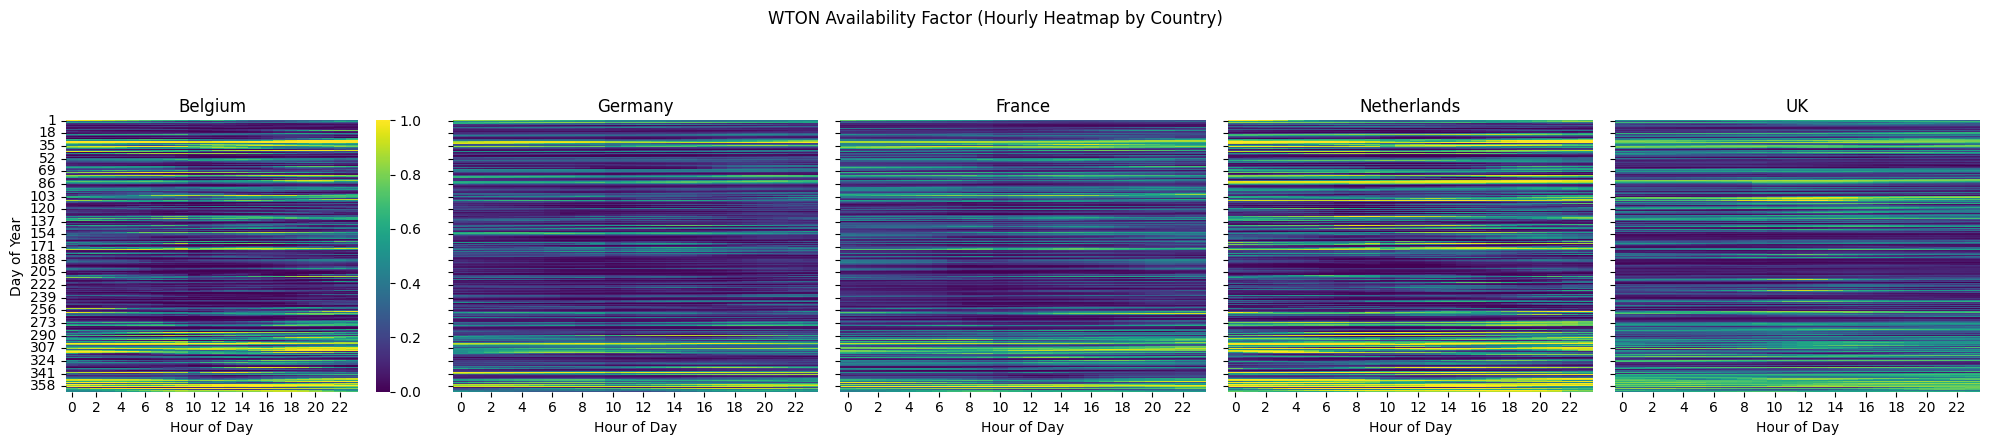

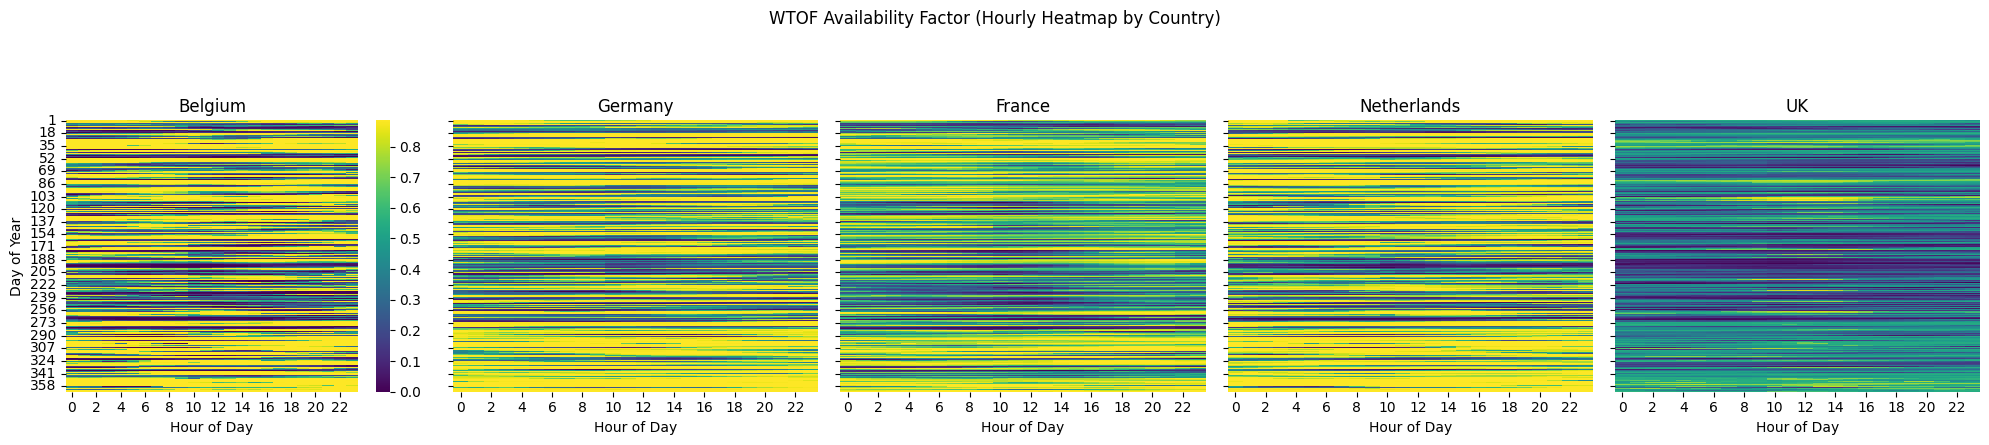

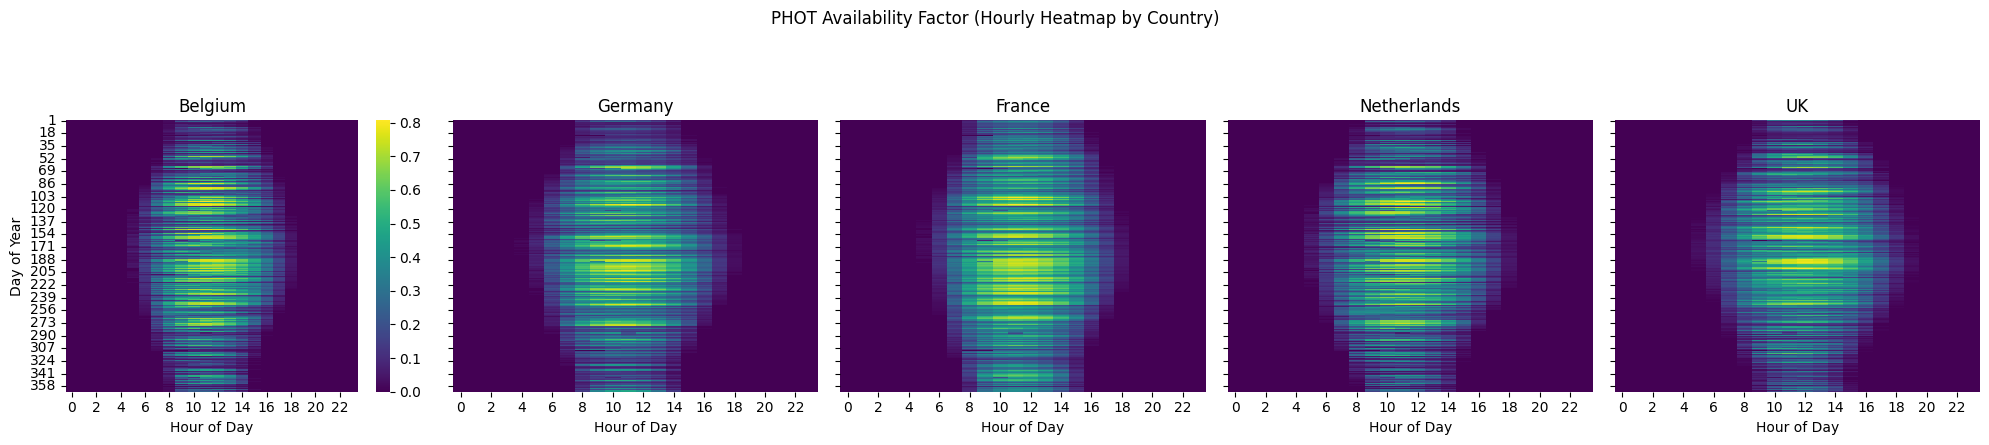

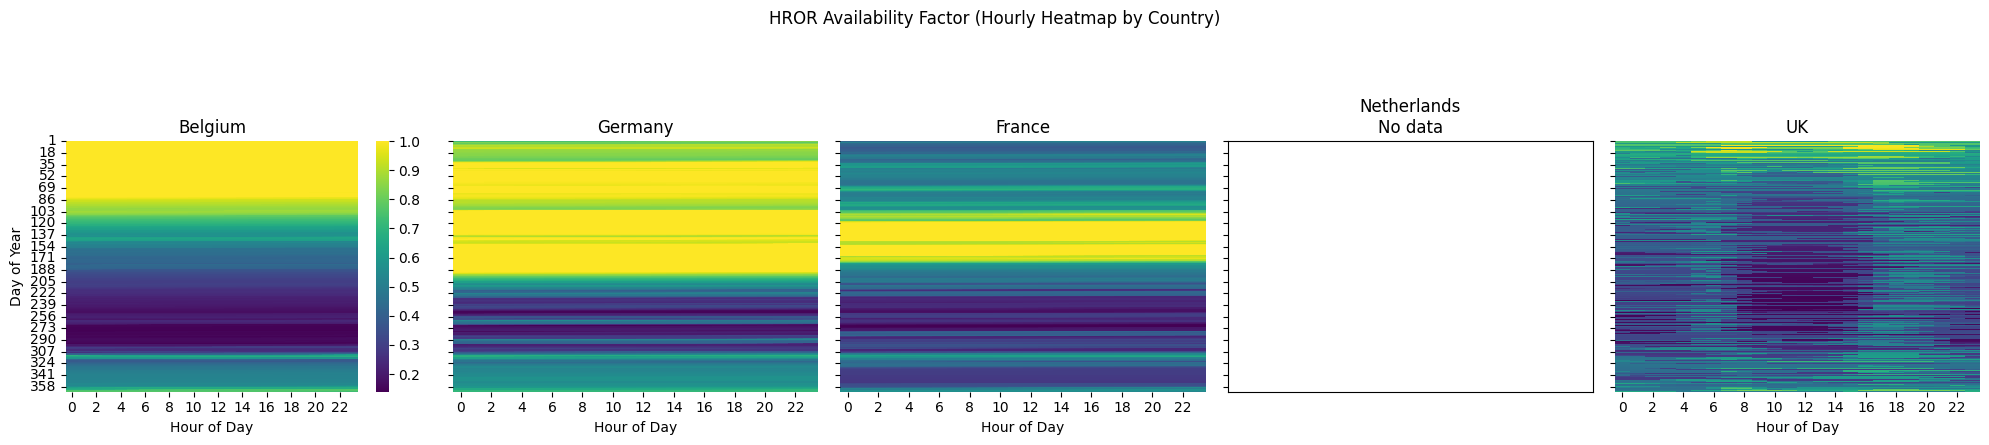

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Replace this with the actual paths to your CSV files for each country
country_paths = {
    'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/BE/1h/2030.csv',
    'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/DE/1h/2030.csv',
    'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/FR/1h/2030.csv',
    'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/NL/1h/2030.csv',
    'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/UK/1h/2030.csv',
}

# Load and concatenate all data
all_data = []
for country, path in country_paths.items():
    df = pd.read_csv(path, parse_dates=[0], index_col=0)
    df['country'] = country
    all_data.append(df)
data = pd.concat(all_data)

# Extract hour and day
data['hour'] = data.index.hour
data['day'] = data.index.dayofyear

# Resources to plot
resources = ['WTON', 'WTOF', 'PHOT', 'HROR']

# Create a heatmap for each resource
for resource in resources:
    fig, axes = plt.subplots(1, len(country_paths), figsize=(20, 4), sharey=True)
    fig.suptitle(f'{resource} Availability Factor (Hourly Heatmap by Country)', y=1.1)

    for i, (country, _) in enumerate(country_paths.items()):
        country_data = data[data['country'] == country]
        heatmap_data = country_data.pivot_table(values=resource, index='day', columns='hour')

        # Skip if heatmap_data is empty
        if heatmap_data.empty or heatmap_data.isna().all().all():
            axes[i].set_title(f'{country}\nNo data')
            axes[i].set_xticks([])
            axes[i].set_yticks([])
            continue

        sns.heatmap(heatmap_data, ax=axes[i], cmap='viridis', cbar=i == 0)
        axes[i].set_title(country)
        axes[i].set_xlabel('Hour of Day')
        axes[i].set_ylabel('Day of Year' if i == 0 else '')

    plt.tight_layout()
    plt.show()


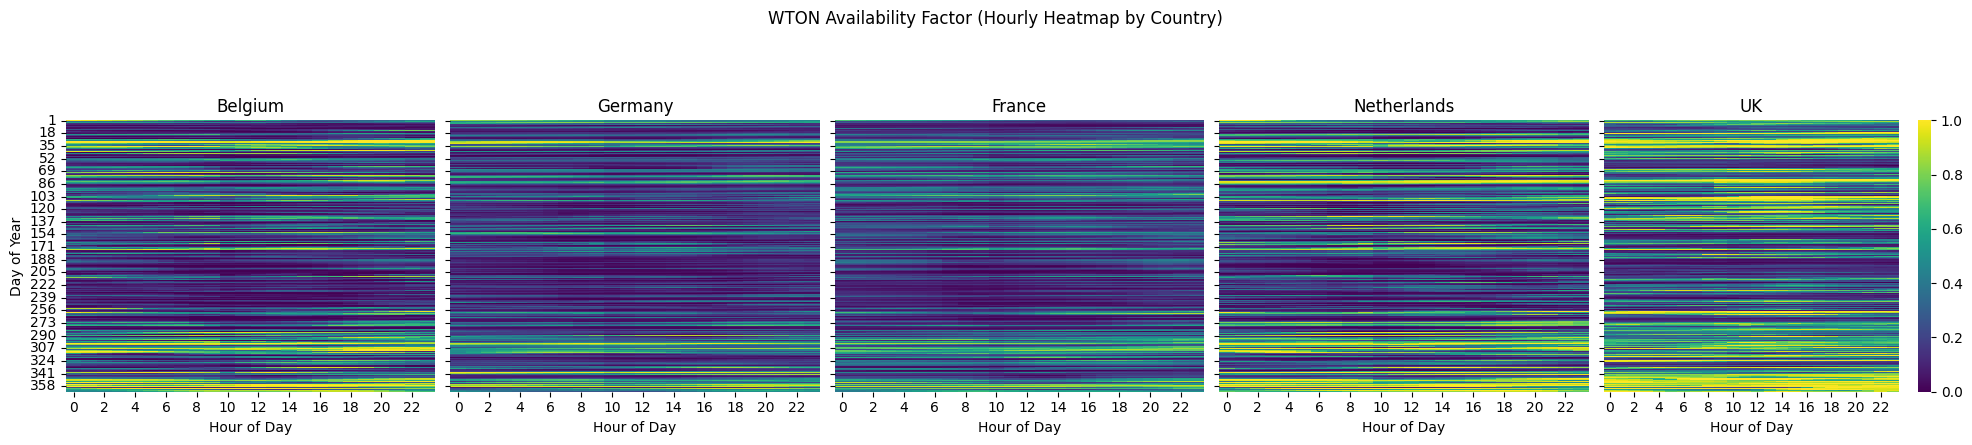

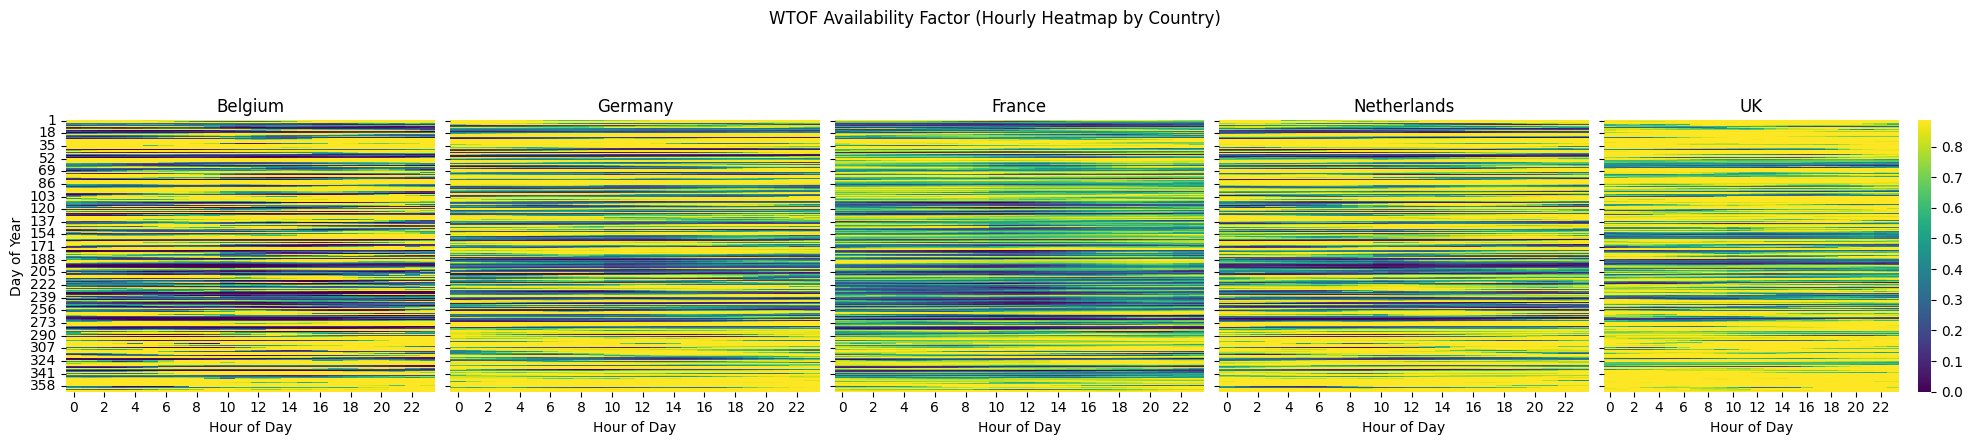

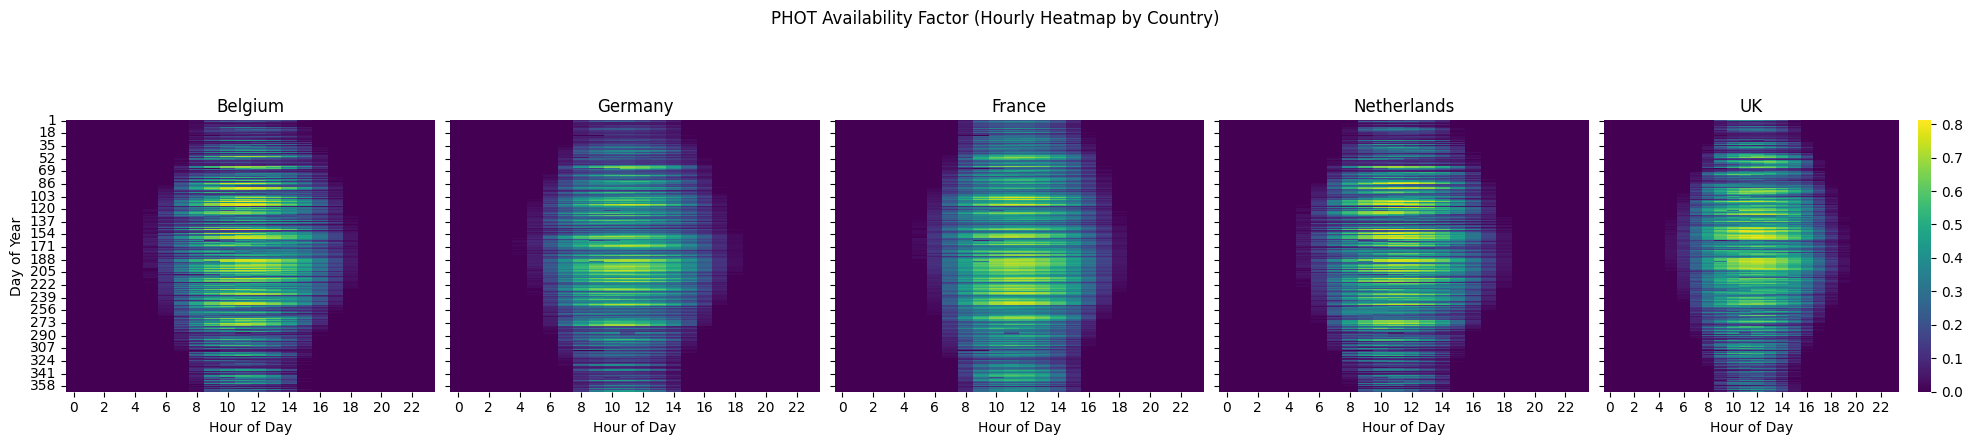

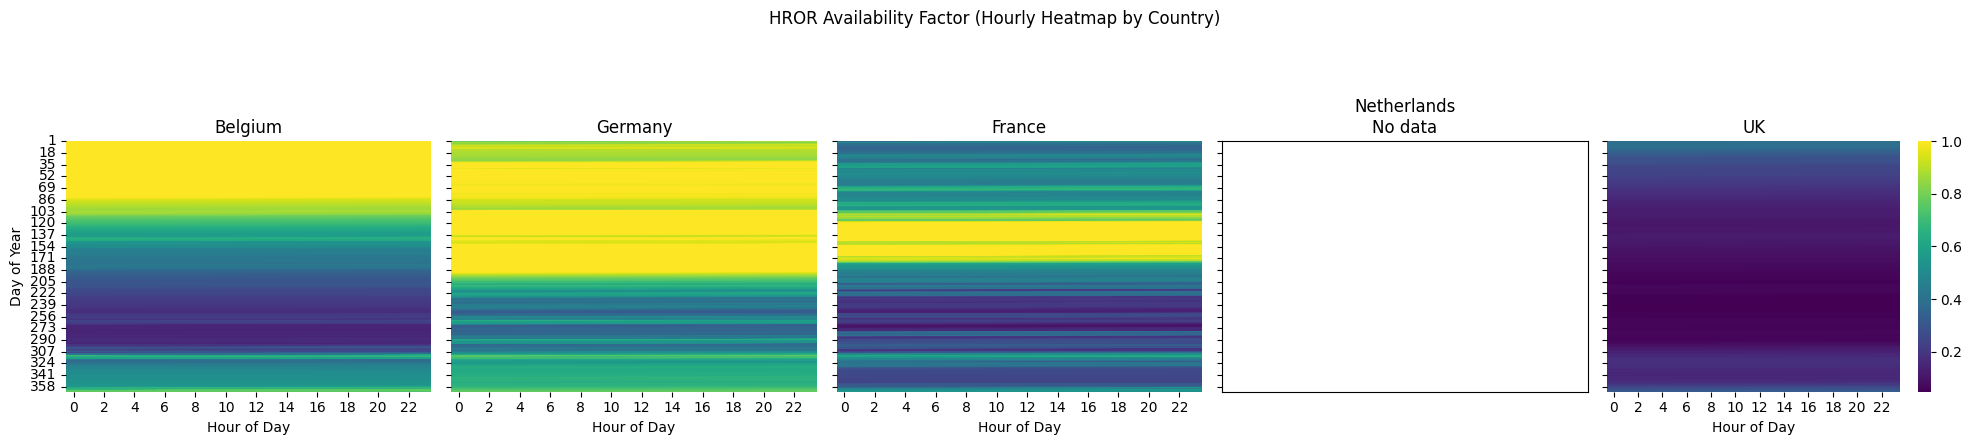

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Replace this with the actual paths to your CSV files for each country
country_paths = {
    'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/BE/1h/2030.csv',
    'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/DE/1h/2030.csv',
    'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/FR/1h/2030.csv',
    'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/NL/1h/2030.csv',
    'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/UK/1h/2030.csv',
}

# Load and concatenate all data
all_data = []
for country, path in country_paths.items():
    df = pd.read_csv(path, parse_dates=[0], index_col=0)
    df['country'] = country
    all_data.append(df)
data = pd.concat(all_data)

# Extract hour and day
data['hour'] = data.index.hour
data['day'] = data.index.dayofyear

# Resources to plot
resources = ['WTON', 'WTOF', 'PHOT', 'HROR']

# Create a heatmap for each resource
for resource in resources:
    # Calculate global min and max for the resource
    vmin = data[resource].min()
    vmax = data[resource].max()

    fig, axes = plt.subplots(1, len(country_paths), figsize=(20, 4), sharey=True)
    fig.suptitle(f'{resource} Availability Factor (Hourly Heatmap by Country)', y=1.1)

    for i, (country, _) in enumerate(country_paths.items()):
        country_data = data[data['country'] == country]
        heatmap_data = country_data.pivot_table(values=resource, index='day', columns='hour')

        # Skip if heatmap_data is empty
        if heatmap_data.empty or heatmap_data.isna().all().all():
            axes[i].set_title(f'{country}\nNo data')
            axes[i].set_xticks([])
            axes[i].set_yticks([])
            continue

        # Use the same vmin and vmax for all heatmaps
        sns.heatmap(heatmap_data, ax=axes[i], cmap='viridis', vmin=vmin, vmax=vmax, cbar=i == len(country_paths) - 1)
        axes[i].set_title(country)
        axes[i].set_xlabel('Hour of Day')
        axes[i].set_ylabel('Day of Year' if i == 0 else '')

    plt.tight_layout()
    plt.show()


/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample

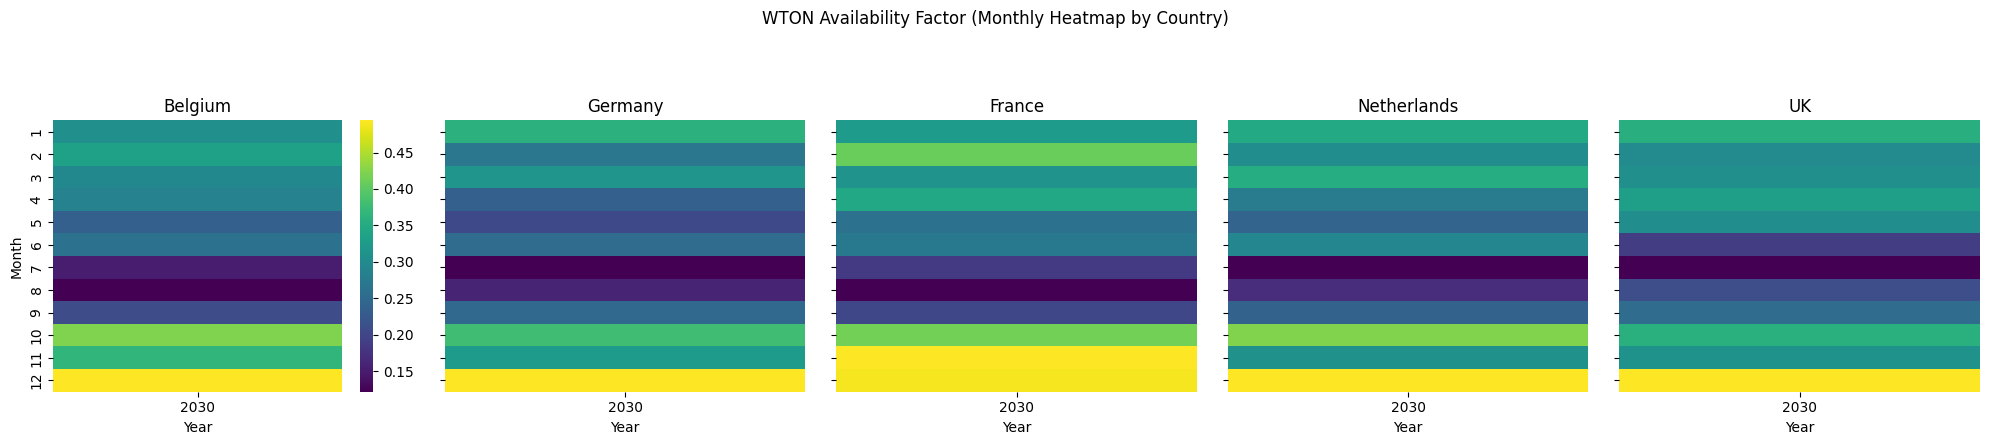

/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample

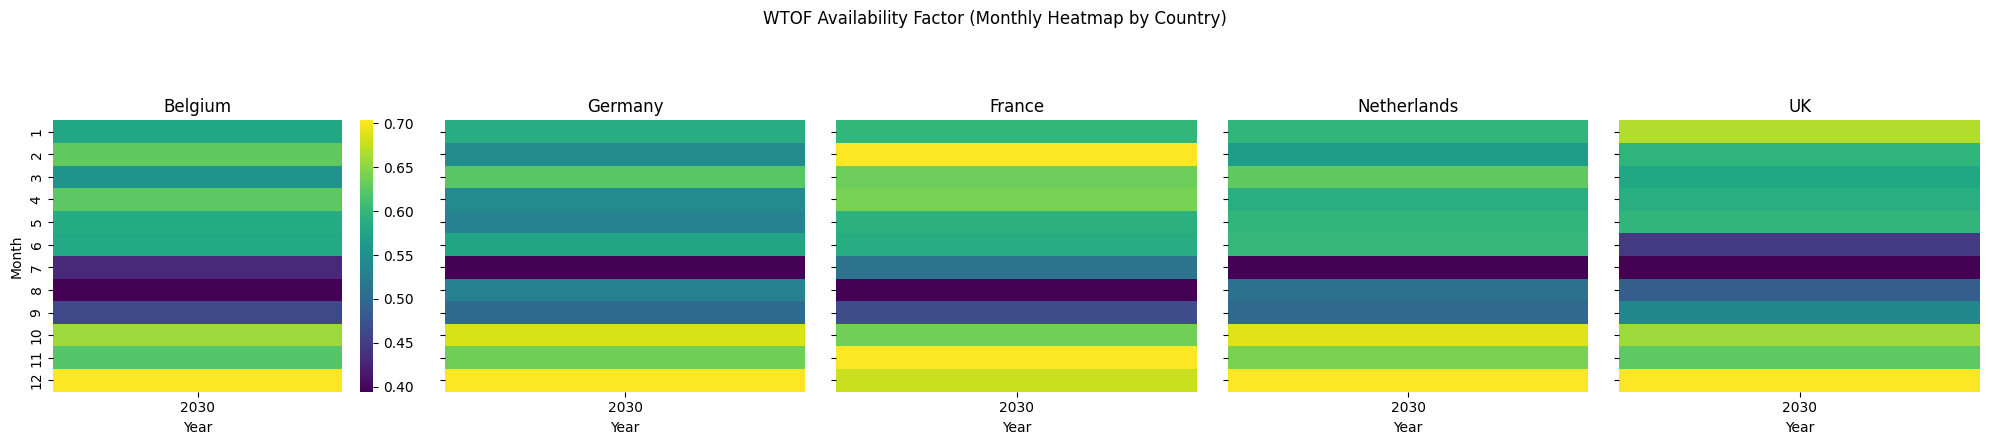

/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample

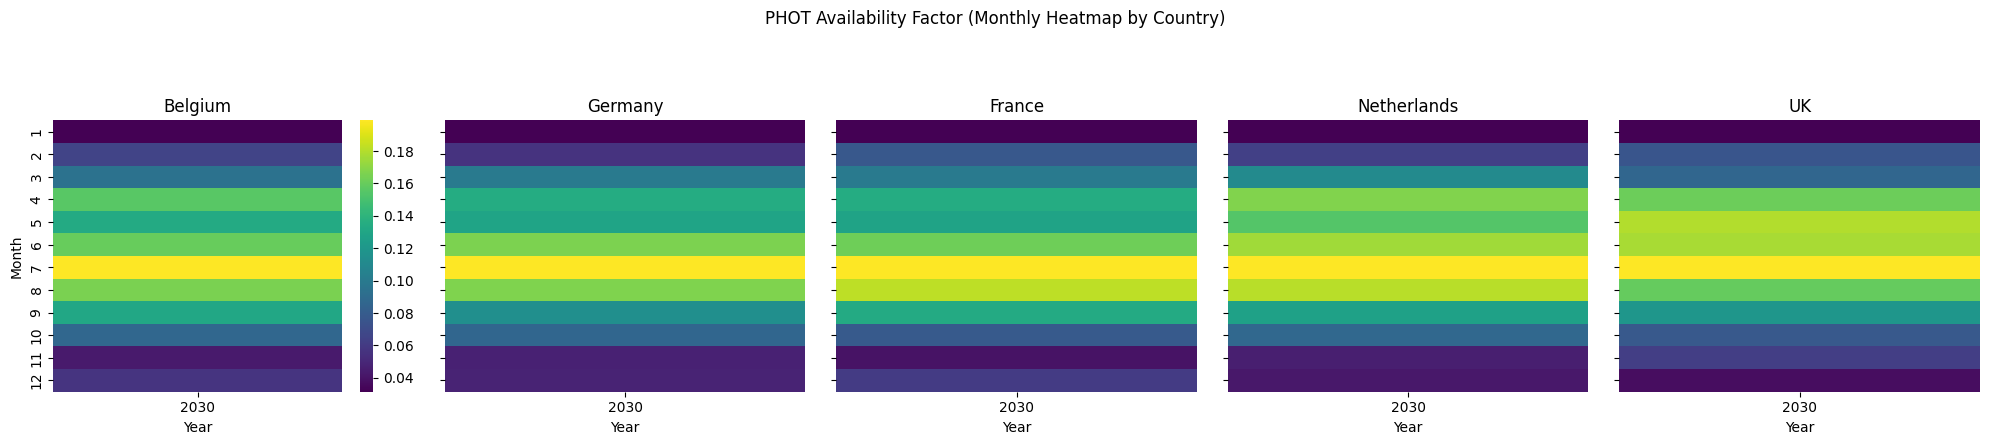

/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample

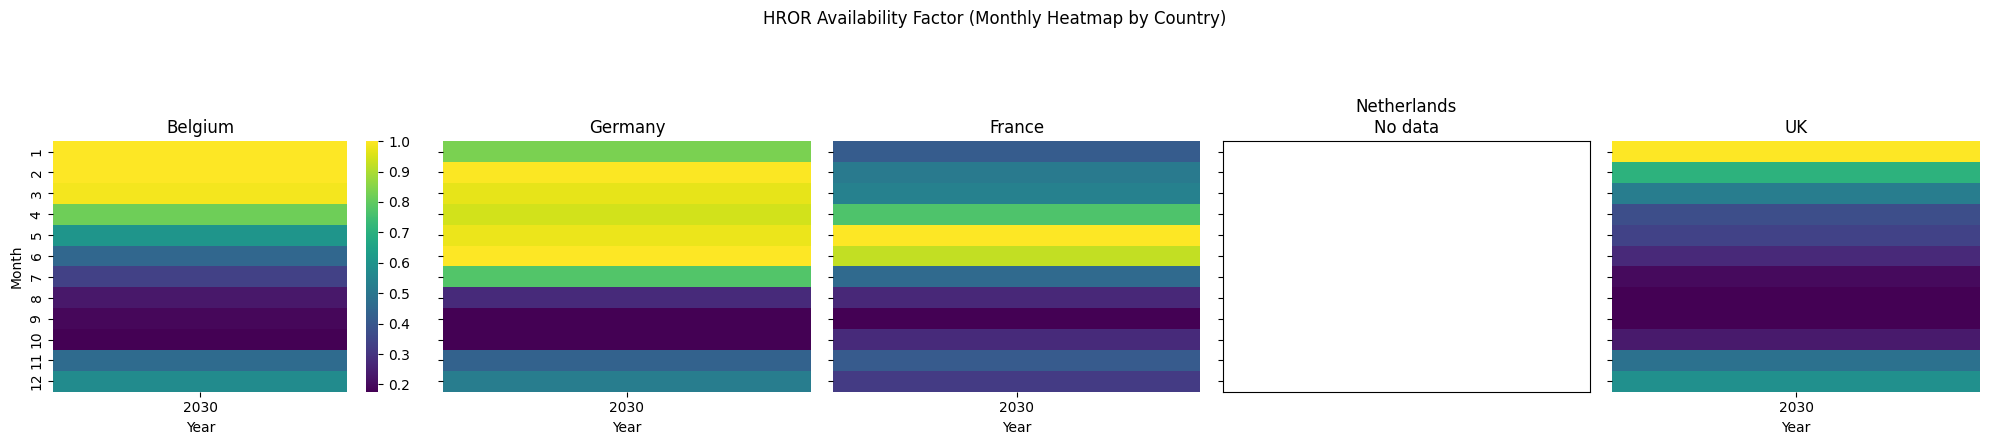

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Replace this with the actual paths to your CSV files for each country
country_paths = {
    'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/BE/1h/2030.csv',
    'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/DE/1h/2030.csv',
    'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/FR/1h/2030.csv',
    'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/NL/1h/2030.csv',
    'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/UK/1h/2030.csv',
}

# Load and concatenate all data
all_data = []
for country, path in country_paths.items():
    df = pd.read_csv(path, parse_dates=[0], index_col=0)
    df['country'] = country
    all_data.append(df)
data = pd.concat(all_data)

# Extract month and year
data['month'] = data.index.month
data['year'] = data.index.year

# Resources to plot
resources = ['WTON', 'WTOF', 'PHOT', 'HROR']

# Create a monthly heatmap for each resource
for resource in resources:
    fig, axes = plt.subplots(1, len(country_paths), figsize=(20, 4), sharey=True)
    fig.suptitle(f'{resource} Availability Factor (Monthly Heatmap by Country)', y=1.1)

    for i, (country, _) in enumerate(country_paths.items()):
        country_data = data[data['country'] == country]

        # Aggregate to monthly averages
        monthly_data = country_data.resample('M').mean(numeric_only=True)
        heatmap_data = monthly_data.pivot_table(values=resource, index=monthly_data.index.month, columns=monthly_data.index.year)

        # Skip if heatmap_data is empty
        if heatmap_data.empty or heatmap_data.isna().all().all():
            axes[i].set_title(f'{country}\nNo data')
            axes[i].set_xticks([])
            axes[i].set_yticks([])
            continue

        sns.heatmap(heatmap_data, ax=axes[i], cmap='viridis', cbar=i == 0)
        axes[i].set_title(country)
        axes[i].set_xlabel('Year')
        axes[i].set_ylabel('Month' if i == 0 else '')

    plt.tight_layout()
    plt.show()


In [34]:
import pandas as pd

# --------------------------------------------------
# 1. Input paths
# --------------------------------------------------
country_paths = {
    'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/BE/1h/2030.csv',
    'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/DE/1h/2030.csv',
    'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/FR/1h/2030.csv',
    'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/NL/1h/2030.csv',
    'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/UK/1h/2030.csv',
}

# --------------------------------------------------
# 2. Resource name mapping
# --------------------------------------------------
resource_map = {
    'PHOT': 'Solar',
    'WTON': 'Wind Onshore',
    'WTOF': 'Wind Offshore',
    'HROR': 'Hydro RoR'
}

# --------------------------------------------------
# 3. Helper function to compute averages
# --------------------------------------------------
def compute_availability_stats(df):
    """
    df: DataFrame with datetime index and resource columns
    returns: DataFrame with annual and quarterly averages
    """
    results = []

    # Ensure datetime index
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # Add quarter information
    df['Quarter'] = df.index.quarter

    for col, resource_name in resource_map.items():
        if col not in df.columns:
            continue

        annual_avg = df[col].mean()

        quarterly_avg = (
            df.groupby('Quarter')[col]
            .mean()
            .reindex([1, 2, 3, 4])
        )

        results.append({
            'Resource': resource_name,
            'Annual Avg (%)': annual_avg * 100,
            'Q1 Avg (%)': quarterly_avg.loc[1] * 100,
            'Q2 Avg (%)': quarterly_avg.loc[2] * 100,
            'Q3 Avg (%)': quarterly_avg.loc[3] * 100,
            'Q4 Avg (%)': quarterly_avg.loc[4] * 100,
        })

    return pd.DataFrame(results)


# --------------------------------------------------
# 4. Load data and build final table
# --------------------------------------------------
all_countries_results = []

for country, path in country_paths.items():
    # Load CSV
    df = pd.read_csv(path, index_col=0)

    # Convert index to datetime (important)
    df.index = pd.to_datetime(df.index, utc=True)

    # Compute stats
    stats_df = compute_availability_stats(df)

    # Add country column
    stats_df.insert(0, 'Country', country)

    all_countries_results.append(stats_df)

# --------------------------------------------------
# 5. Final combined table
# --------------------------------------------------
final_table = pd.concat(all_countries_results, ignore_index=True)

# Optional: round for report
final_table = final_table.round(2)

# Display
print(final_table)


        Country       Resource  Annual Avg (%)  Q1 Avg (%)  Q2 Avg (%)  \
0       Belgium          Solar           11.04        6.37       14.94   
1       Belgium   Wind Onshore           28.98       31.15       26.06   
2       Belgium  Wind Offshore           56.78       58.52       59.70   
3       Belgium      Hydro RoR           56.57       99.49       62.42   
4       Germany          Solar           10.85        6.30       14.58   
5       Germany   Wind Onshore           24.19       27.54       19.53   
6       Germany  Wind Offshore           61.54       63.52       58.52   
7       Germany      Hydro RoR           77.18       95.21       98.15   
8        France          Solar           13.29        9.62       16.02   
9        France   Wind Onshore           25.34       27.30       23.59   
10       France  Wind Offshore           56.22       60.74       57.32   
11       France      Hydro RoR           49.97       48.14       88.58   
12  Netherlands          Solar        

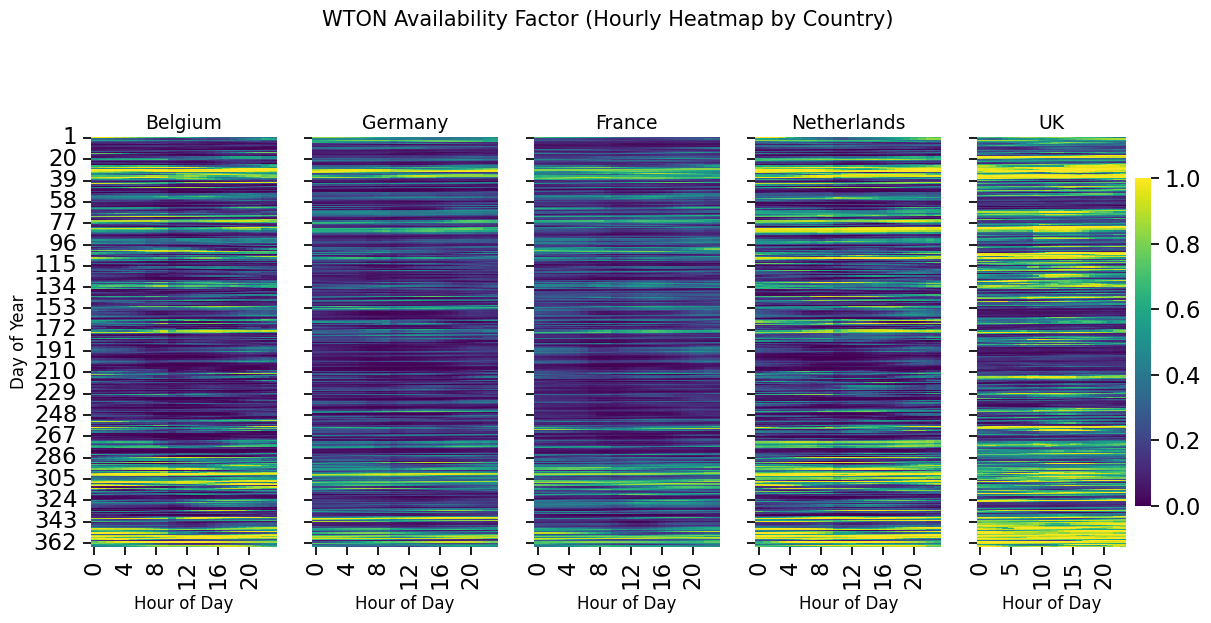

Saved WTON heatmap to: /home/ray/Downloads/Downloads/heatmaps_individual/WTON_availability_heatmap.pdf


<Figure size 640x480 with 0 Axes>

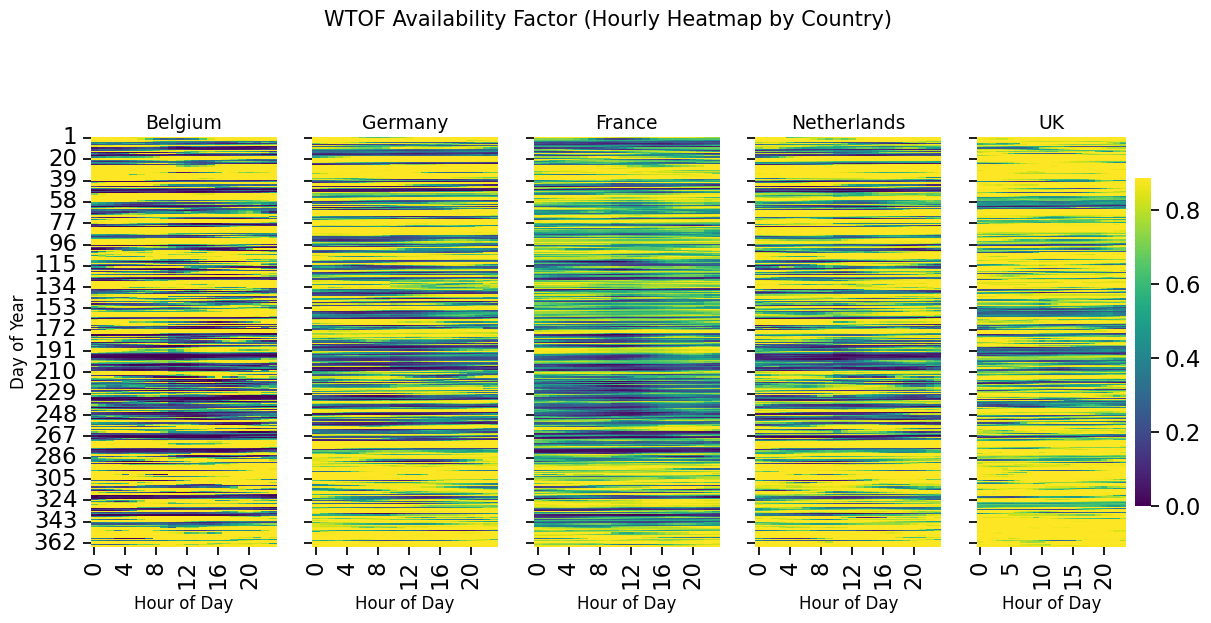

Saved WTOF heatmap to: /home/ray/Downloads/Downloads/heatmaps_individual/WTOF_availability_heatmap.pdf


<Figure size 640x480 with 0 Axes>

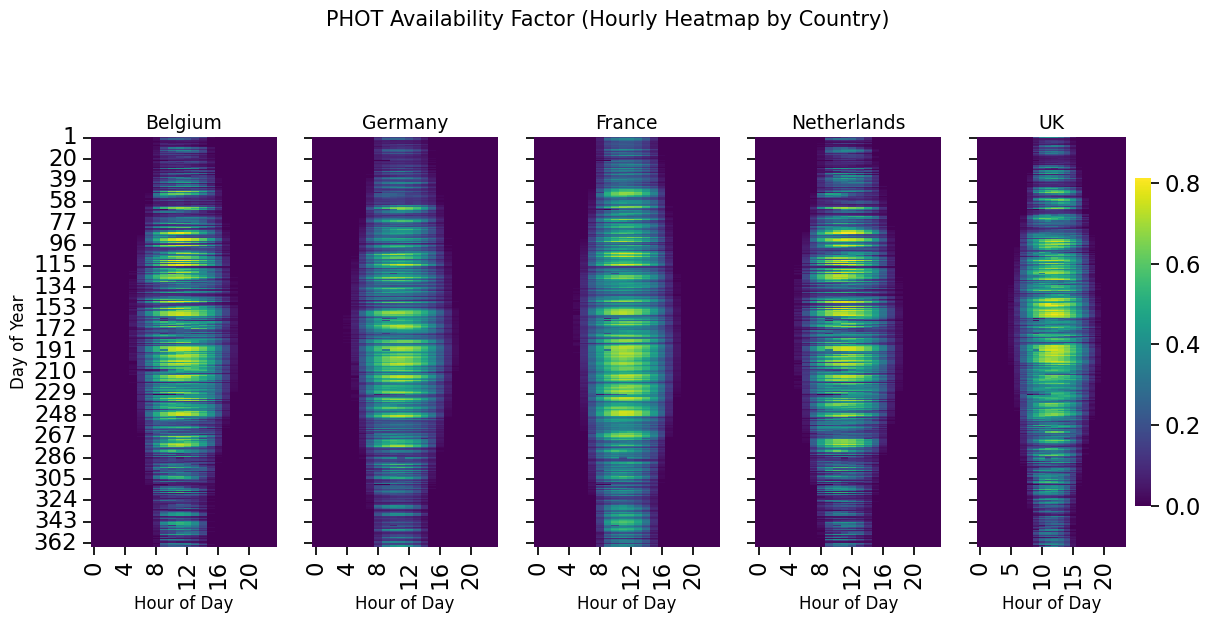

Saved PHOT heatmap to: /home/ray/Downloads/Downloads/heatmaps_individual/PHOT_availability_heatmap.pdf


<Figure size 640x480 with 0 Axes>

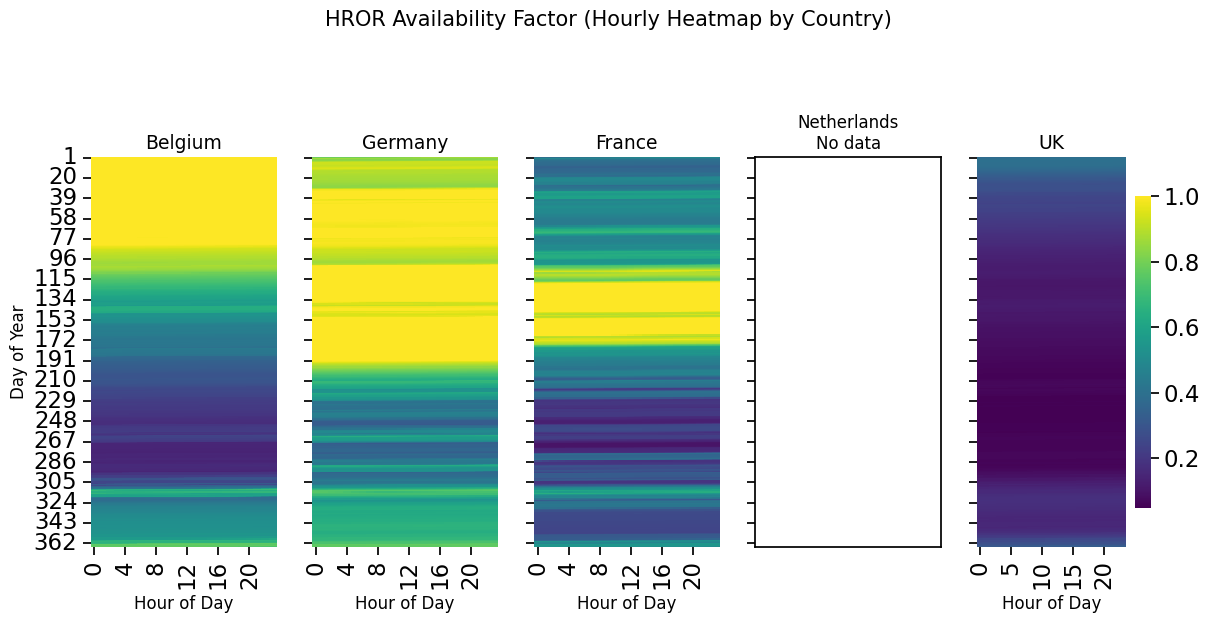

Saved HROR heatmap to: /home/ray/Downloads/Downloads/heatmaps_individual/HROR_availability_heatmap.pdf


<Figure size 640x480 with 0 Axes>

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Replace this with the actual paths to your CSV files for each country
country_paths = {
    'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/BE/1h/2030.csv',
    'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/DE/1h/2030.csv',
    'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/FR/1h/2030.csv',
    'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/NL/1h/2030.csv',
    'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/UK/1h/2030.csv',
}

# Load and concatenate all data
all_data = []
for country, path in country_paths.items():
    df = pd.read_csv(path, parse_dates=[0], index_col=0)
    df['country'] = country
    all_data.append(df)

data = pd.concat(all_data)

# Extract hour and day
data['hour'] = data.index.hour
data['day'] = data.index.dayofyear

# Resources to plot
resources = ['WTON', 'WTOF', 'PHOT', 'HROR']

# Output folder for individual plots
output_folder = '/home/ray/Downloads/Downloads/heatmaps_individual'
os.makedirs(output_folder, exist_ok=True)

# Scaling factor for font
font_scale = 1.5
sns.set_context("notebook", font_scale=font_scale)

# Create a separate plot for each resource
for resource in resources:
    # Calculate global min and max for the resource
    vmin = data[resource].min()
    vmax = data[resource].max()

    # Adjust figure size: taller and narrower
    fig, axes = plt.subplots(
        1, len(country_paths),
        figsize=(len(country_paths) * 2.5, 6),  # width per country = 2.5, height = 6
        sharey=True
    )
    fig.suptitle(
        f'{resource} Availability Factor (Hourly Heatmap by Country)',
        y=1.05,
        fontsize=font_scale*10  # scale title font
    )

    for i, (country, _) in enumerate(country_paths.items()):
        country_data = data[data['country'] == country]
        heatmap_data = country_data.pivot_table(
            values=resource,
            index='day',
            columns='hour'
        )

        if heatmap_data.empty or heatmap_data.isna().all().all():
            axes[i].set_title(f'{country}\nNo data', fontsize=font_scale*8)
            axes[i].set_xticks([])
            axes[i].set_yticks([])
            continue

        sns.heatmap(
            heatmap_data,
            ax=axes[i],
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
            cbar=i == len(country_paths) - 1,
            cbar_kws={'shrink': 0.8}  # shrink colorbar a bit
        )

        axes[i].set_title(country, fontsize=font_scale*9)
        axes[i].set_xlabel('Hour of Day', fontsize=font_scale*8)
        axes[i].set_ylabel('Day of Year' if i == 0 else '', fontsize=font_scale*8)

    plt.tight_layout()
    plt.show()

    # Save each resource heatmap separately
    file_path = os.path.join(output_folder, f'{resource}_availability_heatmap.pdf')
    plt.savefig(file_path, format='pdf', bbox_inches='tight')
    plt.close(fig)

    print(f"Saved {resource} heatmap to: {file_path}")


Saved: /home/ray/Downloads/Downloads/WTON_heatmap.pdf


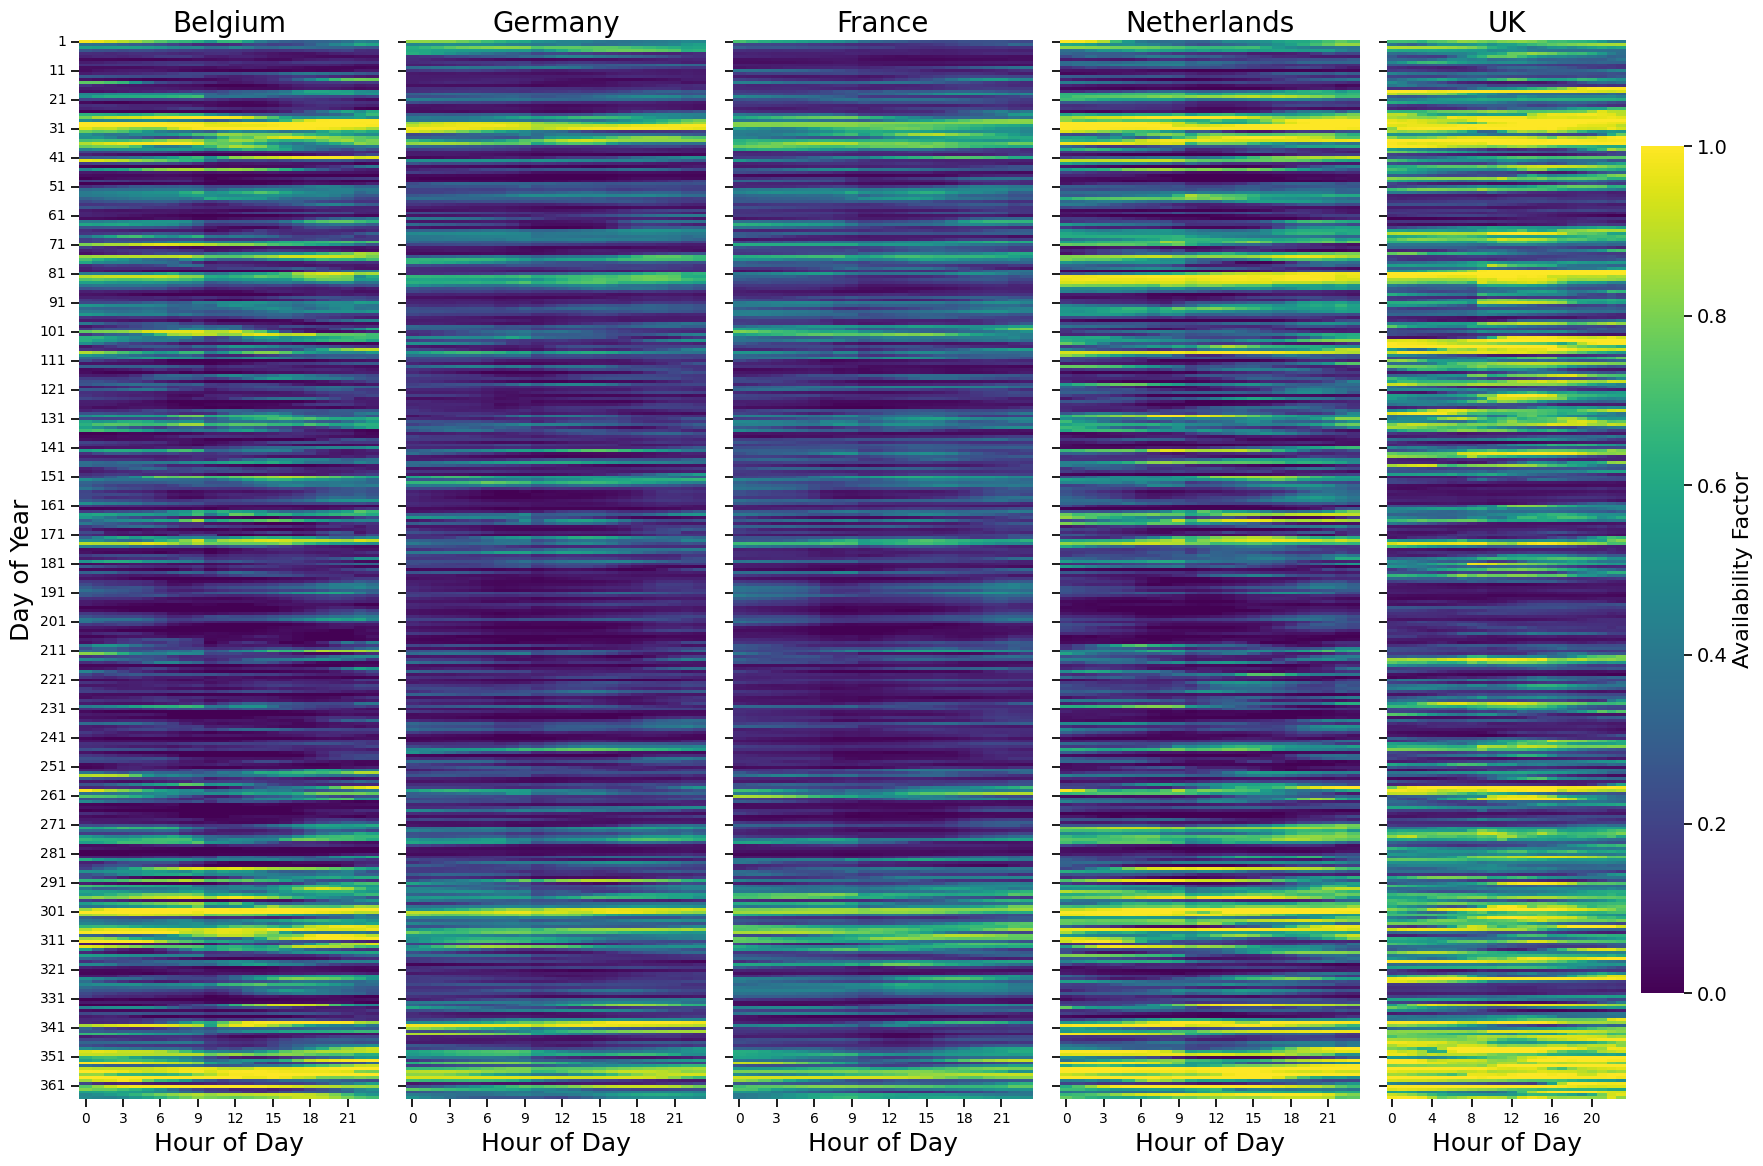

Saved: /home/ray/Downloads/Downloads/WTOF_heatmap.pdf


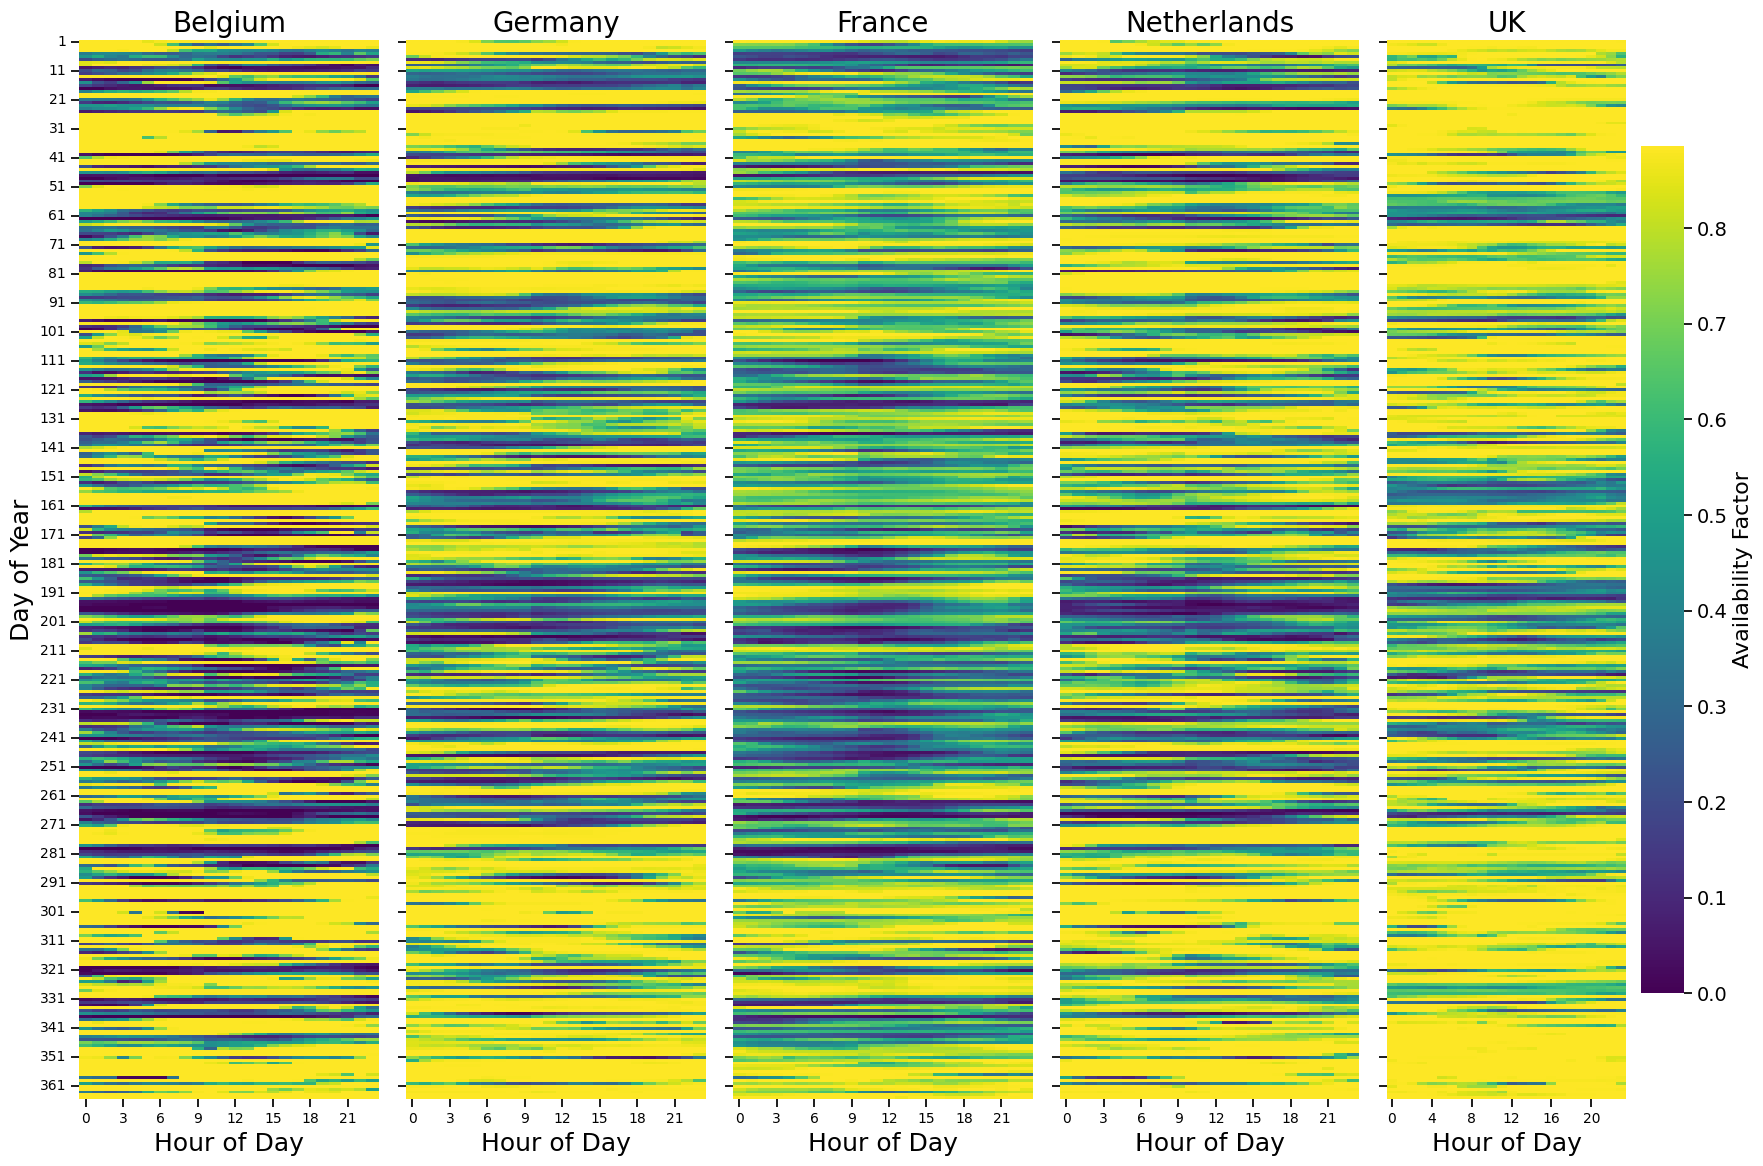

Saved: /home/ray/Downloads/Downloads/PHOT_heatmap.pdf


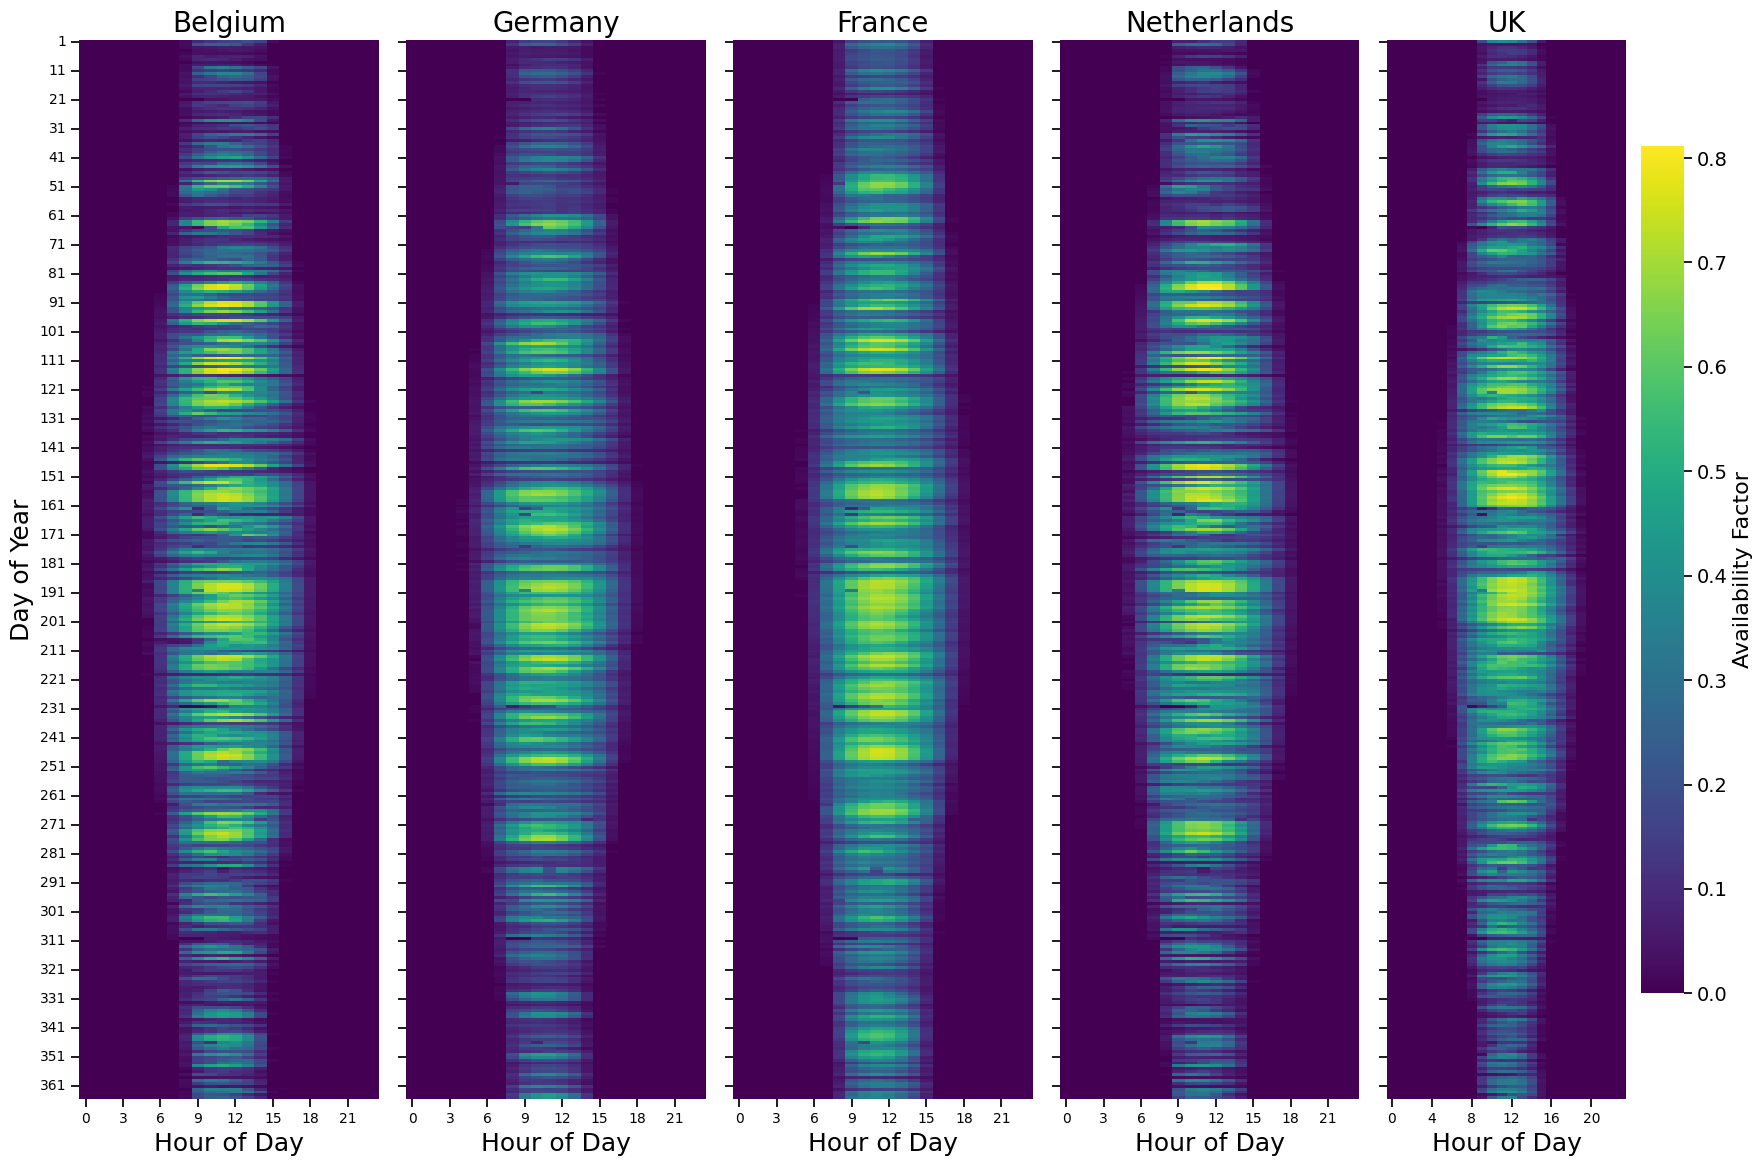

Saved: /home/ray/Downloads/Downloads/HROR_heatmap.pdf


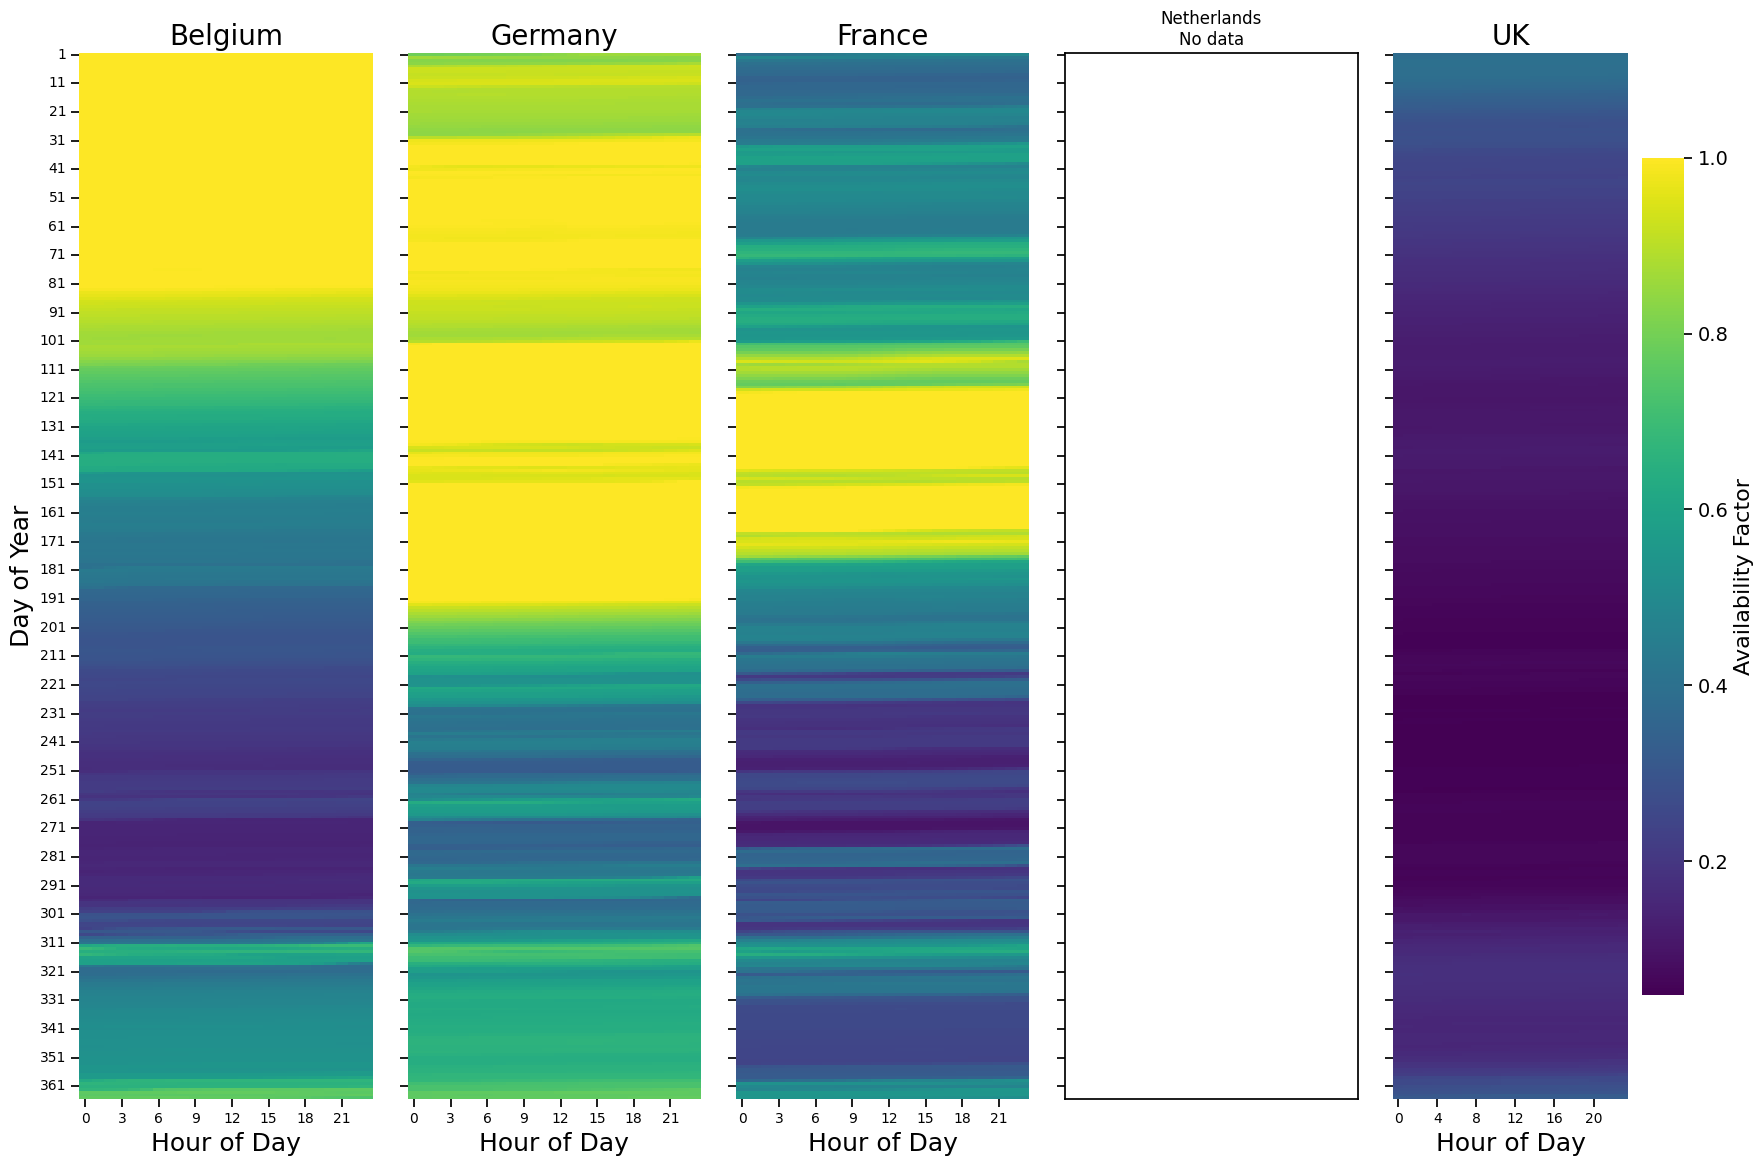

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Replace this with the actual paths to your CSV files for each country
country_paths = {
    'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/BE/1h/2030.csv',
    'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/DE/1h/2030.csv',
    'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/FR/1h/2030.csv',
    'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/NL/1h/2030.csv',
    'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/UK/1h/2030.csv',
}

# Load and concatenate all data
all_data = []
for country, path in country_paths.items():
    df = pd.read_csv(path, parse_dates=[0], index_col=0)
    df['country'] = country
    all_data.append(df)

data = pd.concat(all_data)

# Extract hour and day
data['hour'] = data.index.hour
data['day'] = data.index.dayofyear

# Resources to plot
resources = ['WTON', 'WTOF', 'PHOT', 'HROR']

# Output folder
output_folder = '/home/ray/Downloads/Downloads/'

# Loop through each resource
for resource in resources:
    # Calculate global min and max for consistent color scaling
    vmin = data[resource].min()
    vmax = data[resource].max()

    # Create figure with taller and narrower heatmaps
    fig, axes = plt.subplots(
        1, len(country_paths),
        figsize=(18, 12),  # narrower and taller
        sharey=True
    )
#    fig.suptitle(
#        f'{resource} Availability Factor (Hourly Heatmap by Country)',
#        y=1.05,
#        fontsize=16
#    )

    for i, (country, _) in enumerate(country_paths.items()):
        country_data = data[data['country'] == country]
        heatmap_data = country_data.pivot_table(
            values=resource,
            index='day',
            columns='hour'
        )

        if heatmap_data.empty or heatmap_data.isna().all().all():
            axes[i].set_title(f'{country}\nNo data', fontsize=12)
            axes[i].set_xticks([])
            axes[i].set_yticks([])
            continue

        # Draw heatmap with increased legend size
        cbar_kws = {"label": "Availability Factor", "shrink": 0.8, "orientation": "vertical"}
        sns.heatmap(
            heatmap_data,
            ax=axes[i],
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
            cbar=i == len(country_paths) - 1,
            cbar_kws=cbar_kws
        )

        # Increase colorbar label font size
        if i == len(country_paths) - 1:
            axes[i].collections[0].colorbar.ax.tick_params(labelsize=14)  # scale by ~1.5
            axes[i].collections[0].colorbar.ax.yaxis.label.set_size(16)

        axes[i].set_title(country, fontsize=20)
        axes[i].set_xlabel('Hour of Day', fontsize=18)
        axes[i].set_ylabel('Day of Year' if i == 0 else '', fontsize=18)


        # Reduce the size of the numbers on the X and Y axes
        axes[i].tick_params(axis='x', labelsize=10)  # Adjust the labelsize for X-axis
        axes[i].tick_params(axis='y', labelsize=10)  # Adjust the labelsize for Y-axis

    plt.tight_layout()

    # Save each figure as PDF FIRST
    pdf_file = f"{output_folder}{resource}_heatmap.pdf"
    plt.savefig(pdf_file, bbox_inches='tight', dpi=300)  # Added dpi for higher quality if needed
    print(f"Saved: {pdf_file}")

    # THEN display it
    plt.show()

    # Finally, close the figure
    plt.close(fig)

[INFO] Saved: /home/ray/Downloads/ReservoirLevelPlots/Belgium_HPHS_2030_2040_2050.pdf


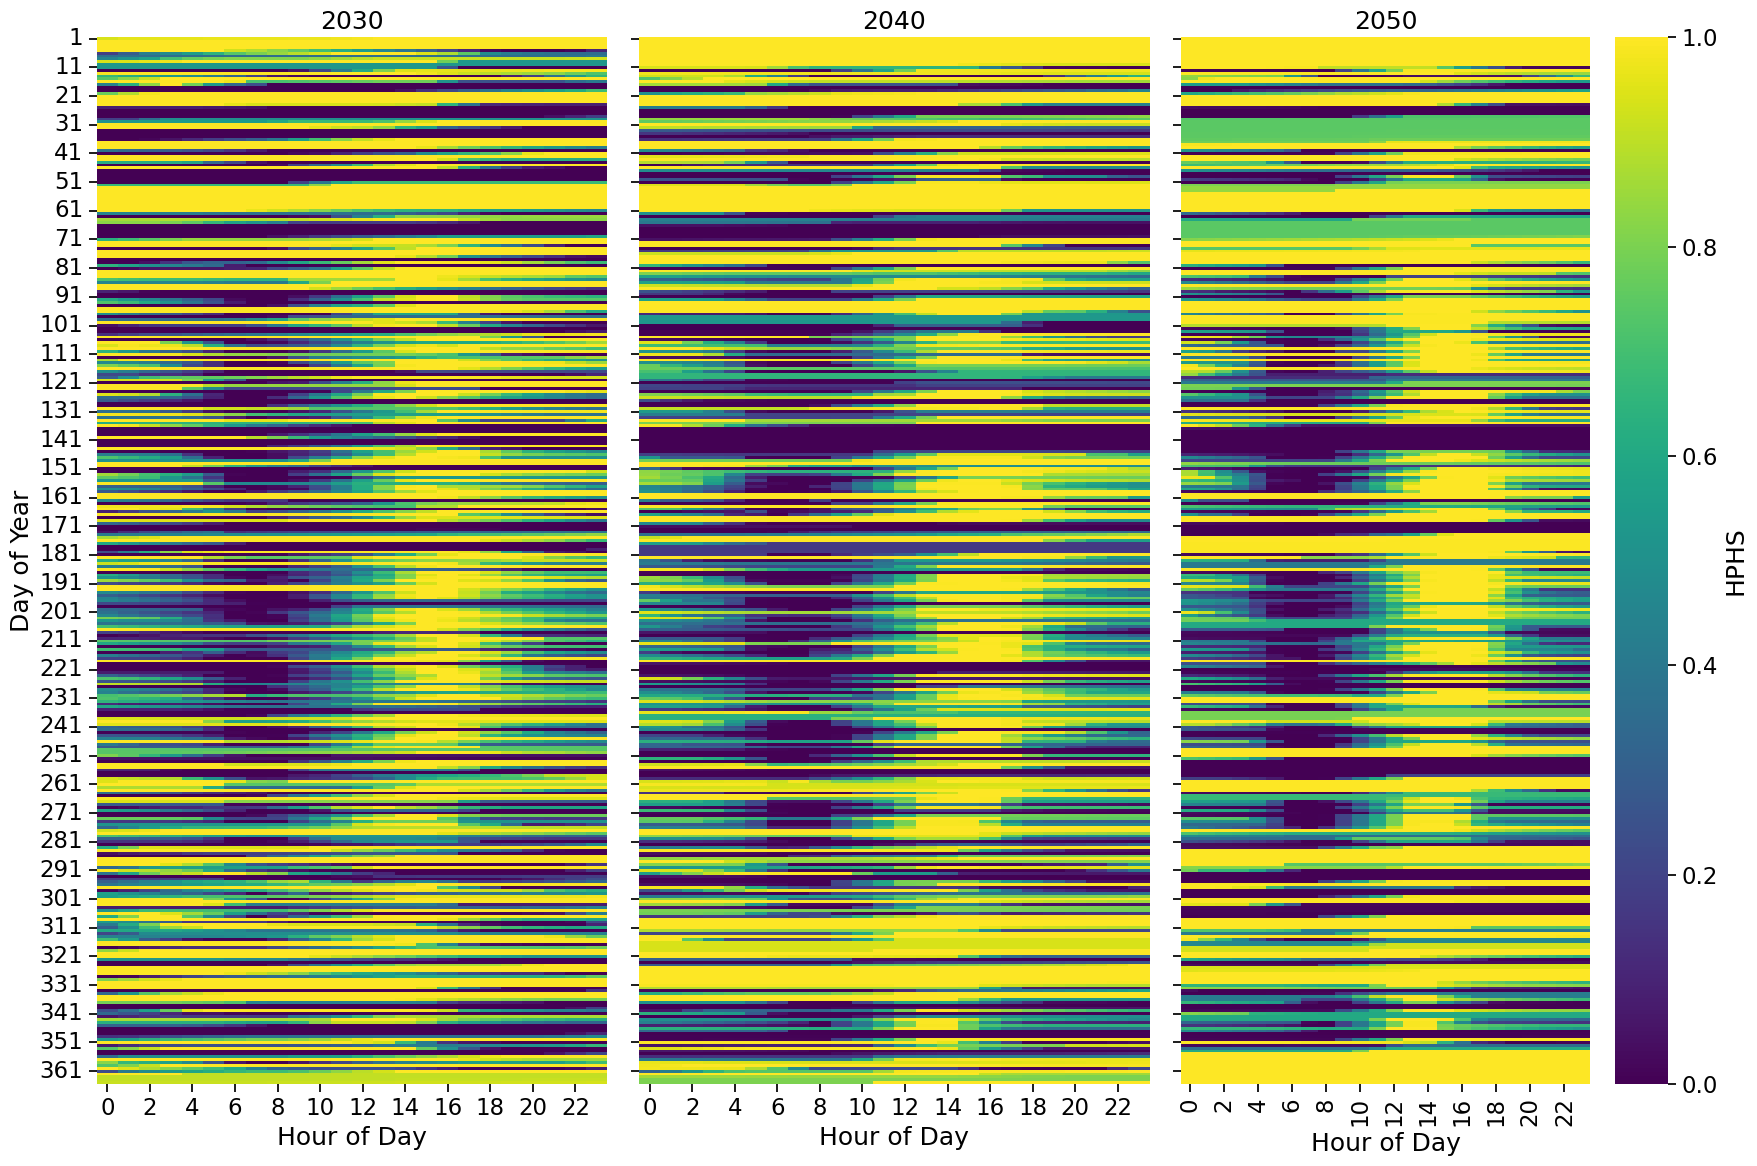

[INFO] Saved: /home/ray/Downloads/ReservoirLevelPlots/Belgium_HDAM_2030_2040_2050.pdf


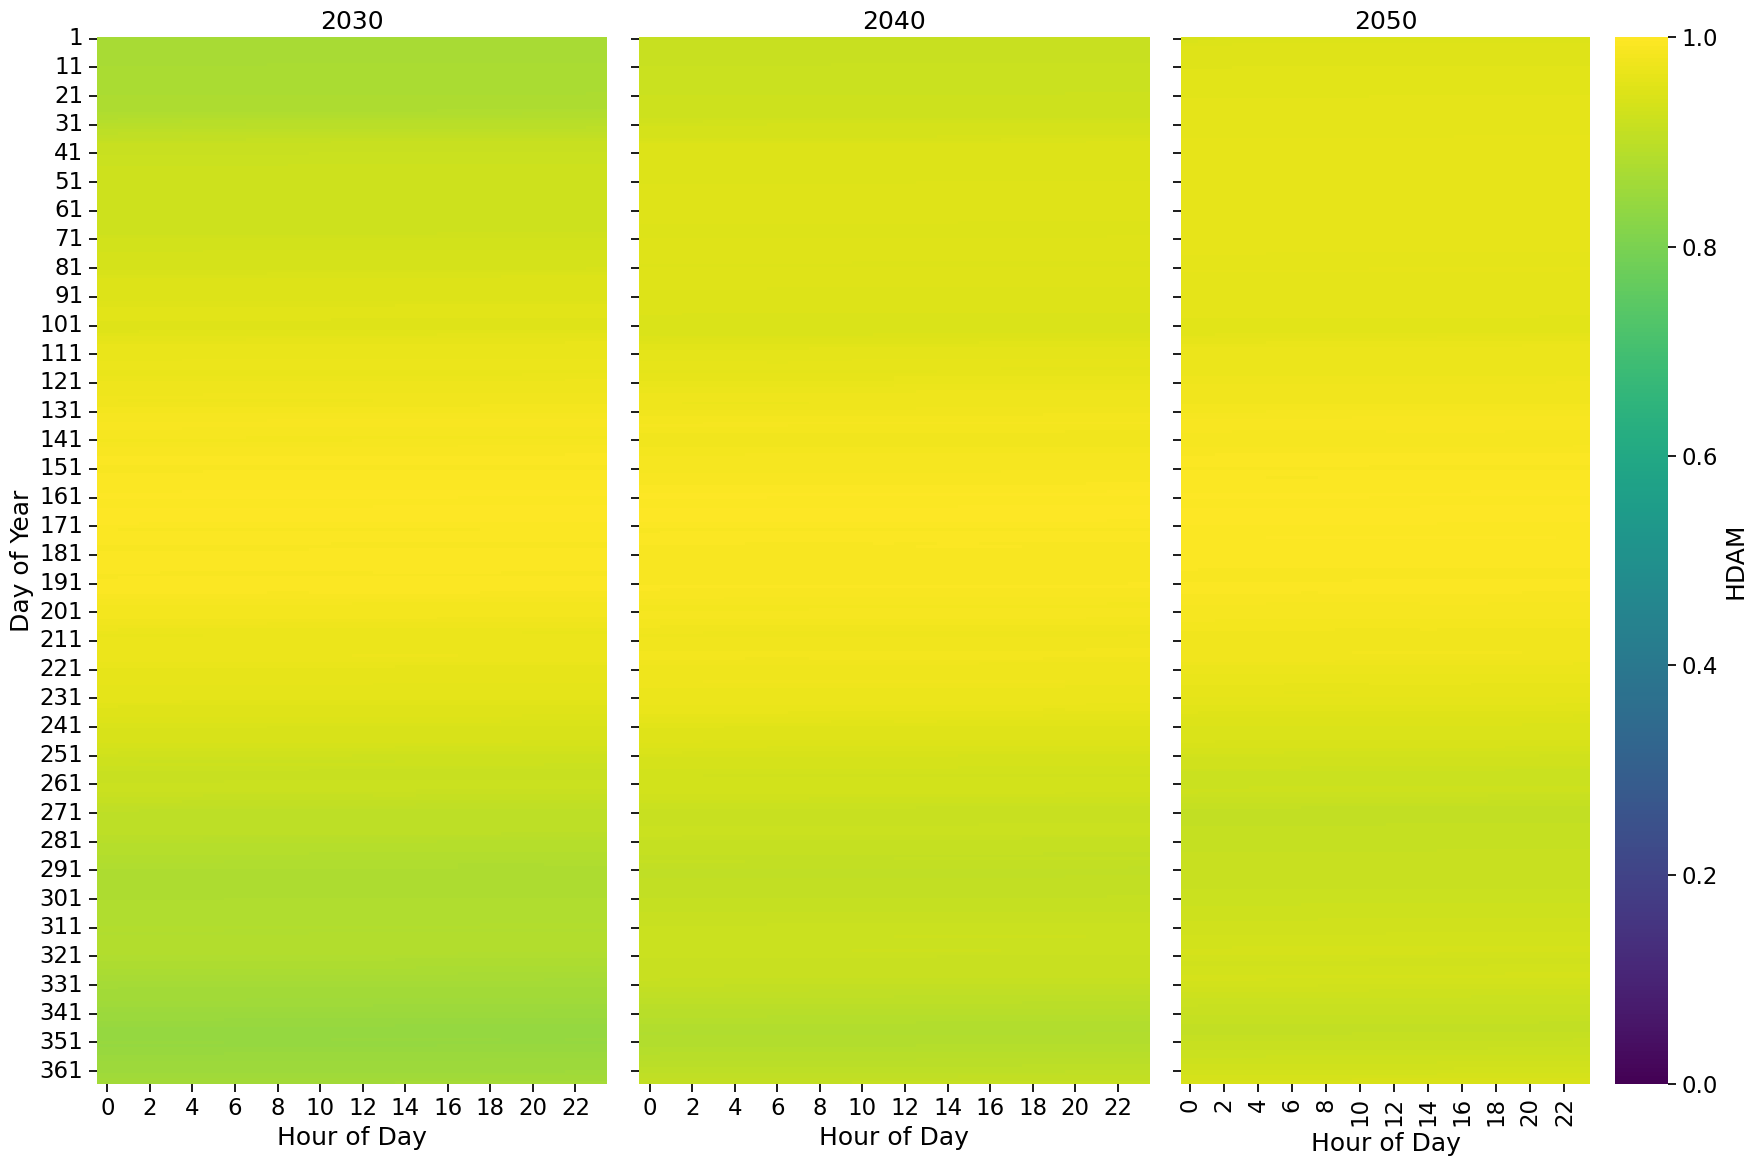

[INFO] Saved: /home/ray/Downloads/ReservoirLevelPlots/Germany_HPHS_2030_2040_2050.pdf


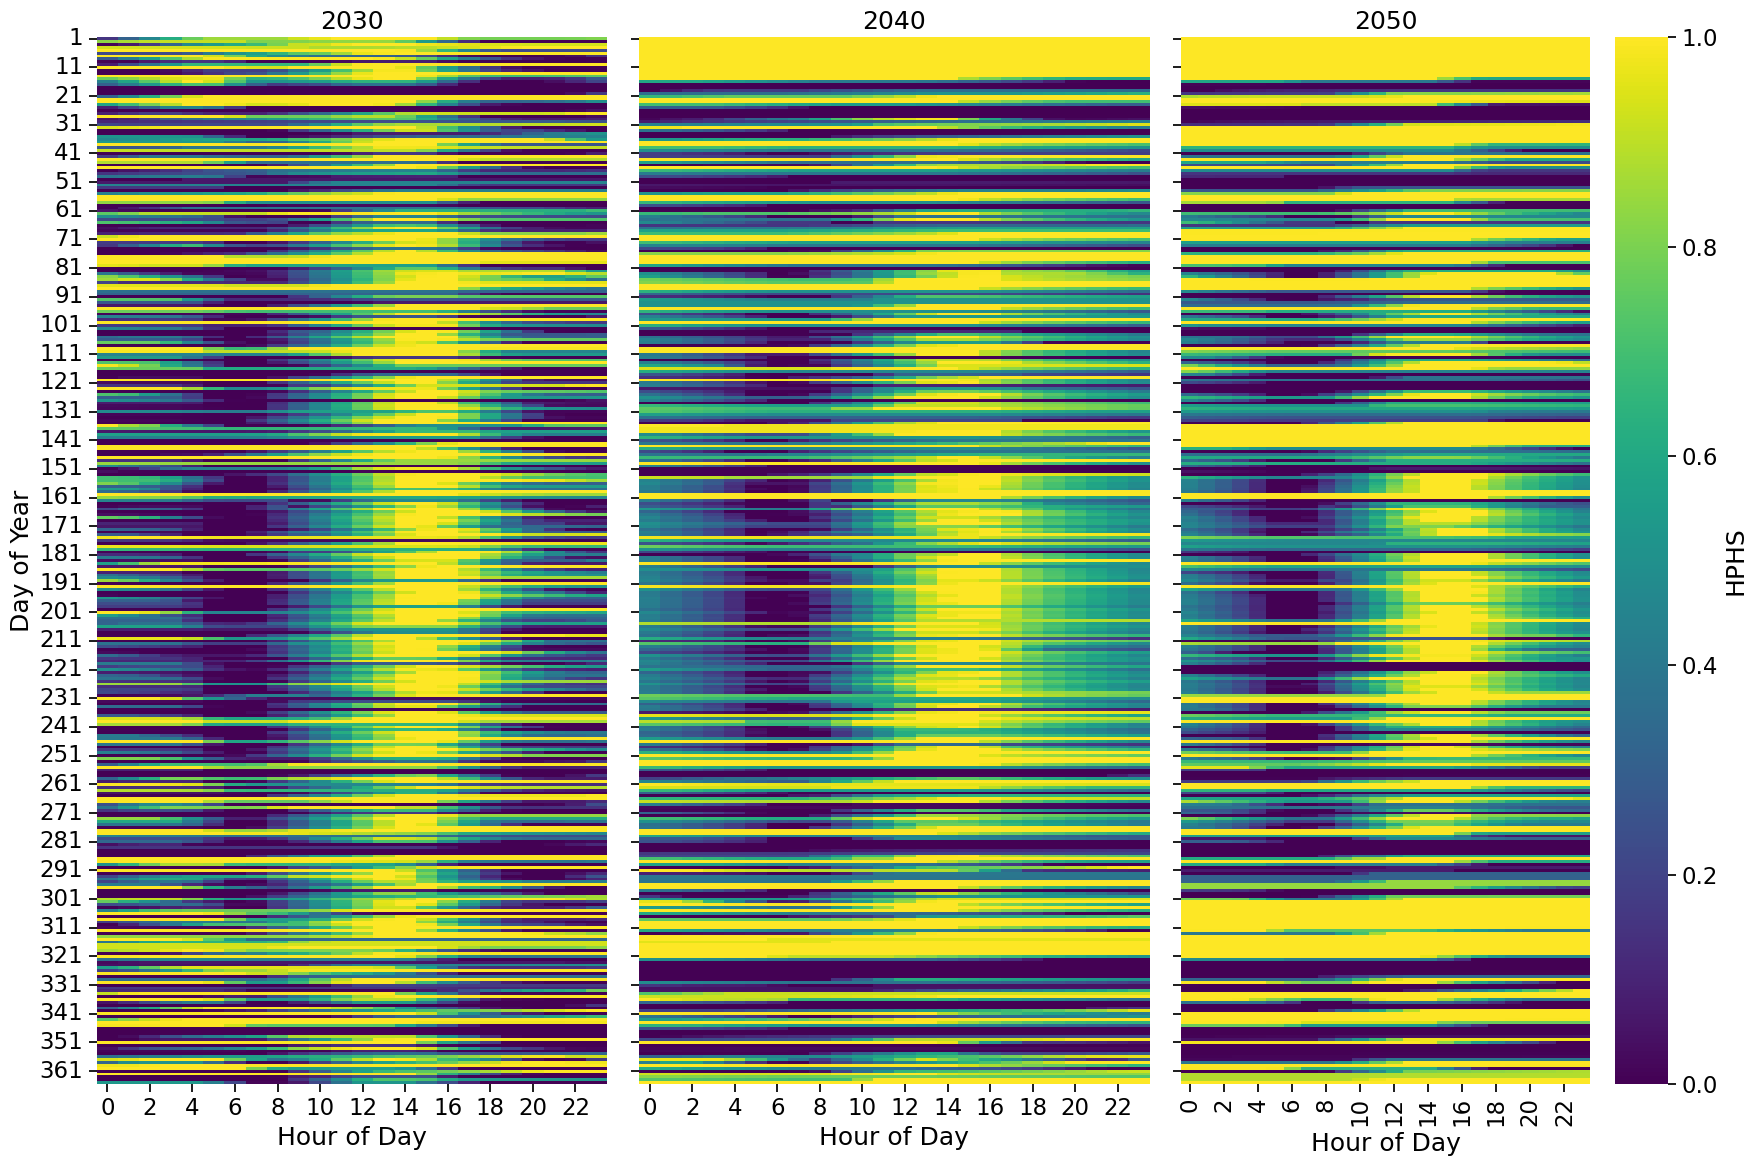

[INFO] Saved: /home/ray/Downloads/ReservoirLevelPlots/Germany_HDAM_2030_2040_2050.pdf


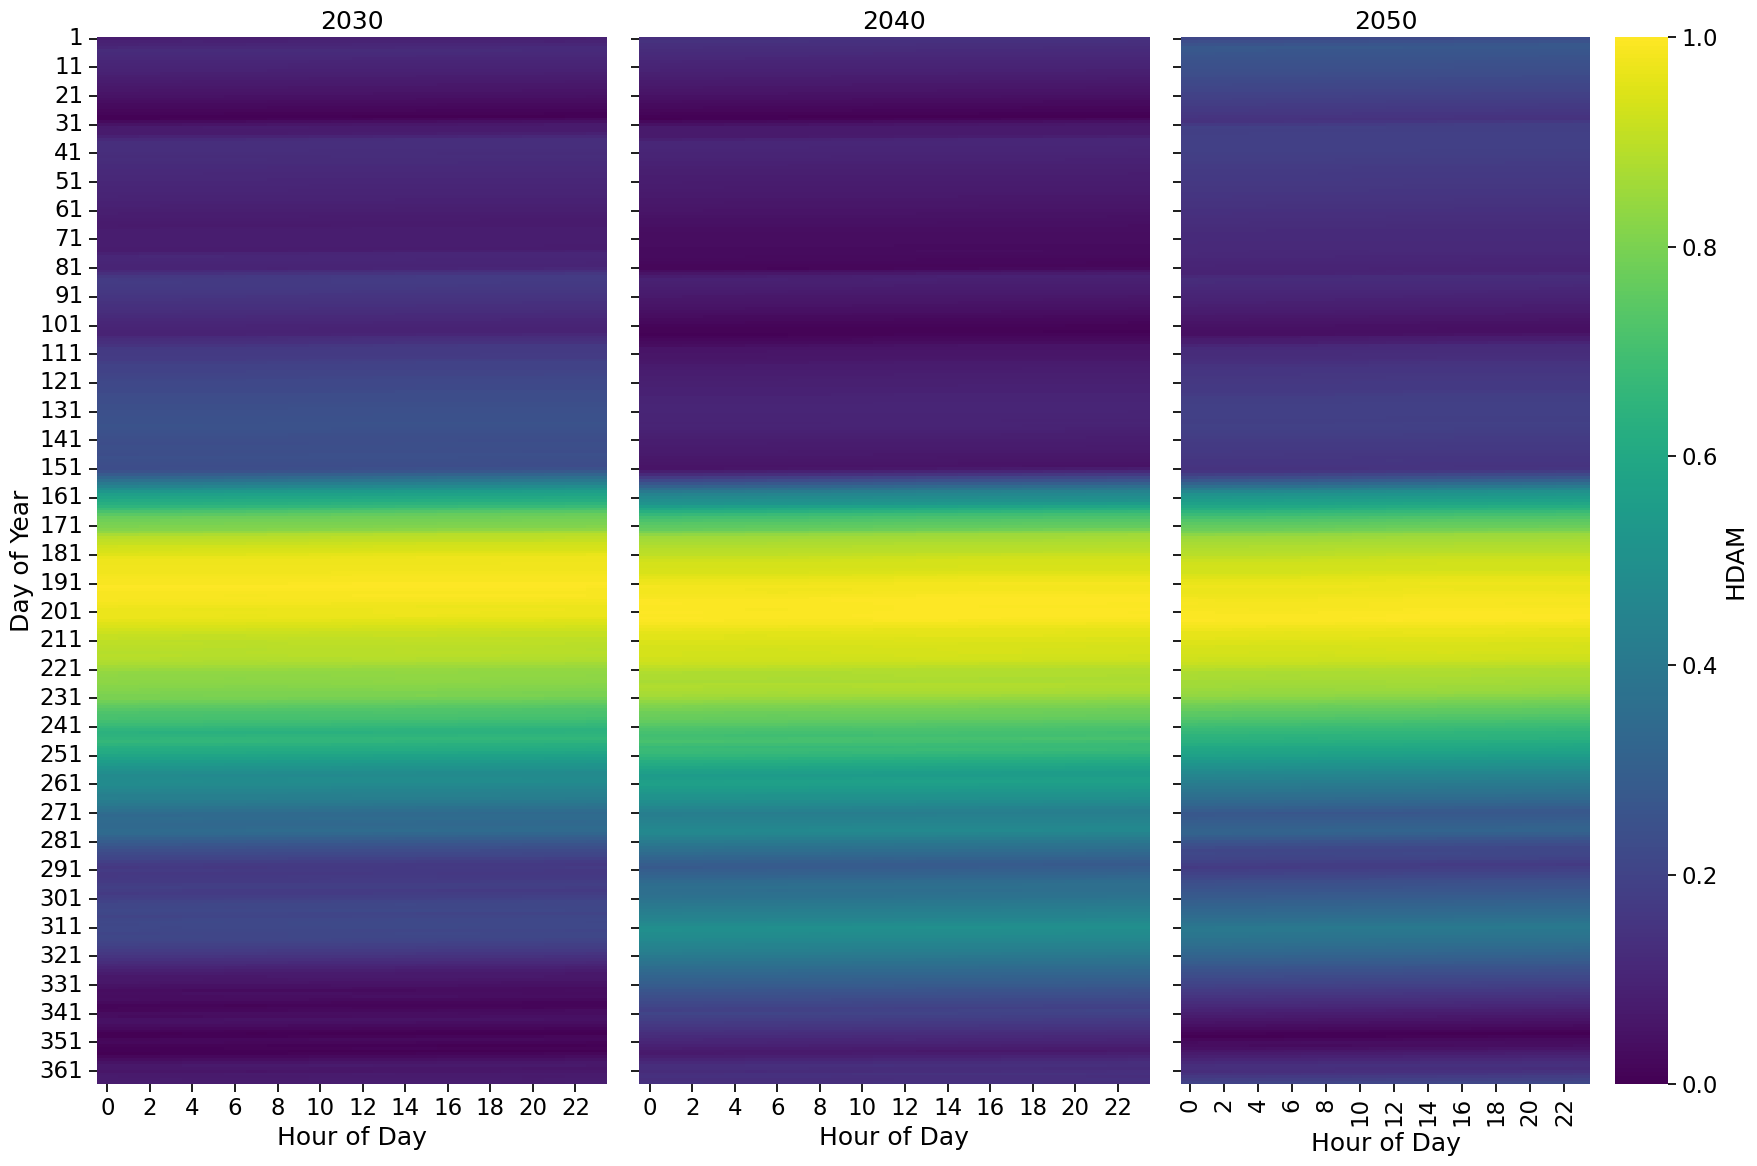

[INFO] Saved: /home/ray/Downloads/ReservoirLevelPlots/France_HPHS_2030_2040_2050.pdf


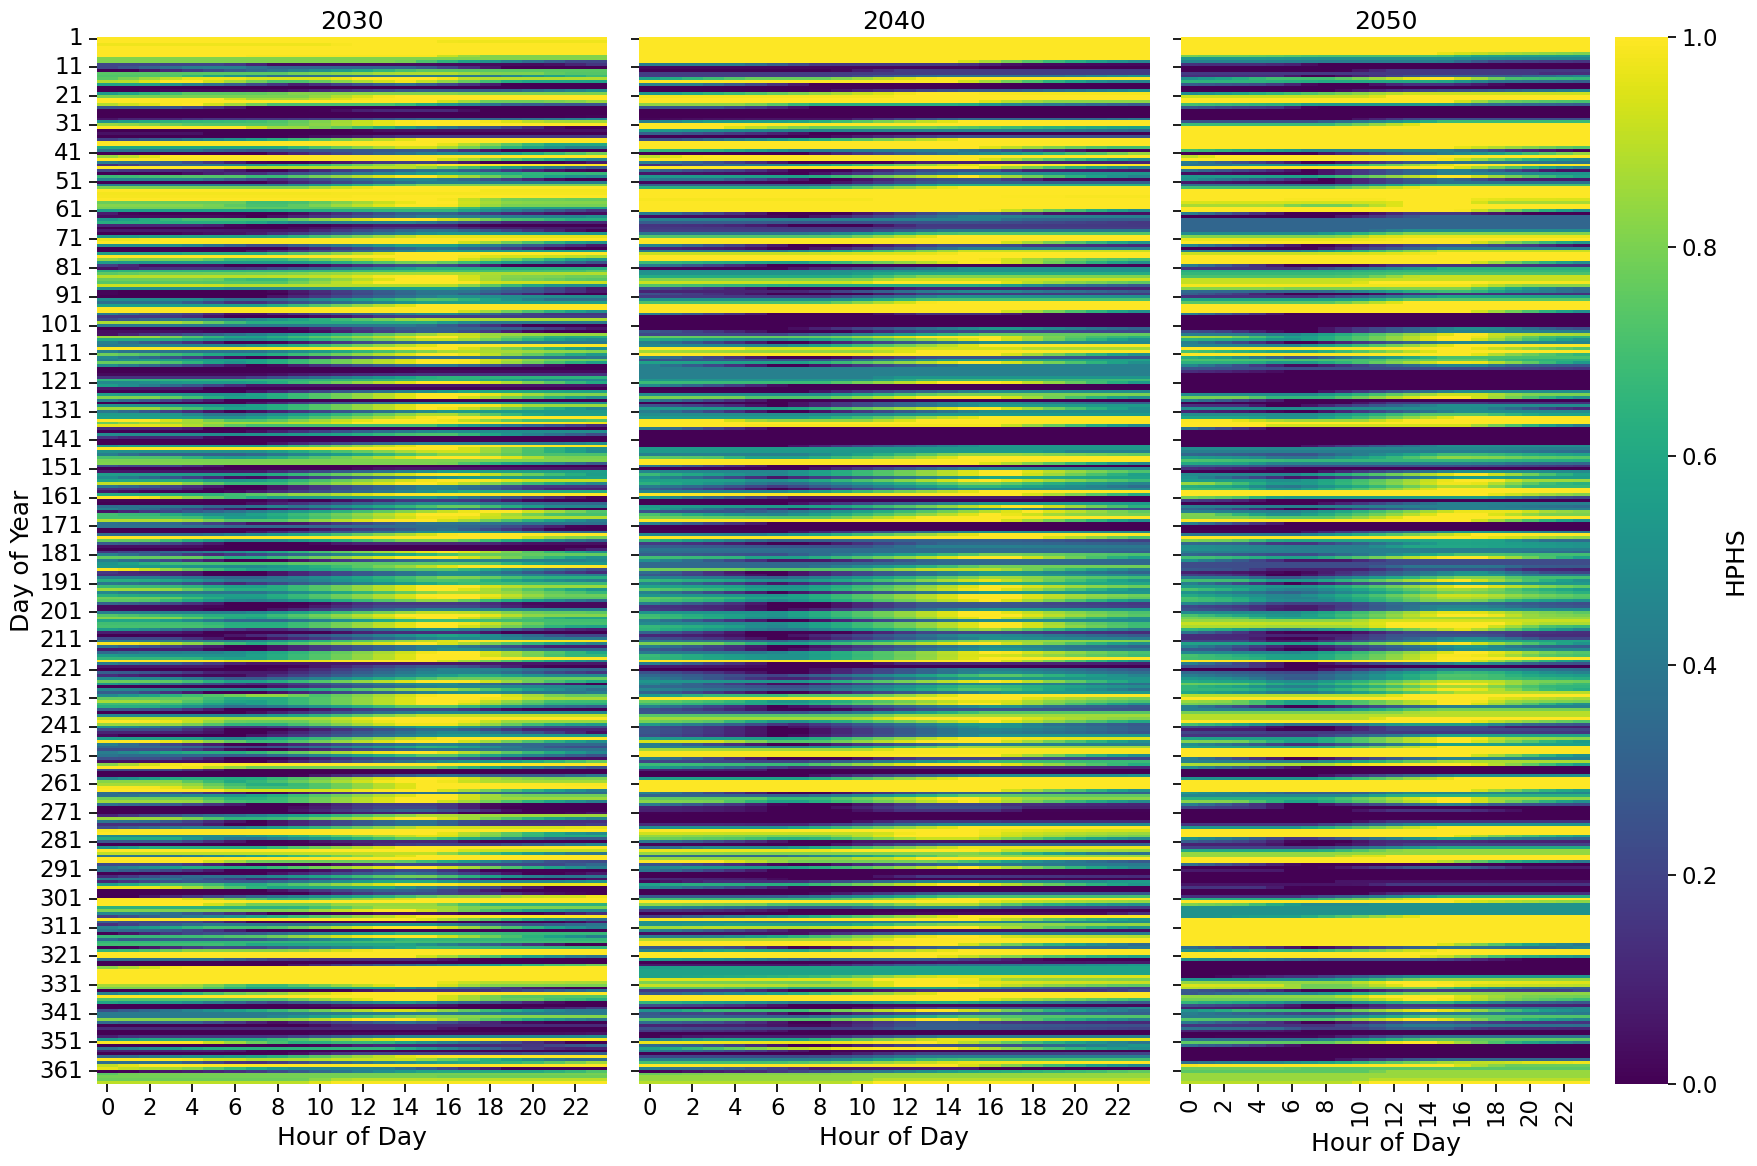

[INFO] Saved: /home/ray/Downloads/ReservoirLevelPlots/France_HDAM_2030_2040_2050.pdf


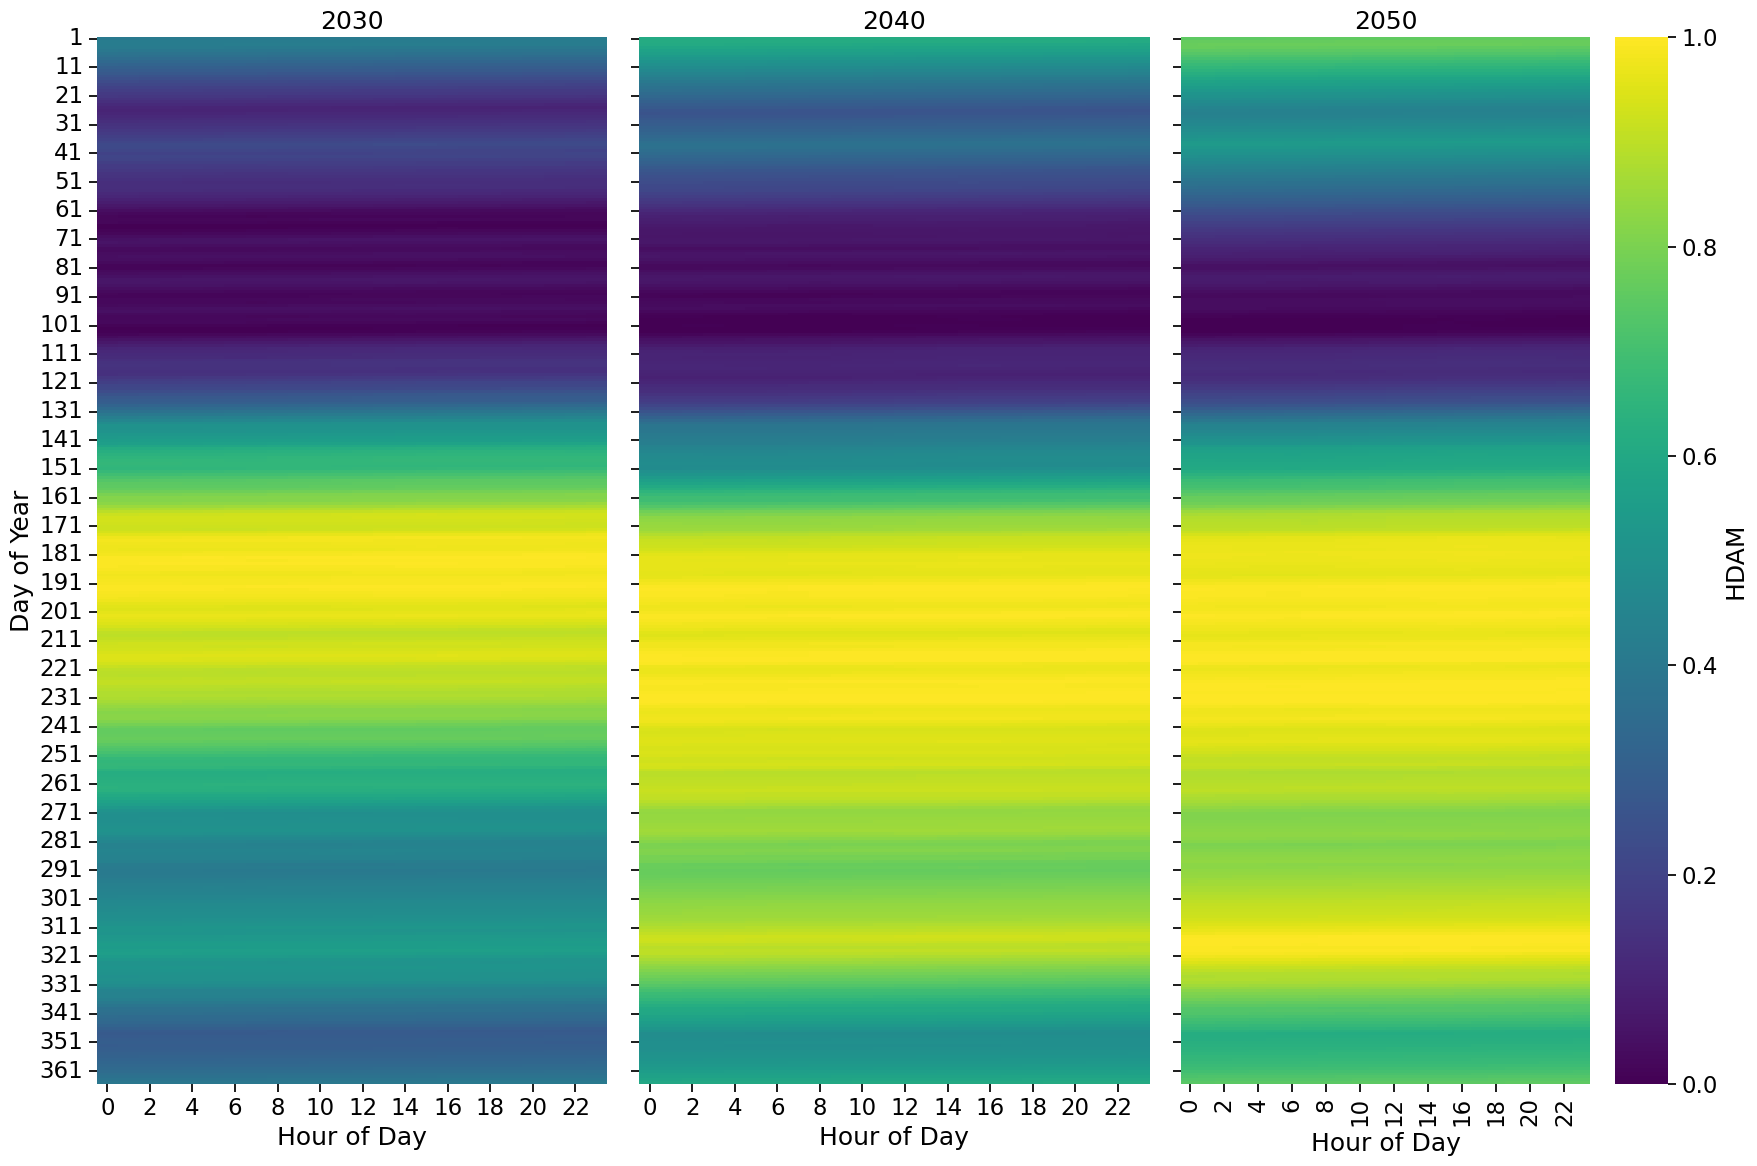

[INFO] Saved: /home/ray/Downloads/ReservoirLevelPlots/Netherlands_HPHS_2030_2040_2050.pdf


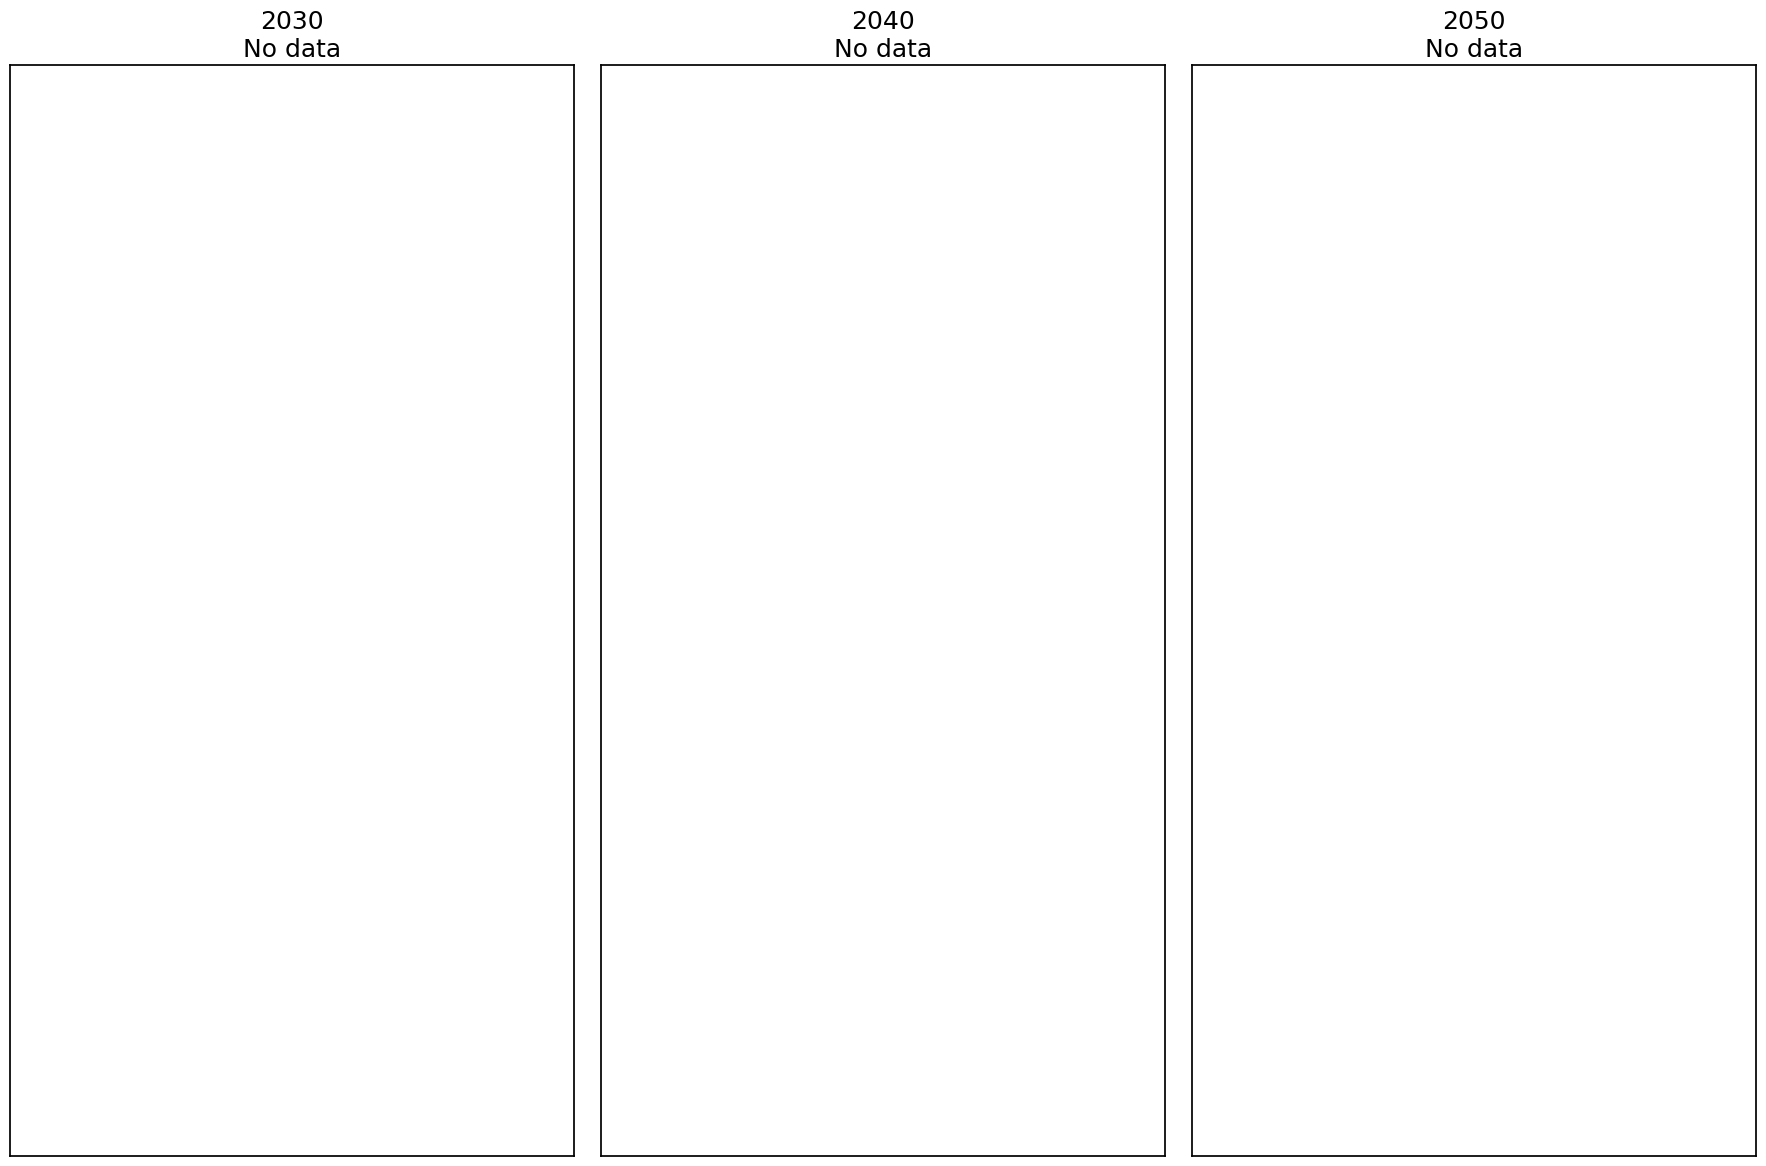

[INFO] Saved: /home/ray/Downloads/ReservoirLevelPlots/Netherlands_HDAM_2030_2040_2050.pdf


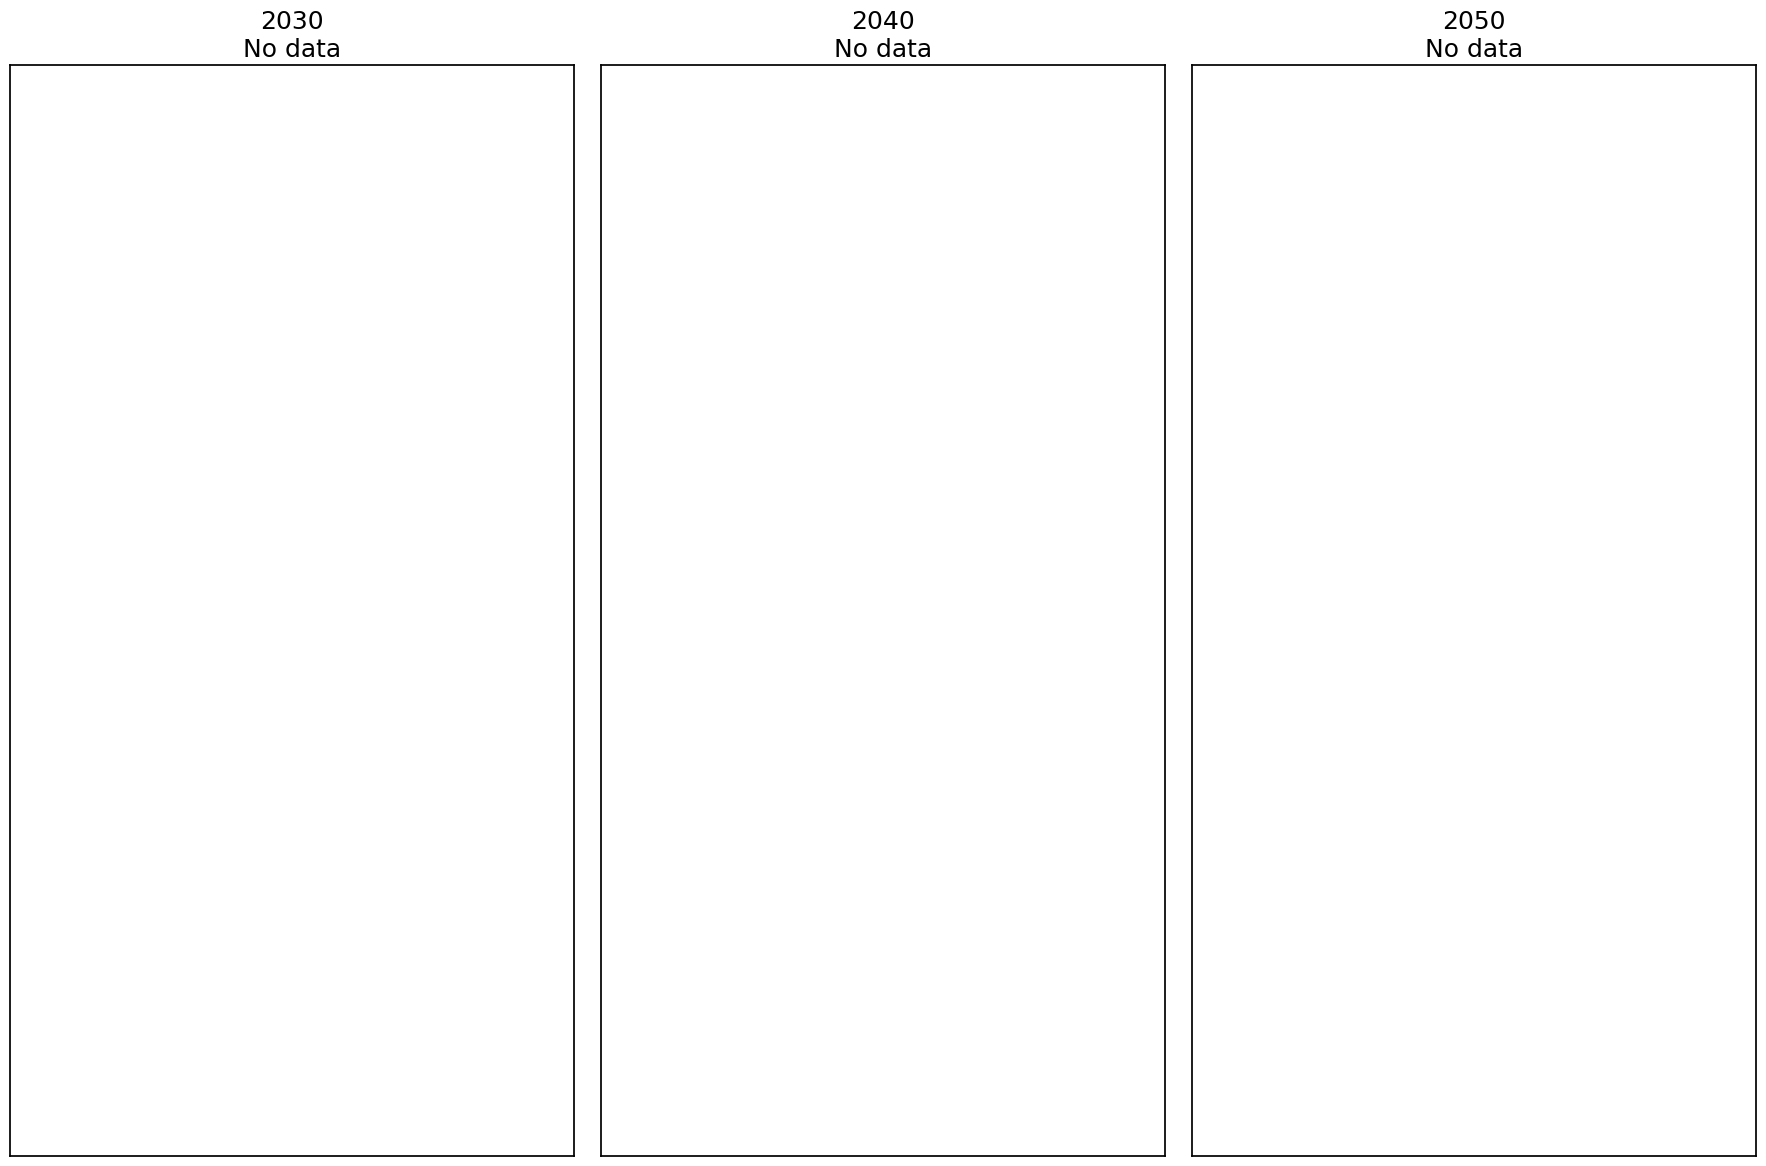

[INFO] Saved: /home/ray/Downloads/ReservoirLevelPlots/UK_HPHS_2030_2040_2050.pdf


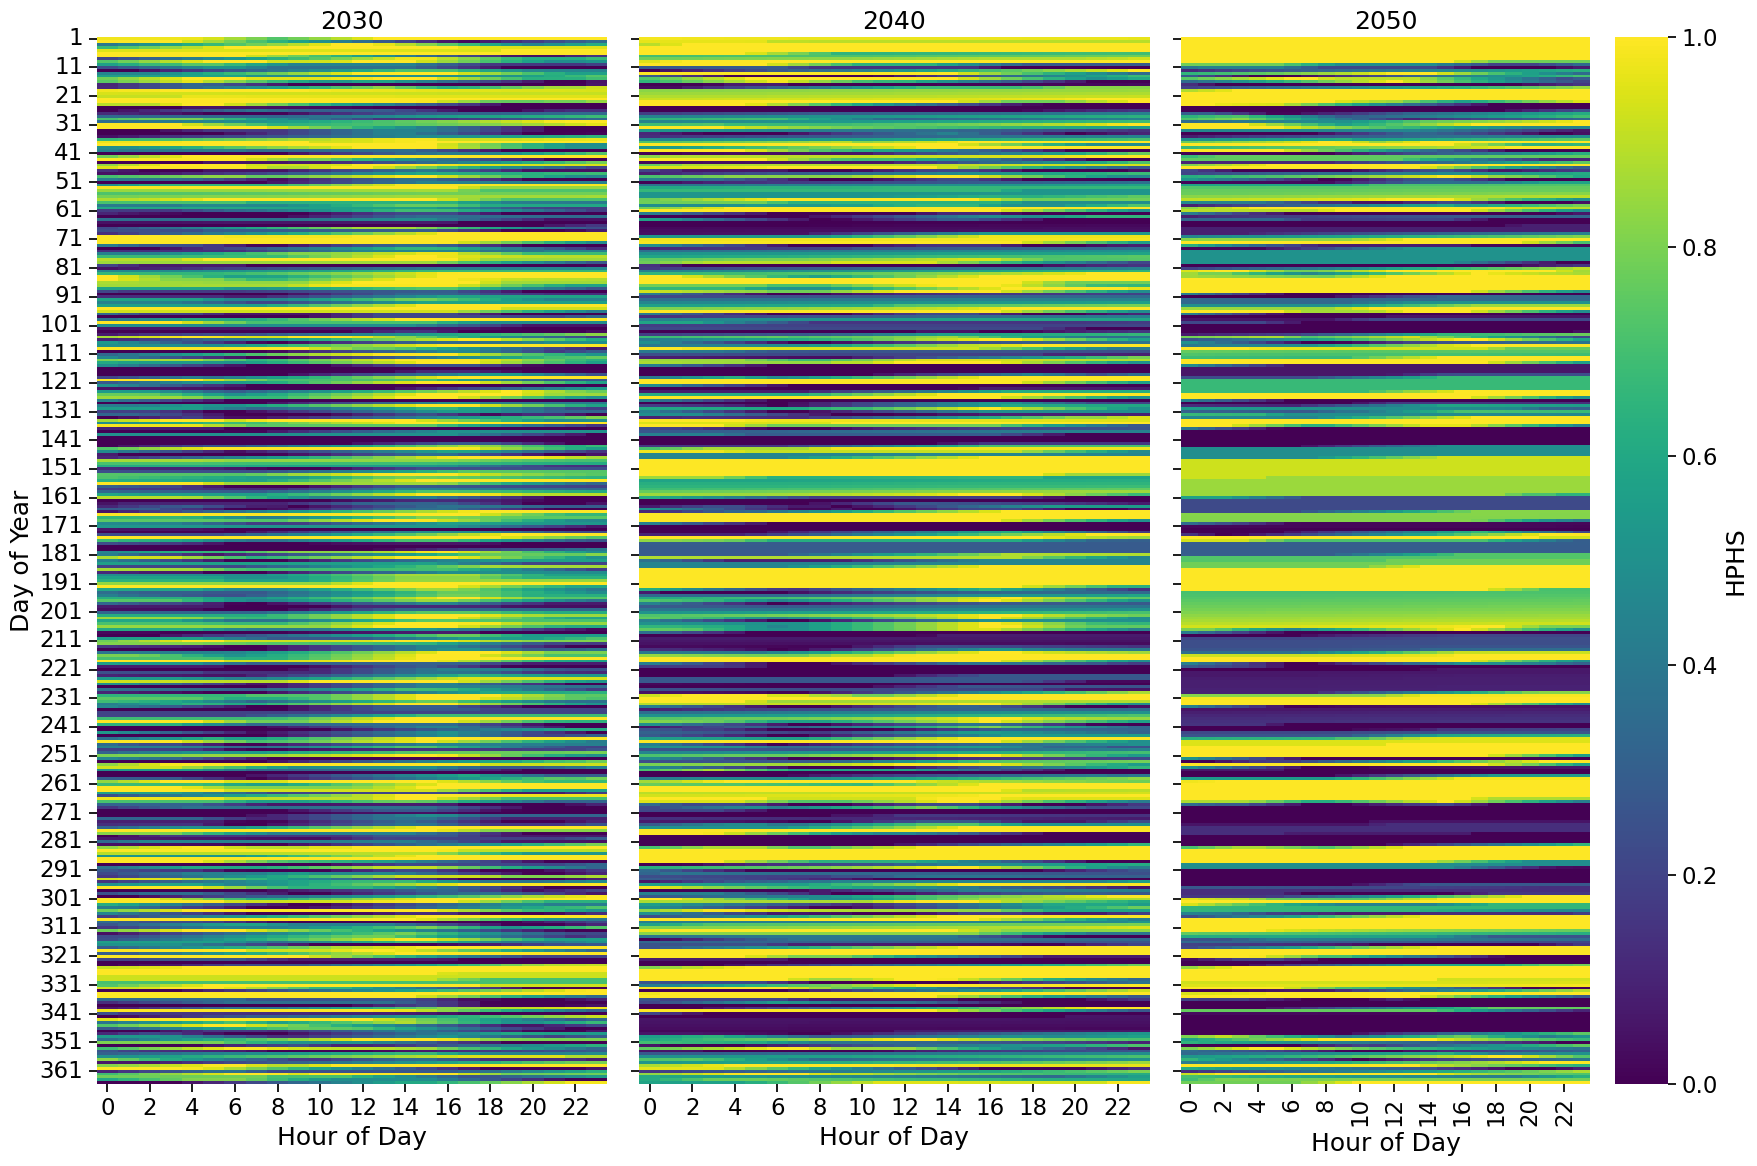

[INFO] Saved: /home/ray/Downloads/ReservoirLevelPlots/UK_HDAM_2030_2040_2050.pdf


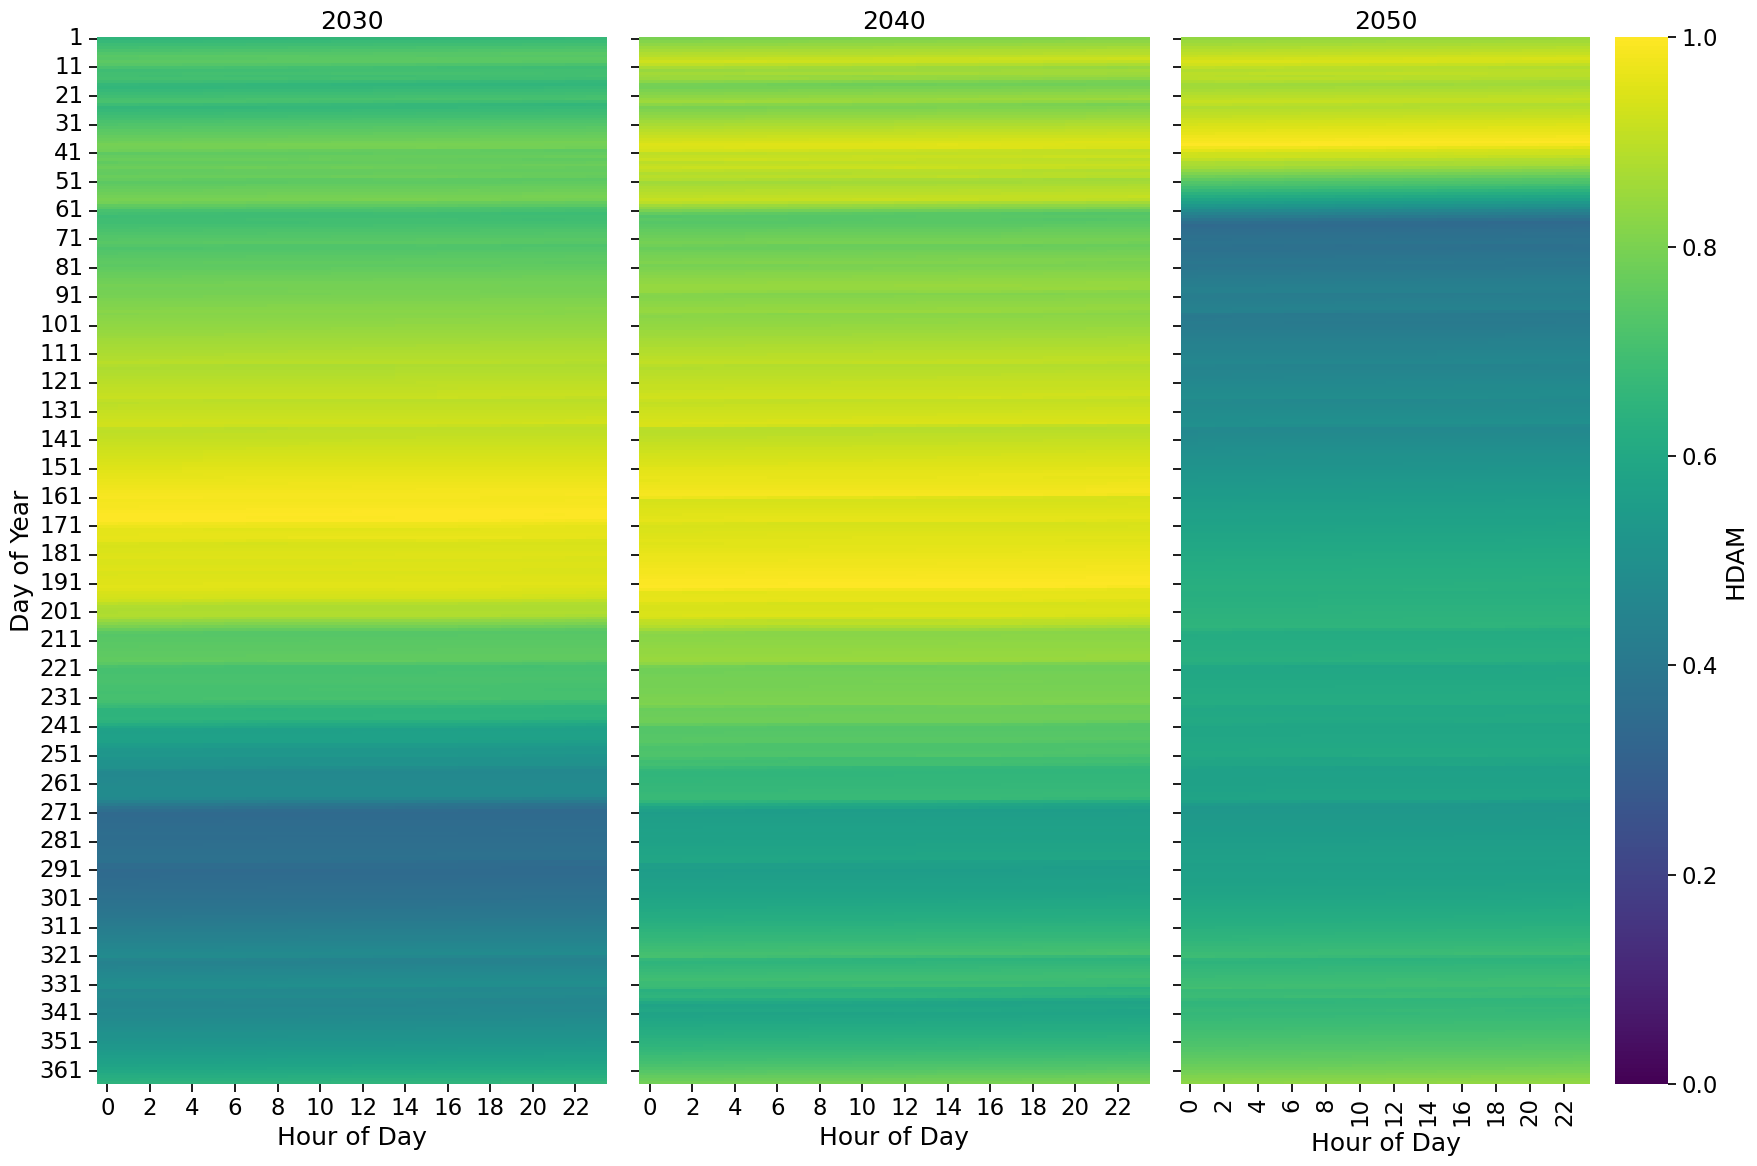

In [79]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------
# USER CONFIGURATION
# ----------------------------------
years = [2030, 2040, 2050]

variables_to_plot = [
    'HPHS',
    'HDAM'
]

countries = {
    'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/BE/1h/',
    'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/DE/1h/',
    'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/FR/1h/',
    'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/NL/1h/',
    'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/UK/1h/',
}

# -------------------------------------------------
# Main loop
# -------------------------------------------------
for country, base_path in countries.items():
    for variable in variables_to_plot:

        yearly_heatmaps = {}
        vmin, vmax = float('inf'), float('-inf')

        # -------------------------
        # Load data for each year
        # -------------------------
        for year in years:
            path = f"{base_path}{year}.csv"

            df = pd.read_csv(path, parse_dates=[0], index_col=0)

            # Safety check
            if variable not in df.columns:
                print(f"[WARNING] {variable} not found in {country} {year}")
                yearly_heatmaps[year] = None
                continue

            df['day'] = df.index.dayofyear
            df['hour'] = df.index.hour

            heatmap_data = df.pivot_table(
                values=variable,
                index='day',
                columns='hour'
            )

            if heatmap_data.empty or heatmap_data.isna().all().all():
                yearly_heatmaps[year] = None
                continue

            yearly_heatmaps[year] = heatmap_data
            vmin = min(vmin, heatmap_data.min().min())
            vmax = max(vmax, heatmap_data.max().max())

        # -------------------------
        # Plot
        # -------------------------
        fig, axes = plt.subplots(
            1, len(years),
            figsize=(18, 12),
            sharey=True
        )

#        fig.suptitle(
 #           f"{variable} – Reservoir Level – {country}",
  #          fontsize=16,
   #         y=1.05
    #    )

        for i, year in enumerate(years):
            ax = axes[i]

            if yearly_heatmaps[year] is None:
                ax.set_title(f"{year}\nNo data")
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            sns.heatmap(
                yearly_heatmaps[year],
                ax=ax,
                cmap='viridis',
                vmin=0,
                vmax=1,
                cbar=i == len(years) - 1,
                cbar_kws={'label': variable}
            )

            ax.set_title(str(year))
            ax.set_xlabel("Hour of Day")
            ax.set_ylabel("Day of Year" if i == 0 else "")

        plt.tight_layout()

                # -------------------------
        # Save figure
        # -------------------------
        output_folder = '/home/ray/Downloads/ReservoirLevelPlots/'
        import os
        os.makedirs(output_folder, exist_ok=True)
        pdf_file = f"{output_folder}{country}_{variable}_2030_2040_2050.pdf"
        plt.savefig(pdf_file, bbox_inches='tight')
        print(f"[INFO] Saved: {pdf_file}")

        plt.show()



In [78]:
import pandas as pd

# --------------------------------------------------
# Countries and paths
# --------------------------------------------------
countries = {
    'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/BE/1h/',
    'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/DE/1h/',
    'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/FR/1h/',
    'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/NL/1h/',
    'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/UK/1h/',
}

years = [2030, 2040, 2050]

# Variables (columns) to analyse
variables_to_analyse = ['HPHS', 'HDAM']

# --------------------------------------------------
# Helper function to compute stats
# --------------------------------------------------
def compute_reservoir_stats(df, variable):
    """
    df: DataFrame with datetime index
    variable: column name (e.g. HPHS, HDAM)
    returns: dict with annual and quarterly averages
    """

    # Ensure datetime index
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, utc=True)

    # Add quarter
    df['Quarter'] = df.index.quarter

    annual_avg = df[variable].mean()

    quarterly_avg = (
        df.groupby('Quarter')[variable]
        .mean()
        .reindex([1, 2, 3, 4])
    )

    return {
        'Annual Avg': annual_avg,
        'Q1 Avg': quarterly_avg.loc[1],
        'Q2 Avg': quarterly_avg.loc[2],
        'Q3 Avg': quarterly_avg.loc[3],
        'Q4 Avg': quarterly_avg.loc[4],
    }

# --------------------------------------------------
# Build final table
# --------------------------------------------------
all_results = []

for country, base_path in countries.items():
    for year in years:
        path = f"{base_path}{year}.csv"

        df = pd.read_csv(path, index_col=0)
        df.index = pd.to_datetime(df.index, utc=True)

        for variable in variables_to_analyse:
            if variable not in df.columns:
                print(f"[WARNING] {variable} not found in {country} {year}")
                continue

            stats = compute_reservoir_stats(df, variable)

            all_results.append({
                'Country': country,
                'Year': year,
                'Variable': variable,
                'Annual Avg (%)': stats['Annual Avg'] * 100,
                'Q1 Avg (%)': stats['Q1 Avg'] * 100,
                'Q2 Avg (%)': stats['Q2 Avg'] * 100,
                'Q3 Avg (%)': stats['Q3 Avg'] * 100,
                'Q4 Avg (%)': stats['Q4 Avg'] * 100,
            })


final_table = pd.DataFrame(all_results).round(2)

print(final_table)


        Country  Year Variable  Annual Avg (%)  Q1 Avg (%)  Q2 Avg (%)  \
0       Belgium  2030     HPHS           53.88       58.02       49.35   
1       Belgium  2030     HDAM           92.85       90.89       98.01   
2       Belgium  2040     HPHS           54.70       62.20       48.86   
3       Belgium  2040     HDAM           94.59       93.88       97.57   
4       Belgium  2050     HPHS           59.28       71.89       54.89   
5       Belgium  2050     HDAM           95.52       95.93       98.19   
6       Germany  2030     HPHS           47.62       50.94       46.74   
7       Germany  2030     HDAM           33.63        9.43       35.87   
8       Germany  2040     HPHS           53.47       56.92       52.54   
9       Germany  2040     HDAM           35.39        6.65       25.38   
10      Germany  2050     HPHS           53.64       60.94       49.32   
11      Germany  2050     HDAM           35.87       16.69       30.02   
12       France  2030     HPHS        

In [77]:
import pandas as pd

countries = {
    'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/BE/1h/',
    'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/DE/1h/',
    'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/FR/1h/',
    'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/NL/1h/',
    'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/UK/1h/',
}

years = [2030, 2040, 2050]
variables = ['HPHS', 'HDAM']

def compute_quarterly_stats(df, variable):
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, utc=True)

    df['Quarter'] = df.index.quarter

    return {
        'Annual Avg': df[variable].mean(),
        'Q1 Avg': df[df['Quarter'] == 1][variable].mean(),
        'Q2 Avg': df[df['Quarter'] == 2][variable].mean(),
        'Q3 Avg': df[df['Quarter'] == 3][variable].mean(),
        'Q4 Avg': df[df['Quarter'] == 4][variable].mean(),
    }

final_results = []

for country, base_path in countries.items():
    for variable in variables:

        yearly_stats = []

        for year in years:
            path = f"{base_path}{year}.csv"

            df = pd.read_csv(path, index_col=0)
            df.index = pd.to_datetime(df.index, utc=True)

            if variable not in df.columns:
                print(f"[WARNING] {variable} missing in {country} {year}")
                continue

            stats = compute_quarterly_stats(df, variable)
            yearly_stats.append(stats)

        # Skip if no data
        if not yearly_stats:
            continue

        # Convert to DataFrame and average over years
        stats_df = pd.DataFrame(yearly_stats)
        mean_stats = stats_df.mean()

        final_results.append({
            'Country': country,
            'Variable': variable,
            'Annual Avg (%)': mean_stats['Annual Avg'] * 100,
            'Q1 Avg (%)': mean_stats['Q1 Avg'] * 100,
            'Q2 Avg (%)': mean_stats['Q2 Avg'] * 100,
            'Q3 Avg (%)': mean_stats['Q3 Avg'] * 100,
            'Q4 Avg (%)': mean_stats['Q4 Avg'] * 100,
        })

final_table = pd.DataFrame(final_results).round(2)
print(final_table)


       Country Variable  Annual Avg (%)  Q1 Avg (%)  Q2 Avg (%)  Q3 Avg (%)  \
0      Belgium     HPHS           55.95       64.04       51.03       49.56   
1      Belgium     HDAM           94.32       93.57       97.92       95.82   
2      Germany     HPHS           51.58       56.27       49.53       50.42   
3      Germany     HDAM           34.96       10.92       30.42       76.40   
4       France     HPHS           52.38       59.25       46.26       51.40   
5       France     HDAM           56.63       25.31       43.48       90.99   
6  Netherlands     HPHS             NaN         NaN         NaN         NaN   
7  Netherlands     HDAM             NaN         NaN         NaN         NaN   
8           UK     HPHS           52.34       58.37       48.57       51.51   
9           UK     HDAM           70.05       75.92       77.56       69.29   

   Q4 Avg (%)  
0       59.28  
1       89.98  
2       50.15  
3       21.63  
4       52.65  
5       66.09  
6         NaN  
7 

In [88]:
import pandas as pd

# Define scenarios and paths
scenarios = {
    'Reference_Scenario': {
        'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ScaledInflows/BE/1h/',
        'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ScaledInflows/DE/1h/',
        'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ScaledInflows/FR/1h/',
        'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ScaledInflows/NL/1h/',
        'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ScaledInflows/UK/1h/',
    },
    'Suficiency_Scenario': {
        'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/HydroData/ScaledInflows/BE/1h/',
        'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/HydroData/ScaledInflows/DE/1h/',
        'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/HydroData/ScaledInflows/FR/1h/',
        'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/HydroData/ScaledInflows/NL/1h/',
        'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/HydroData/ScaledInflows/UK/1h/',
    }
}

years = [2030, 2040, 2050]

# Variables (columns) to analyze
variables_to_analyse = ['HPHS', 'HDAM']

# Helper function to compute stats
def compute_reservoir_stats(df, variable):
    """
    df: DataFrame with datetime index
    variable: column name (e.g., HPHS, HDAM)
    returns: dict with annual and quarterly averages
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, utc=True)

    df['Quarter'] = df.index.quarter

    annual_avg = df[variable].mean()

    quarterly_avg = (
        df.groupby('Quarter')[variable]
        .mean()
        .reindex([1, 2, 3, 4])
    )

    return {
        'Annual Avg': annual_avg,
        'Q1 Avg': quarterly_avg.loc[1],
        'Q2 Avg': quarterly_avg.loc[2],
        'Q3 Avg': quarterly_avg.loc[3],
        'Q4 Avg': quarterly_avg.loc[4],
    }

# Build final table
all_results = []

for scenario_name, countries in scenarios.items():
    for country, base_path in countries.items():
        for year in years:
            path = f"{base_path}{year}.csv"

            try:
                df = pd.read_csv(path, index_col=0)
                df.index = pd.to_datetime(df.index, utc=True)
            except FileNotFoundError:
                print(f"[WARNING] File not found: {path}")
                continue

            for variable in variables_to_analyse:
                if variable not in df.columns:
                    print(f"[WARNING] {variable} not found in {country} {year} ({scenario_name})")
                    continue

                stats = compute_reservoir_stats(df, variable)

                all_results.append({
                    'Scenario': scenario_name,
                    'Country': country,
                    'Year': year,
                    'Variable': variable,
                    'Annual Avg (%)': stats['Annual Avg'] * 100,
                    'Q1 Avg (%)': stats['Q1 Avg'] * 100,
                    'Q2 Avg (%)': stats['Q2 Avg'] * 100,
                    'Q3 Avg (%)': stats['Q3 Avg'] * 100,
                    'Q4 Avg (%)': stats['Q4 Avg'] * 100,
                })

final_table = pd.DataFrame(all_results).round(2)

# Sort the table for better readability
final_table = final_table.sort_values(by=['Scenario', 'Country', 'Year', 'Variable'])

print(final_table)


               Scenario      Country  Year Variable  Annual Avg (%)  \
1    Reference_Scenario      Belgium  2030     HDAM           52.08   
0    Reference_Scenario      Belgium  2030     HPHS            7.08   
3    Reference_Scenario      Belgium  2040     HDAM           52.36   
2    Reference_Scenario      Belgium  2040     HPHS            6.12   
5    Reference_Scenario      Belgium  2050     HDAM           52.52   
4    Reference_Scenario      Belgium  2050     HPHS            6.04   
13   Reference_Scenario       France  2030     HDAM           45.12   
12   Reference_Scenario       France  2030     HPHS           20.41   
15   Reference_Scenario       France  2040     HDAM           45.21   
14   Reference_Scenario       France  2040     HPHS           15.83   
17   Reference_Scenario       France  2050     HDAM           45.14   
16   Reference_Scenario       France  2050     HPHS           12.88   
7    Reference_Scenario      Germany  2030     HDAM           70.54   
6    R

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# ----------------------------------
# USER CONFIGURATION
# ----------------------------------
years = [2030, 2040, 2050]

variables_to_plot = [
    'HPHS',
    'HDAM'
]

# Define scenarios and countries
scenarios = {
    'Reference_Scenario': {
        'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ScaledInflows/BE/1h/',
        'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ScaledInflows/DE/1h/',
        'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ScaledInflows/FR/1h/',
        'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ScaledInflows/NL/1h/',
        'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ScaledInflows/UK/1h/',
    },
    'Suficiency_Scenario': {
        'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/HydroData/ScaledInflows/BE/1h/',
        'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/HydroData/ScaledInflows/DE/1h/',
        'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/HydroData/ScaledInflows/FR/1h/',
        'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/HydroData/ScaledInflows/NL/1h/',
        'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/HydroData/ScaledInflows/UK/1h/',
    }
}

# -------------------------------------------------
# Main loop
# -------------------------------------------------
for scenario_name, countries in scenarios.items():
    for country, base_path in countries.items():
        for variable in variables_to_plot:
            yearly_heatmaps = {}
            vmin, vmax = float('inf'), float('-inf')

            # -------------------------
            # Load data for each year
            # -------------------------
            for year in years:
                path = f"{base_path}{year}.csv"

                try:
                    df = pd.read_csv(path, parse_dates=[0], index_col=0)
                except FileNotFoundError:
                    print(f"[WARNING] File not found: {path}")
                    yearly_heatmaps[year] = None
                    continue

                # Safety check
                if variable not in df.columns:
                    print(f"[WARNING] {variable} not found in {country} {year} ({scenario_name})")
                    yearly_heatmaps[year] = None
                    continue

                df['day'] = df.index.dayofyear
                df['hour'] = df.index.hour

                heatmap_data = df.pivot_table(
                    values=variable,
                    index='day',
                    columns='hour'
                )

                if heatmap_data.empty or heatmap_data.isna().all().all():
                    yearly_heatmaps[year] = None
                    continue

                yearly_heatmaps[year] = heatmap_data
                vmin = min(vmin, heatmap_data.min().min())
                vmax = max(vmax, heatmap_data.max().max())

            # -------------------------
            # Plot
            # -------------------------
            fig, axes = plt.subplots(
                1, len(years),
                figsize=(18, 12),
                sharey=True
            )

#            fig.suptitle(
 #               f"{scenario_name} – {variable} – {country}",
  #              fontsize=16,
   #             y=1.05
    #        )

            for i, year in enumerate(years):
                ax = axes[i]

                if yearly_heatmaps[year] is None:
                    ax.set_title(f"{year}\nNo data")
                    ax.set_xticks([])
                    ax.set_yticks([])
                    continue

                sns.heatmap(
                    yearly_heatmaps[year],
                    ax=ax,
                    cmap='viridis',
                    vmin=0,
                    vmax=1,
                    cbar=i == len(years) - 1,
                    cbar_kws={'label': variable}
                )

                ax.set_title(str(year))
                ax.set_xlabel("Hour of Day")
                ax.set_ylabel("Day of Year" if i == 0 else "")

            plt.tight_layout()

            # -------------------------
            # Save figure
            # -------------------------
            output_folder = f'/home/ray/Downloads/ScaledInflowsPlots/{scenario_name}/'
            os.makedirs(output_folder, exist_ok=True)
            pdf_file = f"{output_folder}{scenario_name}_{country}_{variable}_2030_2040_2050.pdf"
            plt.savefig(pdf_file, bbox_inches='tight')
            print(f"[INFO] Saved: {pdf_file}")

            plt.close()

print("[INFO] All plots saved successfully.")


ParserError: Expected 3 fields in line 1, saw 4. Error could possibly be due to quotes being ignored when a multi-char delimiter is used.

In [99]:
import os
import pandas as pd

# Define the directories
directories = [
    "/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/NTC/1h",
    "/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/NTC/1h"
]

# Initialize a list to store the results
results = []

# Iterate over each directory
for directory in directories:
    # Get the scenario name from the directory path
    scenario = directory.split('/')[-3]

    # Iterate over each file in the directory
    for filename in os.listdir(directory):
        if filename.endswith('.csv'):
            # Extract the year from the filename (assuming filenames are like '2020.csv')
            year = filename.split('.')[0]

            # Load the CSV file into a DataFrame
            filepath = os.path.join(directory, filename)
            df = pd.read_csv(filepath)

            # Calculate the average of numerical columns
            numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
            averages = df[numerical_cols].mean()

            # Append the results to the list
            for col, avg in averages.items():
                results.append({
                    'Scenario': scenario,
                    'Year': year,
                    'NTC': col,
                    'Average Value': avg
                })

# Convert the results to a DataFrame
results_df = pd.DataFrame(results)

# Display the results
print(results_df)

results_df

results_df.to_csv('/home/ray/Downloads/results_df_1.csv', index=False)

                Scenario  Year       NTC  Average Value
0     Reference_Scenario  2050  BE -> FR    7135.367553
1     Reference_Scenario  2050  BE -> DE    2460.374461
2     Reference_Scenario  2050  BE -> UK    2460.374262
3     Reference_Scenario  2050  BE -> NL    7512.016221
4     Reference_Scenario  2050  DE -> FR    5361.961510
..                   ...   ...       ...            ...
115  Suficiency_Scenario  2040  UK -> BE    1822.498563
116  Suficiency_Scenario  2040  DE -> UK    2551.496647
117  Suficiency_Scenario  2040  FR -> NL       0.000000
118  Suficiency_Scenario  2040  NL -> FR       0.000000
119  Suficiency_Scenario  2040  UK -> DE    2551.496647

[120 rows x 4 columns]


In [97]:
results_df

,Scenario,Year,Cross Border Flow,Average Value
0,Reference_Scenario,2050,RoW -> NL,NaN
1,Reference_Scenario,2050,FR -> BE,4138.983890
2,Reference_Scenario,2050,FR -> NL,NaN
3,Reference_Scenario,2050,NL -> DE,5969.628076
4,Reference_Scenario,2050,UK -> RoW,NaN
...,...,...,...,...
175,Suficiency_Scenario,2040,BE -> NL,3334.005090
176,Suficiency_Scenario,2040,DE -> BE,507.326209
177,Suficiency_Scenario,2040,FR -> UK,1181.105912
178,Suficiency_Scenario,2040,BE -> FR,3216.761173


In [104]:
import pandas as pd
import os

# List of CSV files (replace with your actual file paths)
csv_files = [
    "/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/CrossBorderFlows/1h/2030.csv", 
    "/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/CrossBorderFlows/1h/2040.csv",
    "/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/CrossBorderFlows/1h/2050.csv", 
    "/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/CrossBorderFlows/1h/2030.csv",
    "/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/CrossBorderFlows/1h/2040.csv", 
    "/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/CrossBorderFlows/1h/2050.csv"
]

# Define country pairs and directions
countries = ["UK", "DE", "NL", "FR", "BE", "RoW"]

# Initialize a dictionary to store results for each file
results = {}

for file in csv_files:
    # Read the CSV file
    df = pd.read_csv(file, index_col=0, parse_dates=True)

    # Initialize DataFrames for imports and exports
    imports = pd.DataFrame(0, index=df.index, columns=countries)
    exports = pd.DataFrame(0, index=df.index, columns=countries)

    # Aggregate imports and exports
    for country in countries:
        for col in df.columns:
            if "->" in col:
                source, target = col.split(" -> ")
                if target == country:
                    imports[country] += df[col].fillna(0)
                if source == country:
                    exports[country] += df[col].fillna(0)

    # Calculate net flow (imports - exports)
    net_flow = imports - exports

    # Store results
    results[file] = {
        "imports": imports,
        "exports": exports,
        "net_flow": net_flow
    }

# Example: Access results for a specific file
for file, data in results.items():
    print(f"Results for {file}:")
    print("Imports:")
    print(data["imports"].head())
    print("\nExports:")
    print(data["exports"].head())
    print("\nNet Flow:")
    print(data["net_flow"].head())
    print("\n" + "="*50 + "\n")



Results for /home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/CrossBorderFlows/1h/2030.csv:
Imports:
                      UK            DE           NL            FR  \
index                                                               
2030-01-01 00:00:00  0.0   7796.852298     0.484708  40931.599680   
2030-01-01 01:00:00  0.0   8499.190845  2820.289236  40863.279749   
2030-01-01 02:00:00  0.0   8453.511901   748.588557  40736.171541   
2030-01-01 03:00:00  0.0   8283.684847   914.066061  42091.836159   
2030-01-01 04:00:00  0.0  10019.225410  5926.379705  41853.452361   

                              BE  RoW  
index                                  
2030-01-01 00:00:00  9188.806817  0.0  
2030-01-01 01:00:00  9761.404156  0.0  
2030-01-01 02:00:00  9723.036423  0.0  
2030-01-01 03:00:00  9576.906692  0.0  
2030-01-01 04:00:00  9449.880842  0.0  

Exports:
                               UK           DE            NL   FR  \
index                                       

In [264]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from pathlib import Path

# --------------------------------------------------
# CONFIGURATION
# --------------------------------------------------

CSV_FILES = {
    "2030 Reference": "/home/ray/Downloads/Downloads/Cross_Border_Flows/reference/2030_net_flow.csv",
    "2040 Reference": "/home/ray/Downloads/Downloads/Cross_Border_Flows/reference/2040_net_flow.csv",
    "2050 Reference": "/home/ray/Downloads/Downloads/Cross_Border_Flows/reference/2050_net_flow.csv",
    "2030 Sufficiency": "/home/ray/Downloads/Downloads/Cross_Border_Flows/sufficiency/2030_net_flow.csv",
    "2040 Sufficiency": "/home/ray/Downloads/Downloads/Cross_Border_Flows/sufficiency/2040_net_flow.csv",
    "2050 Sufficiency": "/home/ray/Downloads/Downloads/Cross_Border_Flows/sufficiency/2050_net_flow.csv",
}

OUTPUT_DIR = Path(
    "/home/ray/Downloads/Downloads/Cross_Border_Flows/plots/net_calendars"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COUNTRIES = ["UK", "DE", "NL", "FR", "BE"]

FIGSIZE = (10, 12)
CMAP = "RdBu_r"   # blue = import, red = export

# --------------------------------------------------
# FUNCTION TO CREATE NET FLOW CALENDAR
# --------------------------------------------------

def plot_net_flow_calendar(df, title):
    df.index = pd.to_datetime(df.index)

    # Time features
    df["day"] = df.index.dayofyear
    df["hour"] = df.index.hour

    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(COUNTRIES),
        figsize=(17, 10.5),
        sharey=True,
        constrained_layout=True
    )

    # Diverging normalization
    norm = colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    for ax, country in zip(axes, COUNTRIES):
        pivot = (
            df.pivot_table(
                index="day",
                columns="hour",
                values=country,
                aggfunc="sum"
            )
            .sort_index()
        )

        max_abs = np.abs(pivot.values).max()
        pivot_norm = pivot / max_abs if max_abs != 0 else pivot

        im = ax.imshow(
            pivot_norm,
            aspect="auto",
            cmap="RdBu_r",
            norm=norm,
            origin="lower"
        )

        ax.set_title(country, fontsize=18)

        # Annotate max value
        ax.text(
            0.5, -0.1,
            f"Max |net| = {max_abs:,.0f} MW",
            transform=ax.transAxes,
            ha="center",
            fontsize=15
        )

        ax.set_xticks(range(0, 24, 3))
        ax.set_yticks(range(1, 366, 10))

        ax.tick_params(axis="x", labelsize=13)
        ax.tick_params(axis="y", labelsize=13)

    # Shared labels
    axes[0].set_ylabel("Day of year", fontsize=16)
    fig.supxlabel("Hour of day", fontsize=16, y=0.035)

    # Colorbar
    cbar = fig.colorbar(
        im,
        ax=axes,
        orientation="vertical",
        shrink=0.85,
        pad=0.02
    )

    cbar.set_ticks([-1, 0, 1])
    cbar.set_ticklabels([])  # Clear default labels

    # Manually add text with different font sizes
    cbar.ax.text(1.2, 0.1, "(Imports)", fontsize=13, rotation=90, ha="left", va="center", transform=cbar.ax.transAxes)
    cbar.ax.text(1.2, 0.0, "-1.0"      , fontsize=18, rotation=90, ha="left", va="center", transform=cbar.ax.transAxes)

    cbar.ax.text(1.2, 0.6, "(Balanced)", fontsize=13, rotation=90, ha="left", va="center", transform=cbar.ax.transAxes)
    cbar.ax.text(1.2, 0.5, "0.0"        , fontsize=18, rotation=90, ha="left", va="center", transform=cbar.ax.transAxes)

    cbar.ax.text(1.2, 1.09, "(Exports)", fontsize=13, rotation=90, ha="left", va="center", transform=cbar.ax.transAxes)
    cbar.ax.text(1.2, 1.0, "1.0"       , fontsize=18, rotation=90, ha="left", va="center", transform=cbar.ax.transAxes)

    cbar.set_label("Net flow", fontsize=18, labelpad=20)

    fig.suptitle(title, fontsize=14)

    return fig

# --------------------------------------------------
# MAIN LOOP
# --------------------------------------------------

for label, path in CSV_FILES.items():
    path = Path(path)
    df = pd.read_csv(path, index_col=0)

    fig = plot_net_flow_calendar(df, title=" ")

    # Save figure
    output_name = f"net_calendar_{label.replace(' ', '_').lower()}.pdf"
    output_path = OUTPUT_DIR / output_name

    fig.savefig(output_path, dpi=300)
    plt.close(fig)

    print(f"Saved: {output_path}")


Saved: /home/ray/Downloads/Downloads/Cross_Border_Flows/plots/net_calendars/net_calendar_2030_reference.pdf
Saved: /home/ray/Downloads/Downloads/Cross_Border_Flows/plots/net_calendars/net_calendar_2040_reference.pdf
Saved: /home/ray/Downloads/Downloads/Cross_Border_Flows/plots/net_calendars/net_calendar_2050_reference.pdf
Saved: /home/ray/Downloads/Downloads/Cross_Border_Flows/plots/net_calendars/net_calendar_2030_sufficiency.pdf
Saved: /home/ray/Downloads/Downloads/Cross_Border_Flows/plots/net_calendars/net_calendar_2040_sufficiency.pdf
Saved: /home/ray/Downloads/Downloads/Cross_Border_Flows/plots/net_calendars/net_calendar_2050_sufficiency.pdf


<table style="width: 95%; margin: auto; font-family: TimesNewRoman; font-size: 12px; color: skyblue; table-layout: fixed;">
  <colgroup>
    <col style="width: 8%;">
    <col style="width: 14%;">
    <col style="width: 8%;">
    <col style="width: 28%;">
    <col style="width: 8%;">
    <col style="width: 20%;">
    <col style="width: 6%;">
    <col style="width: 8%;">
  </colgroup>
  <thead>
    <tr style="background-color: #111111; color: skyblue">
      <th colspan="4" style="text-align: center; border-top: 2px solid skyblue; border-bottom: 2px solid skyblue;">PyPSA</th>
      <th colspan="1" style="text-align: center; border-top: 2px solid skyblue;"> </th>
      <th colspan="3" style="text-align: center; border-top: 2px solid skyblue; border-bottom: 2px solid skyblue">Dispa-SET</th>
    </tr>      
    <tr style="background-color: #111111; color: skyblue">
      <th style="padding: 8px; text-align: left; border-bottom: 1px solid skyblue">PyPSA Element</th>
      <th style="padding: 8px; text-align: left; border-bottom: 1px solid skyblue">Technology</th>
      <th style="padding: 8px; text-align: left; border-bottom: 1px solid skyblue">Sector Classification</th>
      <th style="padding: 8px; text-align: left; border-bottom: 1px solid skyblue">Description</th>
      <th style="padding: 8px; text-align: left; ">Sector Relation</th>
      <th style="padding: 8px; text-align: left; border-bottom: 1px solid skyblue">Dispa-SET Element</th>
      <th style="padding: 8px; text-align: left; border-bottom: 1px solid skyblue">Element Type</th>
      <th style="padding: 8px; text-align: left; border-bottom: 1px solid skyblue">May Modeled?</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">DC</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Represents the DC (HVDC) transmission network for electricity</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
      <td style="padding: 8px;">NTC / NTC</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">OCGT</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Open-Cycle Gas Turbine producing electricity from gas.</td>
      <td style="padding: 8px;border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2(P\&X) <br> P / P</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">CCGT</td>
      <td style="padding: 8px;">Power Sector</td>
      <td style="padding: 8px;">Combined-Cycle Gas Turbine</td>
      <td style="padding: 8px;border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2(P\&X) <br> P / P</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">EV charger</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Interface between the grid and electric vehicles</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2S <br> P&S / P&S</td>
      <td style="padding: 8px;">PowerCapacity, STOCapacity STOMaxChargingPower / --- id. ---</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">V2G</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Vehicle-to-Grid—allows EVs to discharge electricity</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">S2P <br> P&S / P&S</td>
      <td style="padding: 8px;">STOMaxChargingPower PowerCapacity, STOCapacity / - id. -</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">battery charger</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Converts electricity to stored energy in batteries (charging link)</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2S <br> P&S / P&S</td>
      <td style="padding: 8px;">PowerCapacity, STOCapacity STOMaxChargingPower / --- id. ---</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">BioSNG</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Synthetic Nat. Gas. (bio-methane)-fuel synthesis process</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2(X&X) <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">DAC</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Direct Air Capture—captures CO<sub>2</sub> for storage or utilization</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">(HT&P)2X <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">Fischer-Tropsch</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Converts H<sub>2</sub> + CO<sub>2</sub> to liquid hydrocarbons; fuel synthesis</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">(X&X)2X <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">H<sub>2</sub> Electrolysis</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Electricity into hydrogen cross-sector conversion</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2X <br> P2X / P2X</td>
      <td style="padding: 8px;">PowerCapacity, STOCapacity, STOMaxPower / --- id. ---</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">H<sub>2</sub> Fuel Cell</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Converts hydrogen back to electricity</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2P <br> X2P / X2P</td>
      <td style="padding: 8px;">STOMaxPower, <br> PowerCapacity, STOCapacity / - id. -</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">H<sub>2</sub> pipeline</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Transports hydrogen between regions or sectors</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> X / X</td>
      <td style="padding: 8px;">BS_NTC / BS_NTC</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">H<sub>2</sub> pipeline retrofitted</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Existing pipelines adapted for H<sub>2</sub> transport</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> X / X</td>
      <td style="padding: 8px;">BS_NTC / BS_NTC</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">H<sub>2</sub> turbine</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Generates electricity or heat from hydrogen—boundary technology</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2P <br> X2P / X2P</td>
      <td style="padding: 8px;">STOMaxPower, <br> PowerCapacity, STOCapacity / - id. -</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">Haber-Bosch</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Converts H<sub>2</sub> + N<sub>2</sub> into ammonia—chemical / fertilizer Ind.</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">(P&X)2X <br> P2X / P2X</td>
      <td style="padding: 8px;">PowerCapacity, STOCapacity, STOMaxPower / --- id. ---</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">SMR</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Steam Methane Reforming—gas to hydrogen conversion</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2(X&X) <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">SMR CC</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">SMR with Carbon Capture</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2(X&X) <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">Sabatier</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">H<sub>2</sub> + CO<sub>2</sub> → CH<sub>4</sub>—synthetic methane production</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">(X&X)2X <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">agriculture machinery oil</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Oil used in agricultural machinery—transport/fuel</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2X <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">ammonia cracker</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Converts ammonia back into hydrogen</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">(P&X)2X <br> P2X / P2X</td>
      <td style="padding: 8px;">PowerCapacity, STOCapacity, STOMaxPower / --- id. ---</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">battery discharger</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Discharges stored electricity from batteries</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">S2P <br> P&S / P&S</td>
      <td style="padding: 8px;">STOMaxChargingPower PowerCapacity, STOCapacity / - id. -</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">electricity distribution grid</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Represents distribution-level power flow—low voltage</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">coal</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Represents coal-based electricity generation</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2(P&X) <br> P / P</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">lignite</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Represents coal-based electricity generation or conversion node</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">S2(P&X) <br> P / P</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">nuclear</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Nuclear-to-electricity conversion within the power system.</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">S2P <br> P / P</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">oil</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Oil-fired electricity generation or conversion node</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2(P&X) <br> P / P</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">biogas to gas</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Upgrades raw biogas into pipeline-quality methane</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2(X&X) <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">biogas to gas CC</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Biogas upgrading with carbon capture—industrial fuel conversion</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2(X&X) <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">biomass to liquid</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Converts biomass into liquid fuels—synthetic fuel process.</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2(X&X) <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">CO<sub>2</sub> sequestered</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Represents captured Tons of CO<sub>2</sub> / hour transported or stored</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">gas for industry CC</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Industrial gas use with carbon capture</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">gas pipeline</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Transports natural gas—energy carrier infrastructure</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
      <td style="padding: 8px;">BS_NTC</td>
      <td style="padding: 8px;">input</td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">gas pipeline new</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Expansion of natural gas transport capacity</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
      <td style="padding: 8px;">BS_NTC</td>
      <td style="padding: 8px;">input</td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">methanolisation</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Synthesizes methanol (CO<sub>2</sub> + H<sub>2</sub> → CH<sub>3</sub>OH)</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">(P&X&X)2X <br> P2X / P2X</td>
      <td style="padding: 8px;">PowerCapacity, STOCapacity, STOMaxPower / --- id. ---</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">process emissions</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Industrial process CO<sub>2</sub> emissions. Tons of CO<sub>2</sub> / hour</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> P / P</td>
      <td style="padding: 8px;">OutputEmissions / OutputEmissions</td>
      <td style="padding: 8px;">output / output</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">process emissions CC</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Industrial CO<sub>2</sub> emissions with capture — Tons of CO<sub>2</sub> / hour</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> P / P</td>
      <td style="padding: 8px;">OutputEmissions / OutputEmissions</td>
      <td style="padding: 8px;">output / output</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">residential rural air heat pump</td>
      <td style="padding: 8px;">Sector Heat</td>
      <td style="padding: 8px;">Converts electricity to heat for rural homes</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">residential rural ground heat pump</td>
      <td style="padding: 8px;">Sector Heat</td>
      <td style="padding: 8px;">Electric heat using stable ground temperature</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">residential rural biomass boiler</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Converts biomass to heat—residential fuel use</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">residential rural gas boiler</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Burns gas for heating—non-electric final energy use</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">residential rural oil boiler</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Burns oil for household heating—outside power generation</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">residential rural resistive heater</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Uses electricity directly for heating—part of demand side</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">residential rural water tanks discharger</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Discharges stored heat — part of residential heating loop</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
      <td style="padding: 8px;">---- / output</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">residential urban decentral air heat pump</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Decentralized air-source heat pump for urban buildings</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">residential urban decentral biomass boiler</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Biomass-to-heat conversion for urban residential areas</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">residential urban decentral gas boiler</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Urban gas boilers—distributed thermal devices</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">residential urban decentral oil boiler</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Decentralized oil boilers for urban homes</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">residential urban decentral resistive heater</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Electric heating devices—boundary heat sector</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">residential urban decentral water tanks charger</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Transfers electric energy to thermal storage (heat)</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
      <td style="padding: 8px;">---- / output</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">residential urban decentral gas boiler</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Urban gas boilers—distributed thermal devices</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">residential urban decentral water tanks discharger</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Discharges heat from thermal storage</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
      <td style="padding: 8px;">---- / output</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">services rural air heat pump</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Service sector rural building heat pump</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">services rural biomass boiler</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Provides space or process heat for service buildings</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">services rural gas boiler</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Burns gas for heating—final energy use</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">services rural ground heat pump</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Electricity-to-heat for service buildings—heat sector</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">services rural oil boiler</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Oil heating in rural service buildings.</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">services rural resistive heater</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Electric heating for service buildings—final energy use</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">services rural water tanks charger</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Converts electricity to heat for service‐sector thermal storage</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
      <td style="padding: 8px;">---- / output</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">services rural water tanks discharger</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Discharges stored heat to buildings—part of the heat sector</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
      <td style="padding: 8px;">---- / output</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">residential urban decentral gas boiler</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Urban gas boilers—distributed thermal devices</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">residential urban decentral water tanks discharger</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Discharges heat from thermal storage</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
      <td style="padding: 8px;">---- / output</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">services rural air heat pump</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Service sector rural building heat pump</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">services rural biomass boiler</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Provides space or process heat for service buildings</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">services rural gas boiler</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Burns gas for heating—final energy use</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">services rural ground heat pump</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Electricity-to-heat for service buildings—heat sector</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">services rural oil boiler</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Oil heating in rural service buildings.</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">services rural resistive heater</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Electric heating for service buildings—final energy use</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">services rural water tanks charger</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Converts electricity to heat for service‐sector thermal storage</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
      <td style="padding: 8px;">---- / output</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">services rural water tanks discharger</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Discharges stored heat to buildings—part of the heat sector</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
      <td style="padding: 8px;">---- / output</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">solid biomass for industry CC</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Same as above but with carbon capture</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">solid biomass transport</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Represents biomass logistics between regions/sectors</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">urban central air heat pump</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Centralized district heat pump—heat sector interfac.</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">urban central gas CHP</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Combined heat + power supplying district heating</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2CHP <br> CHP / CHP</td>
      <td style="padding: 8px;">PowerCapacity, CHPType, CHPMaxHeat / -- id. --</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">urban central gas CHP CC</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Gas CHP with carbon capture—district heating system</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2CHP <br> CHP / CHP</td>
      <td style="padding: 8px;">PowerCapacity, CHPType, CHPMaxHeat / -- id. --</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">urban central gas boiler</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Centralized gas heating for urban networks</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">urban central resistive heater</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Electric boiler for district heating—end-use conversion</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">urban central solid biomass CHP</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Biomass combined heat + power—heat boundary process</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2CHP <br> CHP / CHP</td>
      <td style="padding: 8px;">PowerCapacity, CHPType, CHPMaxHeat / -- id. --</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">urban central solid biomass CHP CC</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Same with carbon capture—boundary sector</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2CHP <br> CHP / CHP</td>
      <td style="padding: 8px;">PowerCapacity, CHPType, CHPMaxHeat / -- id. --</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">urban central water tanks charger</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Converts electricity to heat in district storage</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
      <td style="padding: 8px;">---- / output</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">link</td>
      <td style="padding: 8px;">urban central water tanks discharger</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Discharges stored heat to the district network</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
      <td style="padding: 8px;">---- / output</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D; border-top: 1px solid skyblue;">
      <td style="padding: 8px;">generator</td>
      <td style="padding: 8px;">coal</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Fossil fuel-based electricity generation</td>
      <td style="padding: 8px; border-top: 1px solid #4D4D4D; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
      <td style="padding: 8px;">OutputPower / OutputPower</td>
      <td style="padding: 8px;">output / output</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">generator</td>
      <td style="padding: 8px;">gas</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Natural gas–fired power generation</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
      <td style="padding: 8px;">OutputPower / OutputPower</td>
      <td style="padding: 8px;">output / output</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">generator</td>
      <td style="padding: 8px;">lignite</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Coal variant used for power generation</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
      <td style="padding: 8px;">OutputPower / OutputPower</td>
      <td style="padding: 8px;">output / output</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">generator</td>
      <td style="padding: 8px;">oil</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Oil-fired electricity generation</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
      <td style="padding: 8px;">OutputPower / OutputPower</td>
      <td style="padding: 8px;">output / output</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">generator</td>
      <td style="padding: 8px;">onwind</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Onshore wind turbine generation</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">generator</td>
      <td style="padding: 8px;">offwind</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Offshore wind turbine generation</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">generator</td>
      <td style="padding: 8px;">offwind-ac</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Offshore wind with AC connection</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">generator</td>
      <td style="padding: 8px;">offwind-dc</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Offshore wind with DC connection</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">generator</td>
      <td style="padding: 8px;">solar</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Utility-scale photovoltaic generation</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">generator</td>
      <td style="padding: 8px;">solar rooftop</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Distributed PV connected to power grid</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">generator</td>
      <td style="padding: 8px;">ror</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Run-of-river hydro power plant</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">generator</td>
      <td style="padding: 8px;">uranium</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Nuclear fuel input for electricity generation</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> ---- / ----</td>
      <td style="padding: 8px;">OutputPower / OutputPower</td>
      <td style="padding: 8px;">output / output</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">generator</td>
      <td style="padding: 8px;">residential rural solar thermal</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Produces heat for households (not electricity)</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
      <td style="padding: 8px;">---- / output</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">generator</td>
      <td style="padding: 8px;">residential urban decentral solar thermal</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Decentralized solar heating for buildings</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
      <td style="padding: 8px;">---- / output</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">generator</td>
      <td style="padding: 8px;">services rural solar thermal</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Solar thermal for service-sector heat demand</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
      <td style="padding: 8px;">---- / output</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">generator</td>
      <td style="padding: 8px;">services urban decentral solar thermal</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Urban service-sector solar heating</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
      <td style="padding: 8px;">---- / output</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">generator</td>
      <td style="padding: 8px;">urban central solar thermal</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Centralized solar thermal for district heating</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
      <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
      <td style="padding: 8px;">---- / output</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">generator</td>
      <td style="padding: 8px;">load</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Represents total shredding energy</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
      <td style="padding: 8px;">Load Shedding</td>
      <td style="padding: 8px;">output</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D; border-top: 1px solid skyblue;">
      <td style="padding: 8px;">storage_units</td>
      <td style="padding: 8px;">PHS</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Pumped Hydro Storage, a grid-scale electricity storage technology</td>
      <td style="padding: 8px; border-top: 1px solid #4D4D4D; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P&S <br> P&S / P&S</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">storage_units</td>
      <td style="padding: 8px;">hydro</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Conventional hydro reservoir</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P&S <br> P&S / P&S</td>
      <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D; border-top: 1px solid skyblue;">
      <td style="padding: 8px;">stores</td>
      <td style="padding: 8px;">battery</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Electrical energy storage — directly coupled with the grid.</td>
      <td style="padding: 8px; border-top: 1px solid #4D4D4D; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P&S <br> P&S / P&S</td>
      <td style="padding: 8px;">STOCapacity, STOMaxChargingPower / -- id --</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">stores</td>
      <td style="padding: 8px;">uranium</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Nuclear fuel stock for electricity generation</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P&S <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">stores</td>
      <td style="padding: 8px;">H<sub>2</sub></td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Hydrogen storage—chemical energy carrier</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X&S <br> X&S / X&S</td>
      <td style="padding: 8px;">STOCapacity, STOMaxPower / STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">stores</td>
      <td style="padding: 8px;">NH<sub>3</sub></td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Ammonia chemical/fertilizer storage or fuel vector.</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X&S <br> X&S / X&S</td>
      <td style="padding: 8px;">STOCapacity, STOMaxPower / STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">stores</td>
      <td style="padding: 8px;">biogas</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Biomethane stock for heating or industry</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X&S <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">stores</td>
      <td style="padding: 8px;">CO<sub>2</sub></td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Captured CO<sub>2</sub> pool—used in synthesis or stored</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> P / P</td>
      <td style="padding: 8px;">OutputEmissions / OutputEmissions</td>
      <td style="padding: 8px;">output / output</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">stores</td>
      <td style="padding: 8px;">CO<sub>2</sub> sequestered</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Permanent CO<sub>2</sub> storage—Tons of CO<sub>2</sub></td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X&S <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">stores</td>
      <td style="padding: 8px;">CO<sub>2</sub> stored</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Intermediate or final CO<sub>2</sub> reservoir—Tons of CO<sub>2</sub></td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X&S <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">stores</td>
      <td style="padding: 8px;">coal</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Coal stock for industrial/fuel processes</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X&S <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">stores</td>
      <td style="padding: 8px;">gas</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Natural gas (CH<sub>4</sub>) stock — cross-sector energy carrier</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X&S <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">stores</td>
      <td style="padding: 8px;">lignite</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Fuel storage for thermal use — outside grid operations</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P&S <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">stores</td>
      <td style="padding: 8px;">methanol</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Liquid fuel stock — used in transport or synthesis chains</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X&S <br> X&S / X&S</td>
      <td style="padding: 8px;">STOCapacity, STOMaxPower / STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">stores</td>
      <td style="padding: 8px;">oil</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Oil (synthetic hydrocarbons) stock for transport/industrial fuels</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X&S <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">stores</td>
      <td style="padding: 8px;">solid biomass</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Biomass stock for heating/industrial use</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X&S <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">stores</td>
      <td style="padding: 8px;">residential rural water tanks</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Thermal storage for rural households — heat sector</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT&S <br> ---- / X&S</td>
      <td style="padding: 8px;">------------------- / STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">---- / input</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">stores</td>
      <td style="padding: 8px;">residential urban decentral water tanks</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Distributed heat storage in urban residences</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT&S <br> ---- / X&S</td>
      <td style="padding: 8px;">------------------- / STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">---- / input</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">stores</td>
      <td style="padding: 8px;">services rural water tanks</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Heat storage for rural service buildings</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT&S <br> ---- / X&S</td>
      <td style="padding: 8px;">------------------- / STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">---- / input</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">stores</td>
      <td style="padding: 8px;">services urban decentral water tanks</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Thermal storage for urban service buildings</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT&S <br> ---- / X&S</td>
      <td style="padding: 8px;">------------------- / STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">---- / input</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">stores</td>
      <td style="padding: 8px;">urban central water tanks</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">District heating storage — boundary heat network</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT&S <br> ---- / X&S</td>
      <td style="padding: 8px;">------------------- / STOCapacity, STOMaxPower</td>
      <td style="padding: 8px;">---- / input</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #333333; border-top: 1px solid skyblue;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">agriculture electricity</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Agro-activities consumption; i.e. irrigation, lighting, ventilation, etc.</td>
      <td style="padding: 8px; border-top: 1px solid #333333; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
      <td style="padding: 8px;">Demand / Demand</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">agriculture heat</td>
      <td style="padding: 8px;">Sector Heat</td>
      <td style="padding: 8px;">Crop drying, greenhouse heating, others processes thermal demand</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / X</td>
      <td style="padding: 8px;">------------------- / SectorXDemand</td>
      <td style="padding: 8px;">---- / input</td>
      <td style="padding: 8px;">N / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">agriculture machinery oil</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Agro-machinery and vehicles diesel and lubricants consumption</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">Electricity demand residential and tertiary</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Residential and service sector appliance and lighting load</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
      <td style="padding: 8px;">Demand / Demand</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">industry electricity</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Electrified industrial processes and production demand</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
      <td style="padding: 8px;">Demand / Demand</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">gas for industry</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Heat and feedstock industrial natural and synthetic gas demand</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">land transport EV</td>
      <td style="padding: 8px;">Sector Power</td>
      <td style="padding: 8px;">Battery electric vehicles in road transport consumption</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
      <td style="padding: 8px;">Demand / Demand</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">land transport oil</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Gasoline and diesel vehicles conventional land transport demand</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">residential rural heat</td>
      <td style="padding: 8px;">Sector Heat</td>
      <td style="padding: 8px;">Decentralized space/water heating rural residential buildings demand</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> HT / X</td>
      <td style="padding: 8px;">HeatDemand / SectorXDemand</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">services rural heat</td>
      <td style="padding: 8px;">Sector Heat</td>
      <td style="padding: 8px;">Rural service-sector buildings space/water heating demand</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> HT / X</td>
      <td style="padding: 8px;">HeatDemand / SectorXDemand</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">residential urban decentral heat</td>
      <td style="padding: 8px;">Sector Heat</td>
      <td style="padding: 8px;">Urban residential buildings decentralized space/water demand</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> HT / X</td>
      <td style="padding: 8px;">HeatDemand / SectorXDemand</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">services urban decentral heat</td>
      <td style="padding: 8px;">Sector Heat</td>
      <td style="padding: 8px;">Decentralized heat demand in urban service-sector buildings</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> HT / X</td>
      <td style="padding: 8px;">HeatDemand / SectorXDemand</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">urban central heat</td>
      <td style="padding: 8px;">Sector Heat</td>
      <td style="padding: 8px;">Urban district heating residential and service demand</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> HT / X</td>
      <td style="padding: 8px;">HeatDemand / SectorXDemand</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">solid biomass for industry</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Industrial solid biomass heat and material Use</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">H<sub>2</sub> for industry</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Steel making, refining, and chemicals hydrogen demand</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> X / X</td>
      <td style="padding: 8px;">SectorXDemand / SectorXDemand</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">H<sub>2</sub> for shipping</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Fuel-cell and combustion maritime hydrogen demand</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> X / X</td>
      <td style="padding: 8px;">SectorXDemand / SectorXDemand</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">shipping methanol</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Methanol demand as a maritime fuel for shipping applications</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> X / X</td>
      <td style="padding: 8px;">SectorXDemand / SectorXDemand</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">shipping oil</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Maritime transport conventional marine oil fuel demand</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">naphtha for industry</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Industrial naphtha non-energy feedstock</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">kerosene for aviation</td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Jet fuel (kerosene) demand for aviation transport</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;"></td>
      <td style="padding: 8px;">N / N</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">low-temperature heat for industry</td>
      <td style="padding: 8px;">Sector Heat</td>
      <td style="padding: 8px;">Boilers, heat pumps, and waste heat low-temp industrial heat demand</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> HT / X</td>
      <td style="padding: 8px;">HeatDemand / SectorXDemand</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #4D4D4D;">
      <td style="padding: 8px;">loads</td>
      <td style="padding: 8px;">NH<sub>3</sub></td>
      <td style="padding: 8px;">Sector X</td>
      <td style="padding: 8px;">Fertilizers and industrial/energy use Ammonia demand</td>
      <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> X / X</td>
      <td style="padding: 8px;">SectorXDemand / SectorXDemand</td>
      <td style="padding: 8px;">input / input</td>
      <td style="padding: 8px;">Y / Y</td>
    </tr>
    <tr style="background-color: #333333;">
      <td style="padding: 8px; border-bottom: 2px solid skyblue;">loads</td>
      <td style="padding: 8px; border-bottom: 2px solid skyblue;">coal for industry</td>
      <td style="padding: 8px; border-bottom: 2px solid skyblue;">Sector X</td>
      <td style="padding: 8px; border-bottom: 2px solid skyblue;">Industrial heat, power generation, or metallurgical processes demand</td>
      <td style="padding: 8px; border-bottom: 2px solid skyblue; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
      <td style="padding: 8px; border-bottom: 2px solid skyblue;"></td>
      <td style="padding: 8px; border-bottom: 2px solid skyblue;"></td>
      <td style="padding: 8px; border-bottom: 2px solid skyblue;">N / N</td>
    </tr>
 </tbody>
</table>

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# ----------------------------------
# USER CONFIGURATION
# ----------------------------------
years = [2030, 2040, 2050]

value_name = "Load"   # name for the single value column

scenarios = {
    'Reference_Scenario': {
        'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/Load_RealTime/BE/1h/',
        'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/Load_RealTime/DE/1h/',
        'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/Load_RealTime/FR/1h/',
        'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/Load_RealTime/NL/1h/',
        'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/Load_RealTime/UK/1h/',
    },
    'Suficiency_Scenario': {
        'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/Load_RealTime/BE/1h/',
        'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/Load_RealTime/DE/1h/',
        'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/Load_RealTime/FR/1h/',
        'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/Load_RealTime/NL/1h/',
        'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/Load_RealTime/UK/1h/',
    }
}

# ----------------------------------
# MAIN LOOP
# ----------------------------------
for scenario_name, countries in scenarios.items():
    for country, base_path in countries.items():

        yearly_heatmaps = {}

        # -------------------------
        # LOAD DATA
        # -------------------------
        for year in years:
            path = f"{base_path}{year}.csv"

            try:
                df = pd.read_csv(
                    path,
                    header=None,
                    names=["datetime", value_name],
                    parse_dates=[0],
                    index_col=0,
                    sep=r"\s+|,",
                    engine="python"
                )
            except FileNotFoundError:
                print(f"[WARNING] File not found: {path}")
                yearly_heatmaps[year] = None
                continue

            if df.empty:
                yearly_heatmaps[year] = None
                continue

            # Extract day/hour
            df["day"] = df.index.dayofyear
            df["hour"] = df.index.hour

            heatmap_data = df.pivot_table(
                values=value_name,
                index="day",
                columns="hour"
            )
            
            if heatmap_data.empty or heatmap_data.isna().all().all():
                yearly_heatmaps[year] = None
                continue
            
            # -------------------------
            # NORMALIZE TO [0, 1]
            # -------------------------
            min_val = heatmap_data.min().min()
            max_val = heatmap_data.max().max()
            
            if max_val > min_val:
                heatmap_data = (heatmap_data - min_val) / (max_val - min_val)
            else:
                heatmap_data[:] = 0.0
            
            yearly_heatmaps[year] = heatmap_data

        # -------------------------
        # PLOT
        # -------------------------
        fig, axes = plt.subplots(
            1, len(years),
            figsize=(18, 12),
            sharey=True
        )

        # fig.suptitle(
        #     f"{scenario_name} – {country} – Load",
        #     fontsize=16,
        #     y=1.05
        # )

        for i, year in enumerate(years):
            ax = axes[i]

            if yearly_heatmaps[year] is None:
                ax.set_title(f"{year}\nNo data")
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            sns.heatmap(
                yearly_heatmaps[year],
                ax=ax,
                cmap="viridis",
                vmin=0,
                vmax=1,
                cbar=i == len(years) - 1,
                cbar_kws={"label": "Relative load (%)"}
            )

            ax.set_title(str(year))
            ax.set_xlabel("Hour of Day")
            ax.set_ylabel("Day of Year" if i == 0 else "")

        plt.tight_layout()

        # -------------------------
        # SAVE
        # -------------------------
        output_folder = f"/home/ray/Downloads/LoadHeatmaps/{scenario_name}/"
        os.makedirs(output_folder, exist_ok=True)

        pdf_file = f"{output_folder}{scenario_name}_{country}_Load_2030_2040_2050.pdf"
        plt.savefig(pdf_file, bbox_inches="tight")
        plt.close()

        print(f"[INFO] Saved: {pdf_file}")

print("[INFO] All plots saved successfully.")


/tmp/ipykernel_193281/3637913113.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(
/tmp/ipykernel_193281/3637913113.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(
/tmp/ipykernel_193281/3637913113.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(


[INFO] Saved: /home/ray/Downloads/LoadHeatmaps/Reference_Scenario/Reference_Scenario_Belgium_Load_2030_2040_2050.pdf


/tmp/ipykernel_193281/3637913113.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(
/tmp/ipykernel_193281/3637913113.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(
/tmp/ipykernel_193281/3637913113.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(


[INFO] Saved: /home/ray/Downloads/LoadHeatmaps/Reference_Scenario/Reference_Scenario_Germany_Load_2030_2040_2050.pdf


/tmp/ipykernel_193281/3637913113.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(
/tmp/ipykernel_193281/3637913113.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(
/tmp/ipykernel_193281/3637913113.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(


...

[INFO] Saved: /home/ray/Downloads/LoadHeatmaps/Suficiency_Scenario/Suficiency_Scenario_France_Load_2030_2040_2050.pdf


/tmp/ipykernel_193281/3637913113.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(
/tmp/ipykernel_193281/3637913113.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(
/tmp/ipykernel_193281/3637913113.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(


[INFO] Saved: /home/ray/Downloads/LoadHeatmaps/Suficiency_Scenario/Suficiency_Scenario_Netherlands_Load_2030_2040_2050.pdf


/tmp/ipykernel_193281/3637913113.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(
/tmp/ipykernel_193281/3637913113.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(
/tmp/ipykernel_193281/3637913113.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(


[INFO] Saved: /home/ray/Downloads/LoadHeatmaps/Suficiency_Scenario/Suficiency_Scenario_UK_Load_2030_2040_2050.pdf
[INFO] All plots saved successfully.


Successfully saved: /home/ray/Downloads/LoadHeatmaps/Heat_demand/Reference_Scenario_Load_Heatmaps.pdf


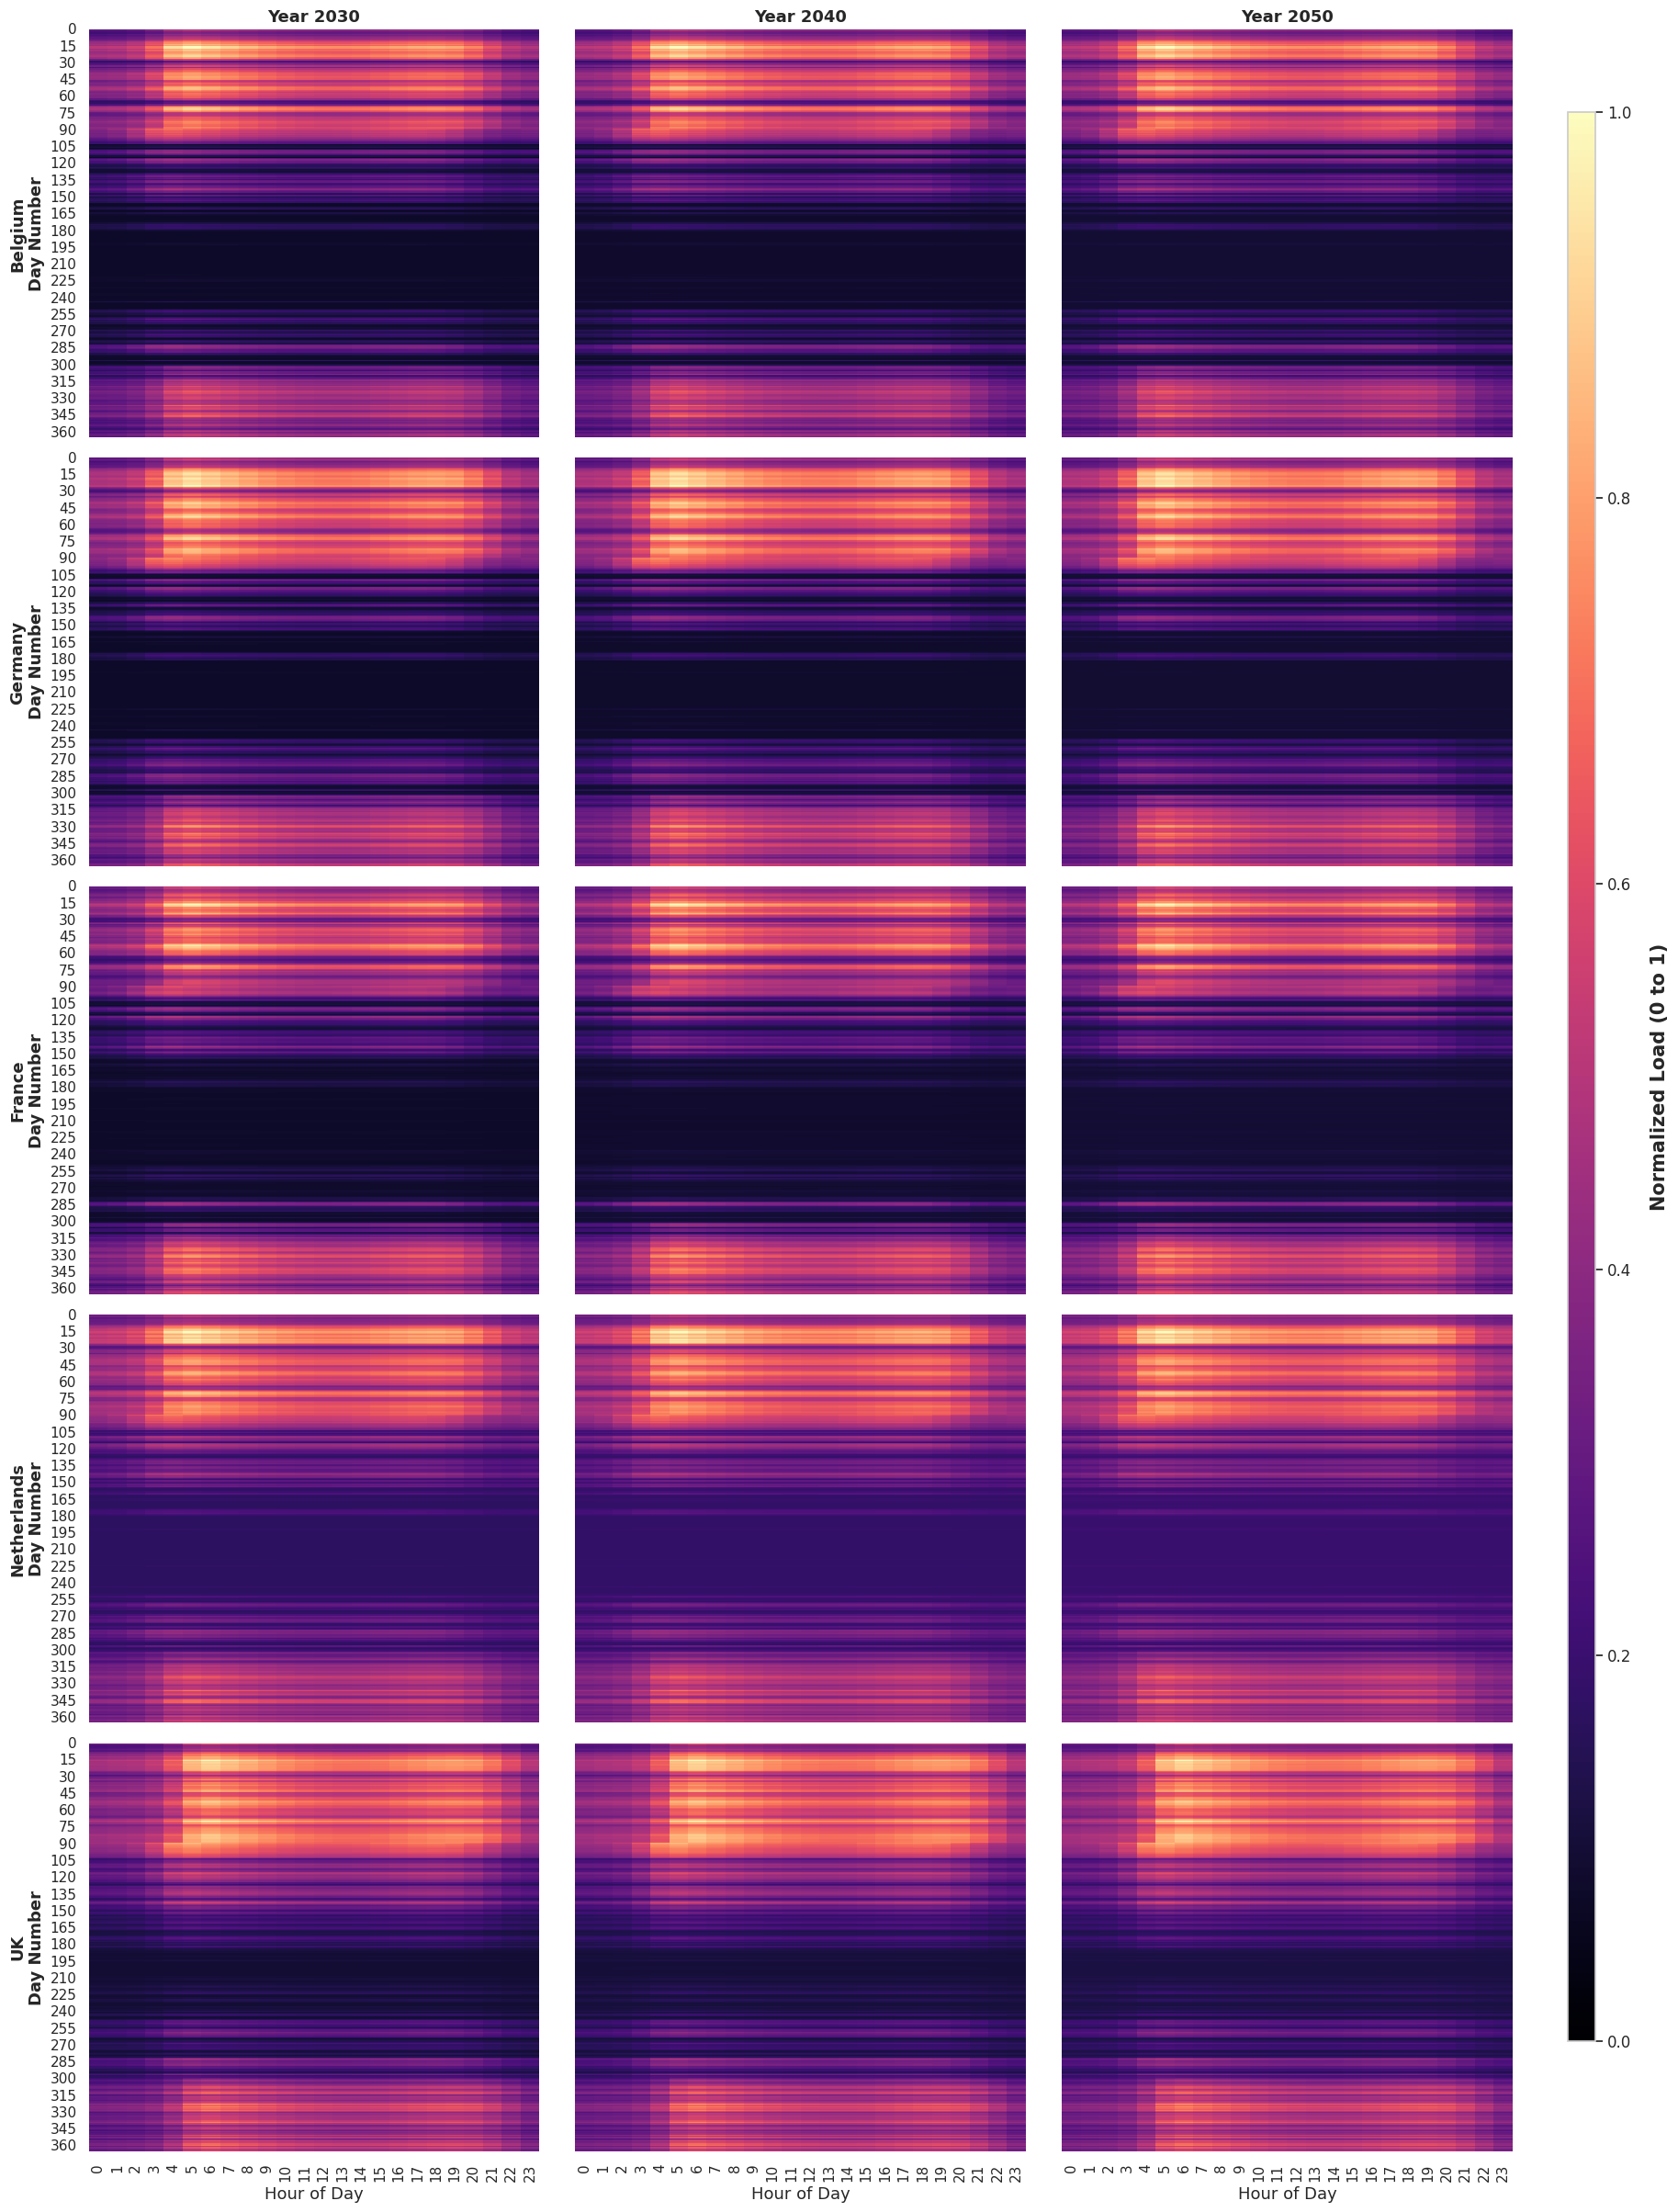

Successfully saved: /home/ray/Downloads/LoadHeatmaps/Heat_demand/Suficiency_Scenario_Load_Heatmaps.pdf


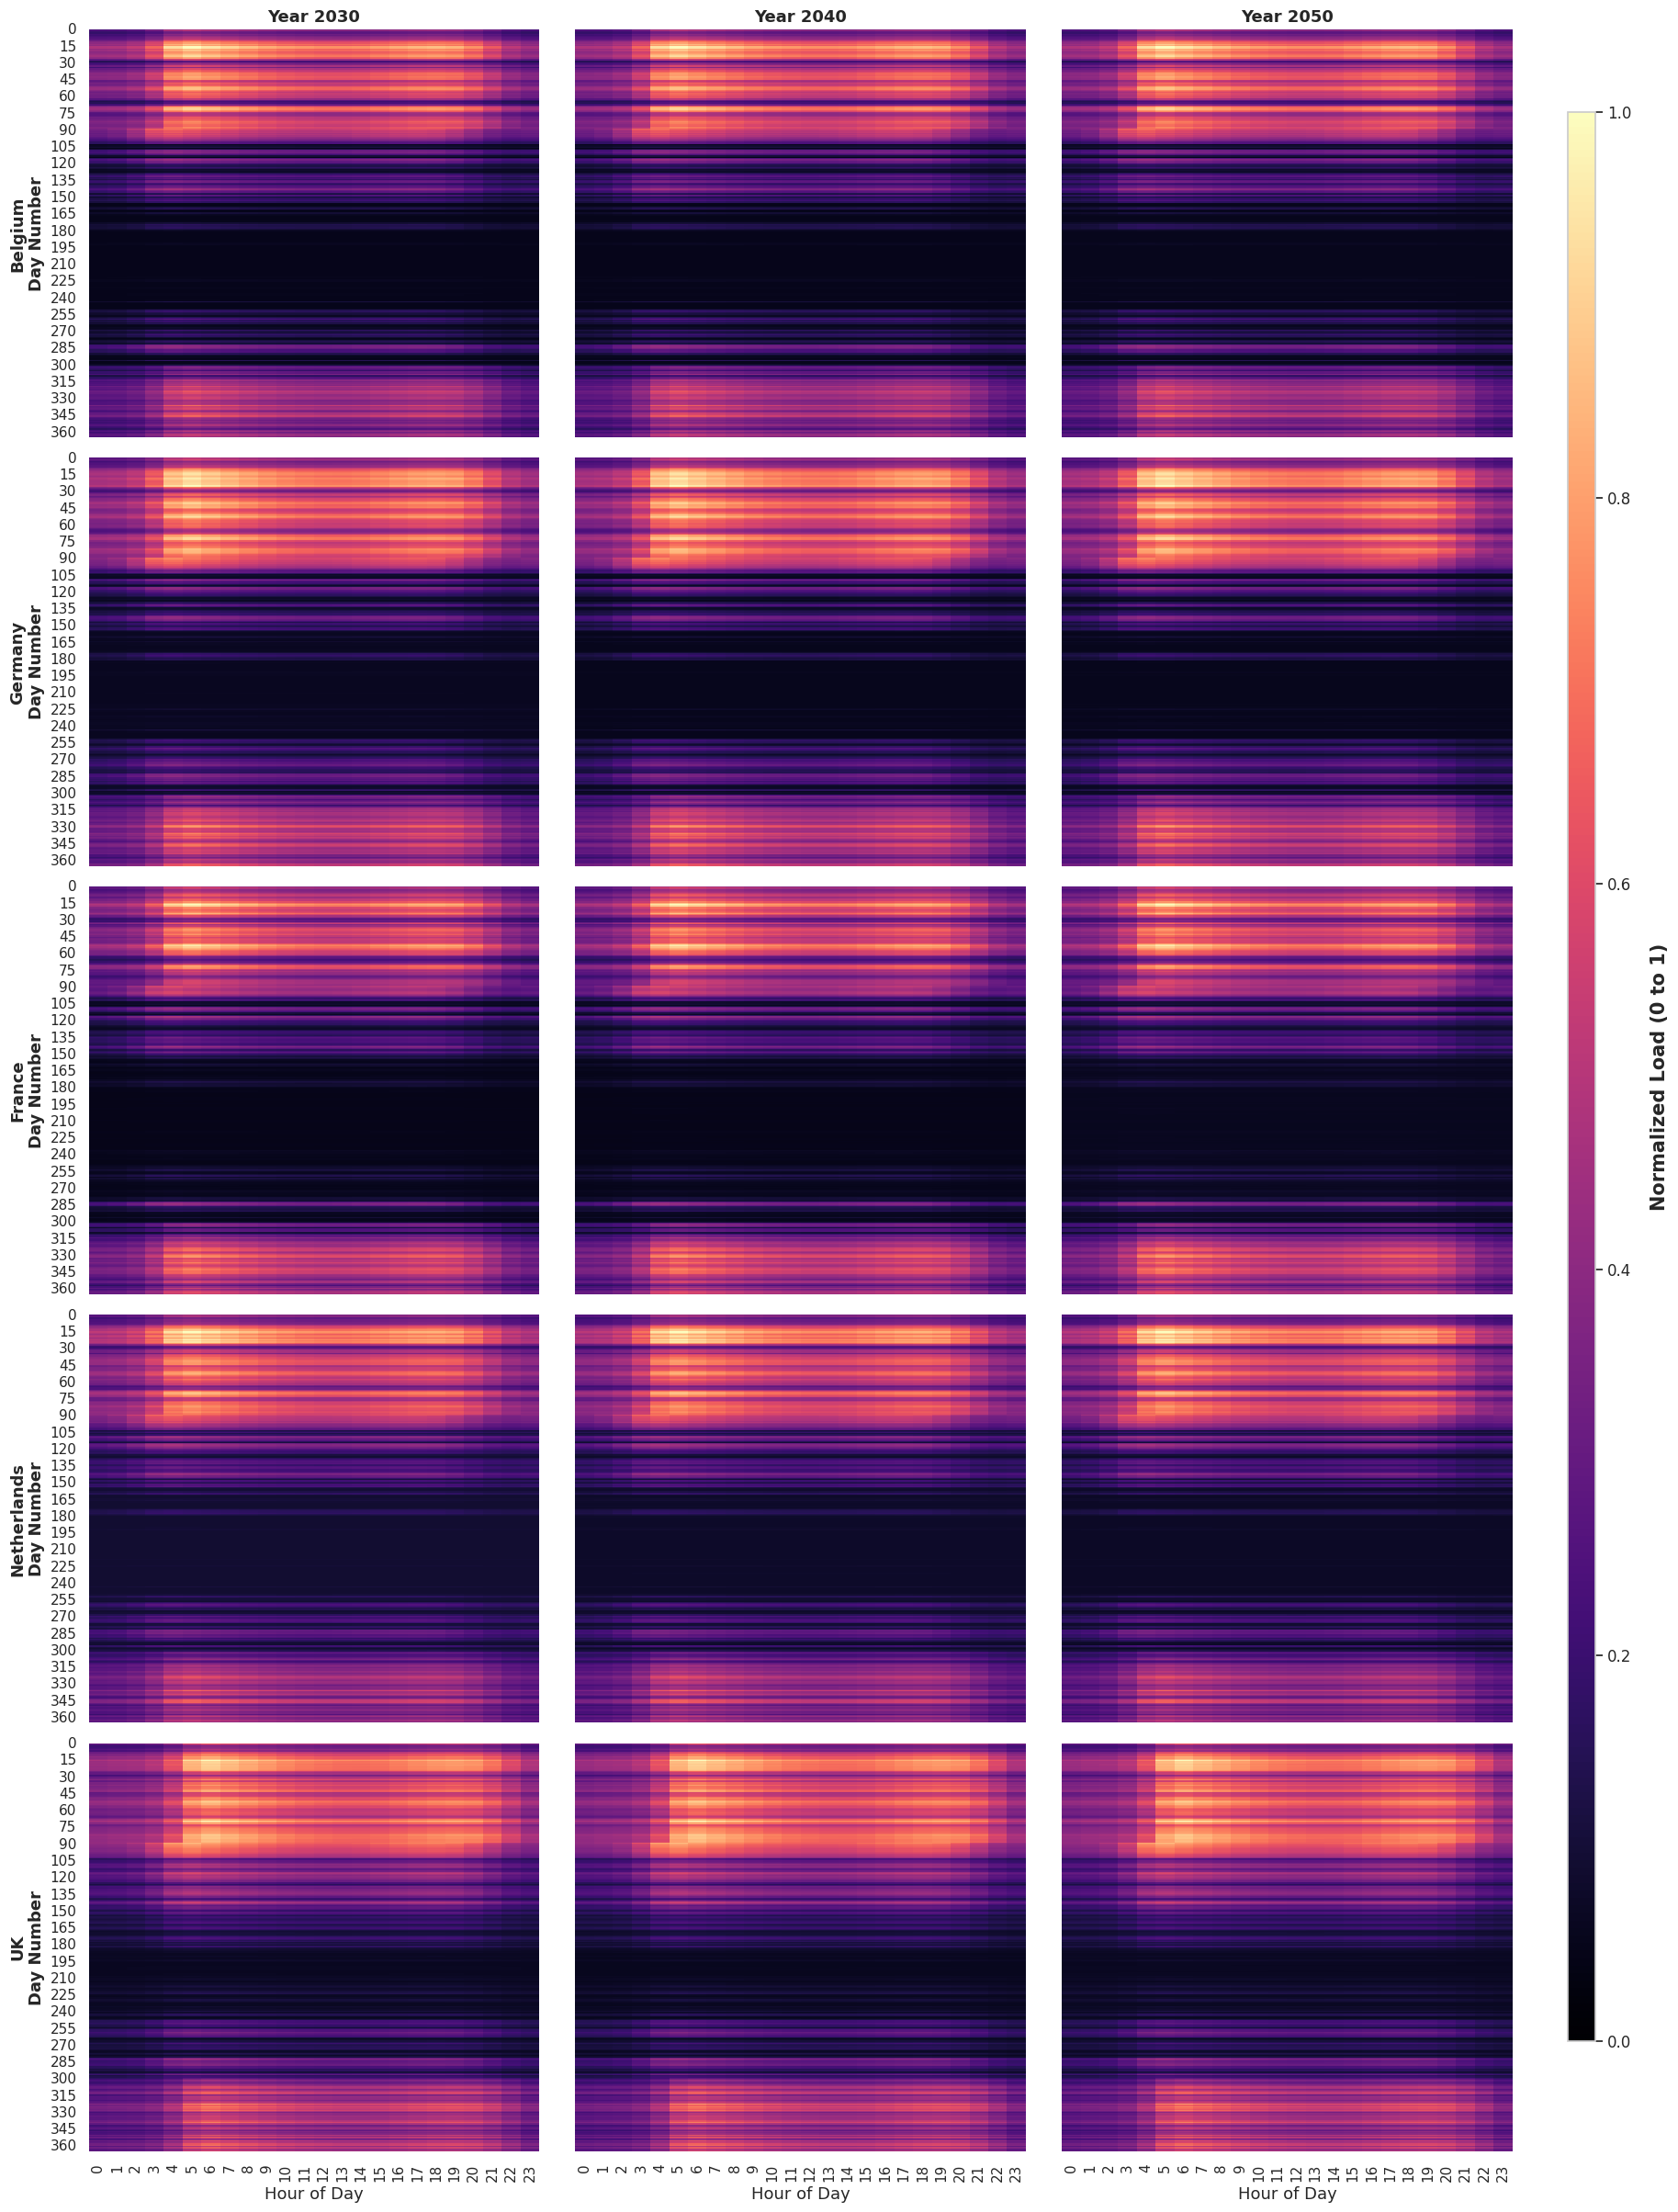

In [87]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. SETUP DIRECTORIES
output_dir = "/home/ray/Downloads/LoadHeatmaps/Heat_demand"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

scenarios = {
    'Reference_Scenario': {
        'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/Heat_demand/BE/1h/',
        'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/Heat_demand/DE/1h/',
        'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/Heat_demand/FR/1h/',
        'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/Heat_demand/NL/1h/',
        'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/Heat_demand/UK/1h/',
    },
    'Suficiency_Scenario': {
        'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Sufficiency_Scenario/Heat_demand/BE/1h/',
        'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Sufficiency_Scenario/Heat_demand/DE/1h/',
        'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Sufficiency_Scenario/Heat_demand/FR/1h/',
        'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Sufficiency_Scenario/Heat_demand/NL/1h/',
        'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Sufficiency_Scenario/Heat_demand/UK/1h/',
    }
}

years = [2030, 2040, 2050]

# 2. GENERATE PLOTS
for scen_name, countries in scenarios.items():
    n_rows = len(countries)
    n_cols = len(years)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows), sharex=True, sharey=True)
    
    for r, (country, path) in enumerate(countries.items()):
        for c, year in enumerate(years):
            file_path = os.path.join(path, f"{year}.csv")
            ax = axes[r, c]
            
            if os.path.exists(file_path):
                df = pd.read_csv(file_path, sep=',', header=None)
                
                # Using 0-1 Normalization based on each plot's peak
                df['val'] = df[1] / df[1].max()
                
                # Standardization to 8760 hours (non-leap) to ensure 365 rows
                pivot = df['val'].values[:8760].reshape(-1, 24)
                
                sns.heatmap(pivot, ax=ax, cmap='magma', vmin=0, vmax=1, cbar=False)
                
                if r == 0:
                    ax.set_title(f"Year {year}", fontsize=13, fontweight='bold')
                if c == 0:
                    ax.set_ylabel(f"{country}\nDay Number", fontsize=13, fontweight='bold')
                if r == n_rows - 1:
                    ax.set_xlabel("Hour of Day", fontsize=13)
            else:
                ax.text(0.5, 0.5, 'Data Missing', ha='center')
                ax.axis('off')

    # Unified Colorbar
    cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
    sm = plt.cm.ScalarMappable(cmap='magma', norm=plt.Normalize(vmin=0, vmax=1))
    
    # Increased font sizes here
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Normalized Load (0 to 1)', size=15, fontweight='bold', labelpad=15)
    cbar.ax.tick_params(labelsize=12) # Size of the numbers 0.2, 0.4, etc.

    # Ensure suptitle is adjusted or removed as per your commented line
    # plt.suptitle(f"Hourly Load Intensity: {scen_name.replace('_', ' ')}", fontsize=26, y=0.98)
    plt.subplots_adjust(right=0.90, hspace=0.05, wspace=0.08)

    
    # 3. SAVE AS PDF
    pdf_path = os.path.join(output_dir, f"{scen_name}_Load_Heatmaps.pdf")
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
    print(f"Successfully saved: {pdf_path}")
    
    plt.show()

In [79]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np

scenarios = {
    'Reference_Scenario': {
        'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/Ammonia_demand/BE/1h/',
        'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/Ammonia_demand/DE/1h/',
        'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/Ammonia_demand/FR/1h/',
        'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/Ammonia_demand/NL/1h/',
        'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/Ammonia_demand/UK/1h/',
    },
    'Suficiency_Scenario': {
        'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/Ammonia_demand/BE/1h/',
        'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/Ammonia_demand/DE/1h/',
        'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/Ammonia_demand/FR/1h/',
        'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/Ammonia_demand/NL/1h/',
        'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/Ammonia_demand/UK/1h/',
    }
}

years = [2030, 2040, 2050]

import pandas as pd
import os
import numpy as np

# ... (keep your scenarios dictionary and years list here) ...

print(f"{'Scenario':<25} | {'Country':<12} | {'Year':<6} | {'Identical Pattern?'}")
print("-" * 70)

for scen_name, countries in scenarios.items():
    for country_name, base_path in countries.items():
        # Load 2030 as the baseline
        file_2030 = os.path.join(base_path, "2030.csv")
        if not os.path.exists(file_2030): continue
        
        base_data = pd.read_csv(file_2030, header=None)[1].values

        for year in [2040, 2050]:
            file_path = os.path.join(base_path, f"{year}.csv")
            if os.path.exists(file_path):
                comp_data = pd.read_csv(file_path, header=None)[1].values
                
                # Handle potential leap year differences (truncate to 8760 hours)
                min_len = min(len(base_data), len(comp_data))
                
                # Calculate the ratio hour-by-hour
                ratios = comp_data[:min_len] / base_data[:min_len]
                
                # If the standard deviation of the ratios is near zero, it's the same pattern
                std_dev = np.std(ratios)
                is_identical = std_dev < 1e-6 # Using a tiny threimport pandas as pd
import matplotlib.pyplot as plt
import os

# 1. SETUP OUTPUT DIRECTORY
output_dir = "/home/ray/Downloads/LoadHeatmaps/H2_Demand"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# (Use your existing scenarios dictionary for H2 paths here)
# For H2, we only need one value per file since they are constant
plot_data = []

for scen_name, countries in scenarios.items():
    for country, path in countries.items():
        for year in [2030, 2040, 2050]:
            file_path = os.path.join(path, f"{year}.csv")
            if os.path.exists(file_path):
                # We just need the first value since it's constant
                val = pd.read_csv(file_path, header=None).iloc[0, 1]
                plot_data.append({
                    'Scenario': scen_name.replace('_', ' '),
                    'Country': country,
                    'Year': str(year),
                    'Demand': val
                })

df_plot = pd.DataFrame(plot_data)

# 2. PLOTTING
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for i, scen in enumerate(df_plot['Scenario'].unique()):
    subset = df_plot[df_plot['Scenario'] == scen]
    
    # Pivot for easier bar plotting
    pivot_data = subset.pivot(index='Country', columns='Year', values='Demand')
    pivot_data.plot(kind='bar', ax=axes[i], zorder=3)
    
    axes[i].set_title(f"H2 Demand: {scen}", fontsize=14, fontweight='bold')
    axes[i].set_ylabel("Constant Demand Value", fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
    axes[i].legend(title="Year")

plt.xticks(rotation=0)
plt.tight_layout()

# 3. SAVE AS PDF
pdf_path = os.path.join(output_dir, "H2_Demand_Comparison.pdf")
plt.savefig(pdf_path, format='pdf')
plt.show()

print(f"H2 Summary saved to: {pdf_path}")shold for float precision
                
                status = "YES (Perfect Scale)" if is_identical else f"NO (Pattern varies by {std_dev:.4f})"
                print(f"{scen_name[:25]:<25} | {country_name:<12} | {year:<6} | {status}")

SyntaxError: invalid syntax (1536273004.py, line 108)

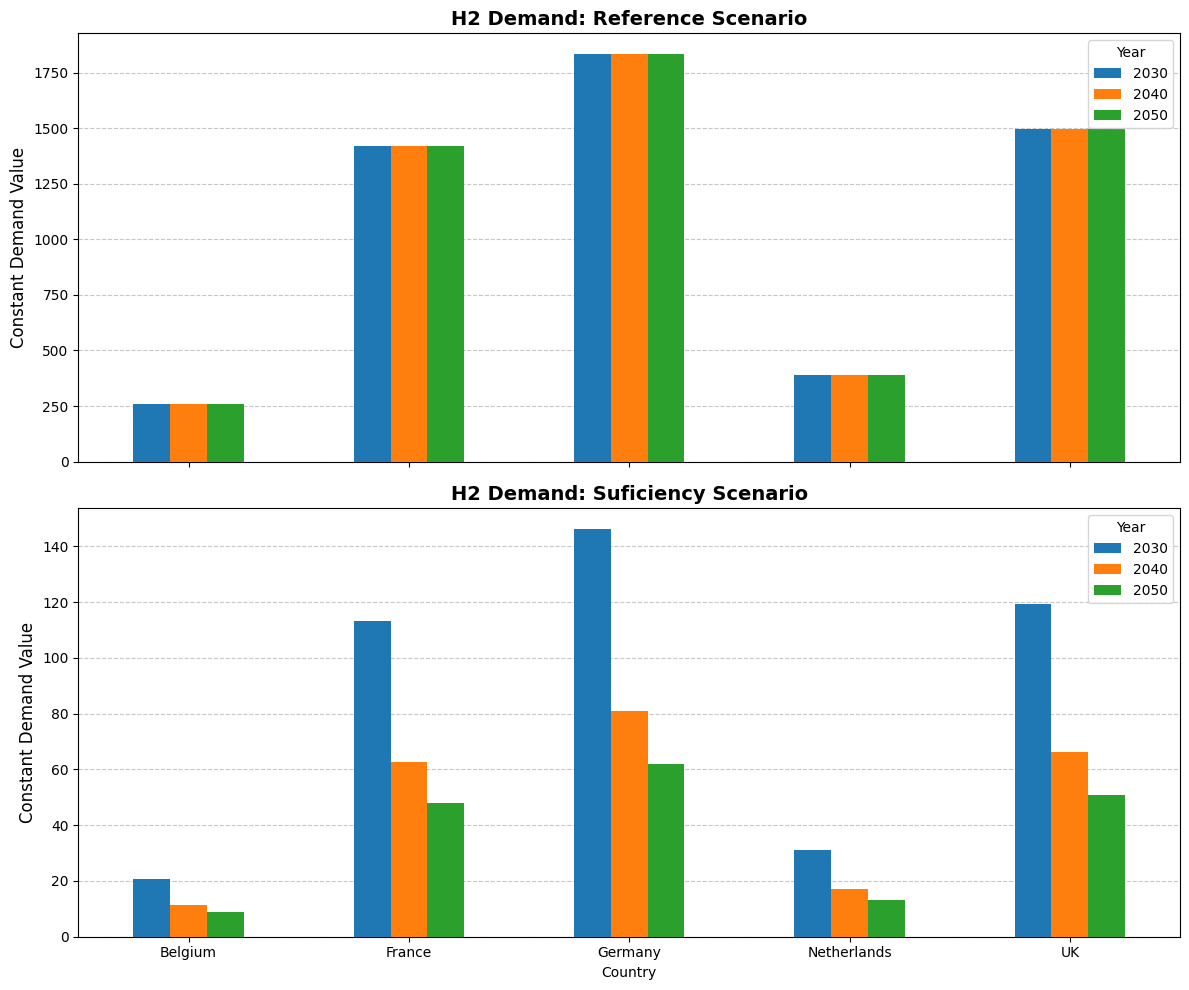

H2 Summary saved to: /home/ray/Downloads/LoadHeatmaps/Ammonia_demand/H2_Demand_Comparison.pdf


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. SETUP OUTPUT DIRECTORY
output_dir = "/home/ray/Downloads/LoadHeatmaps/Ammonia_demand"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

scenarios = {
    'Reference_Scenario': {
        'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/Ammonia_demand/BE/1h/',
        'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/Ammonia_demand/DE/1h/',
        'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/Ammonia_demand/FR/1h/',
        'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/Ammonia_demand/NL/1h/',
        'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/Ammonia_demand/UK/1h/',
    },
    'Suficiency_Scenario': {
        'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/Ammonia_demand/BE/1h/',
        'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/Ammonia_demand/DE/1h/',
        'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/Ammonia_demand/FR/1h/',
        'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/Ammonia_demand/NL/1h/',
        'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/Ammonia_demand/UK/1h/',
    }
}
plot_data = []

for scen_name, countries in scenarios.items():
    for country, path in countries.items():
        for year in [2030, 2040, 2050]:
            file_path = os.path.join(path, f"{year}.csv")
            if os.path.exists(file_path):
                # We just need the first value since it's constant
                val = pd.read_csv(file_path, header=None).iloc[0, 1]
                plot_data.append({
                    'Scenario': scen_name.replace('_', ' '),
                    'Country': country,
                    'Year': str(year),
                    'Demand': val
                })

df_plot = pd.DataFrame(plot_data)

# 2. PLOTTING
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for i, scen in enumerate(df_plot['Scenario'].unique()):
    subset = df_plot[df_plot['Scenario'] == scen]
    
    # Pivot for easier bar plotting
    pivot_data = subset.pivot(index='Country', columns='Year', values='Demand')
    pivot_data.plot(kind='bar', ax=axes[i], zorder=3)
    
    axes[i].set_title(f"H2 Demand: {scen}", fontsize=14, fontweight='bold')
    axes[i].set_ylabel("Constant Demand Value", fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
    axes[i].legend(title="Year")

plt.xticks(rotation=0)
plt.tight_layout()

# 3. SAVE AS PDF
pdf_path = os.path.join(output_dir, "H2_Demand_Comparison.pdf")
plt.savefig(pdf_path, format='pdf')
plt.show()

print(f"H2 Summary saved to: {pdf_path}")

In [56]:
import pandas as pd
import os

# 1. SETUP PARAMETERS
base_dir = "/home/ray/Dispa-SET_Unleash/Database_PyPSA"
scenarios = ["Reference_Scenario", "Sufficiency_Scenario"]
countries = ["BE", "DE", "FR", "NL", "UK"]
demands = ["Load_RealTime", "Heat_demand", "H2_demand", "Methanol_demand", "Ammonia_demand"]
years = [2030, 2040, 2050]

results = []

# 2. ITERATE THROUGH ALL FILES
for scen in scenarios:
    for country in countries:
        for demand in demands:
            folder_path = os.path.join(base_dir, scen, demand, country, "1h")
            
            for year in years:
                file_name = f"{year}.csv"
                file_path = os.path.join(folder_path, file_name)
                
                if os.path.exists(file_path):
                    try:
                        # Auto-detect separator (comma vs space)
                        df = pd.read_csv(file_path, header=None, sep=None, engine='python')
                        
                        # Extract the data column (assuming index 1 based on previous files)
                        data_series = df[1]
                        
                        results.append({
                            "Scenario": scen,
                            "Country": country,
                            "Demand_Type": demand,
                            "Year": year,
                            "Average": data_series.mean(),
                            "Maximum": data_series.max(),
                            "Minimum": data_series.min()
                        })
                    except Exception as e:
                        print(f"Error processing {file_path}: {e}")

# 3. CREATE DATA FRAME
final_df = pd.DataFrame(results)

# 4. PIVOT FOR BETTER VIEWING
# This creates a MultiIndex column structure: (Year) -> (Average, Maximum, Minimum)
pivot_table = final_df.pivot_table(
    index=["Scenario", "Country", "Demand_Type"], 
    columns="Year", 
    values=["Average", "Maximum", "Minimum"]
)

# Reordering columns so stats are grouped by Year
pivot_table = pivot_table.reorder_levels([1, 0], axis=1).sort_index(axis=1)

# 5. SAVE AND DISPLAY
output_path = "/home/ray/Downloads/LoadHeatmaps/Demand_Full_Stats.csv"
pivot_table.to_csv(output_path)

print("-" * 50)
print("DEMAND STATISTICS SUMMARY (BE, DE, FR, NL, UK)")
print("-" * 50)
# Showing a snippet of the result
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(pivot_table.head(15)) 

print(f"\nFull statistics table saved to: {output_path}")

--------------------------------------------------
DEMAND STATISTICS SUMMARY (BE, DE, FR, NL, UK)
--------------------------------------------------
Year                                                2030                                       2040                                       2050                             
                                                 Average        Maximum       Minimum       Average        Maximum       Minimum       Average        Maximum       Minimum
Scenario           Country Demand_Type                                                                                                                                     
Reference_Scenario BE      Ammonia_demand     257.675022     257.675022    257.675022    257.675022     257.675022    257.675022    257.675022     257.675022    257.675022
                           H2_demand          487.302419     487.302419    487.302419    651.264471     651.264471    651.264471    876.448849     876.448849    87

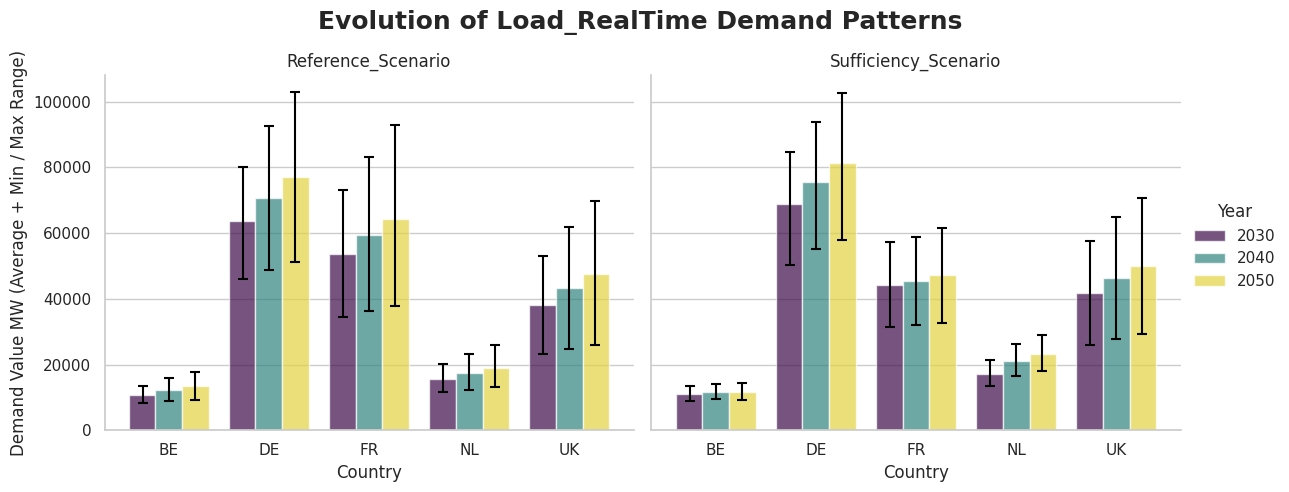

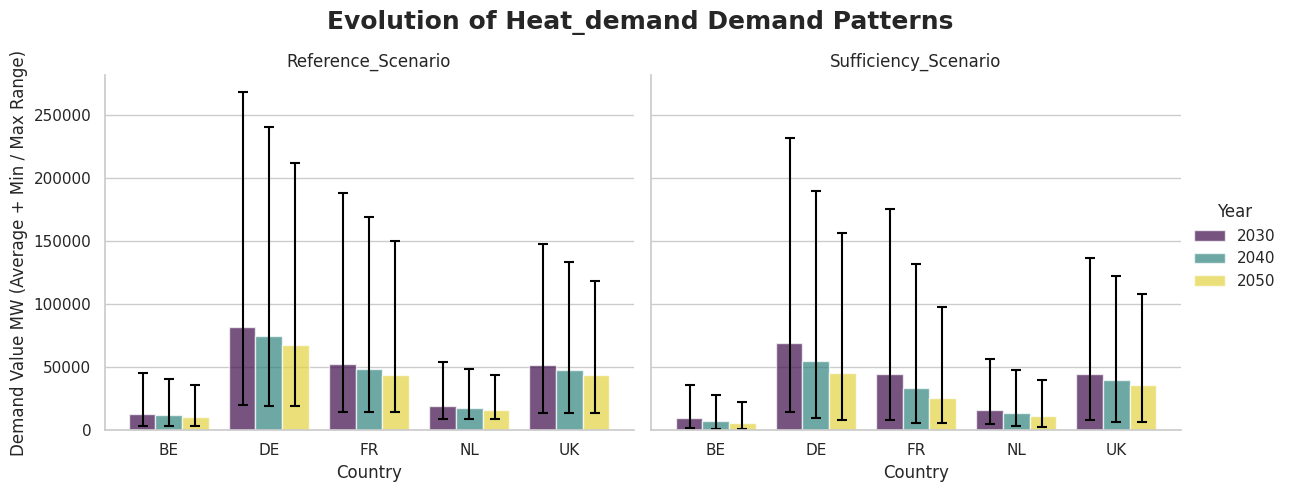

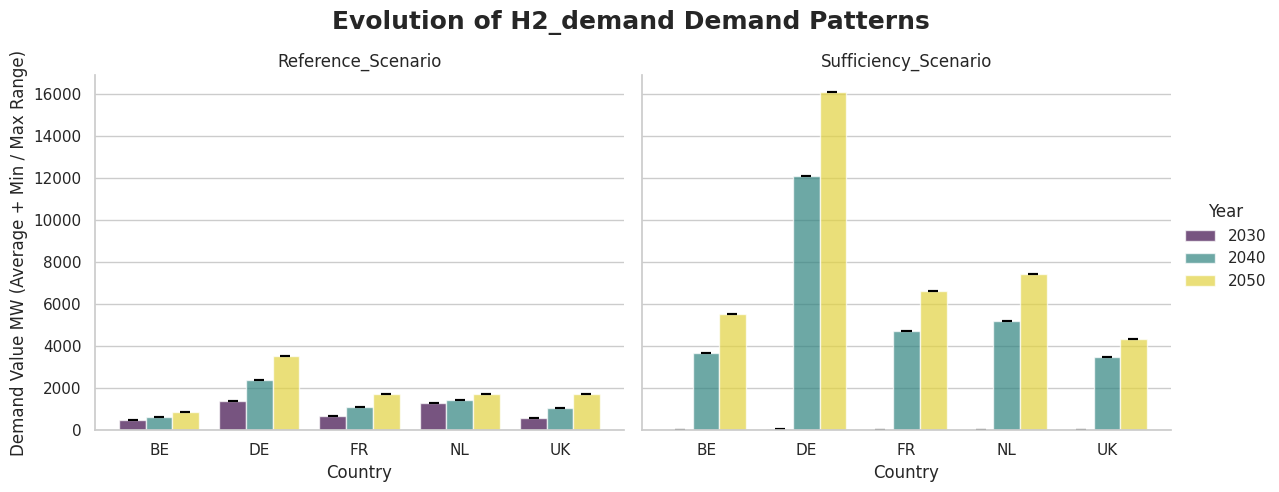

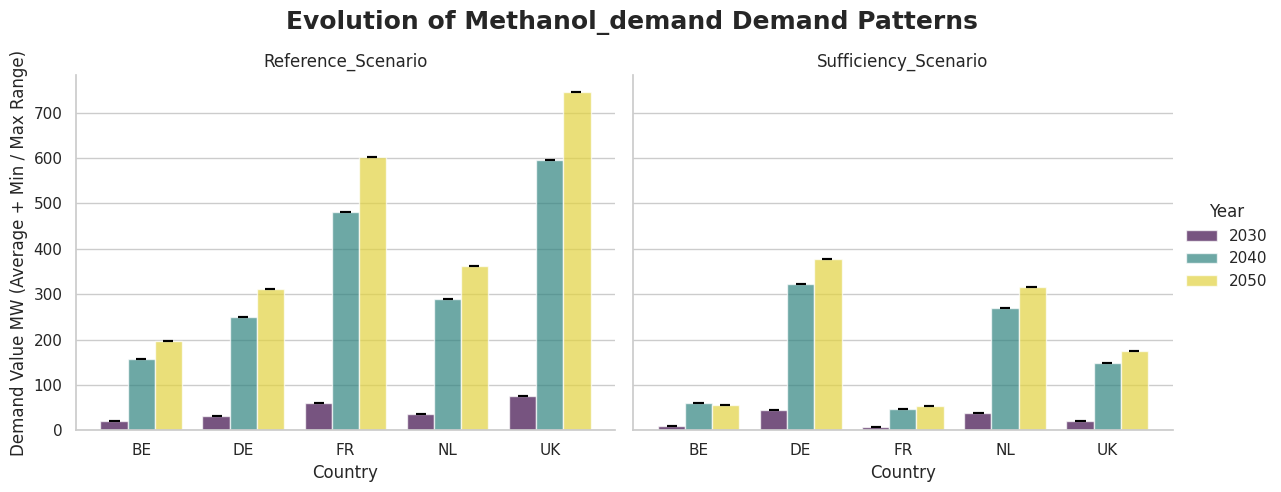

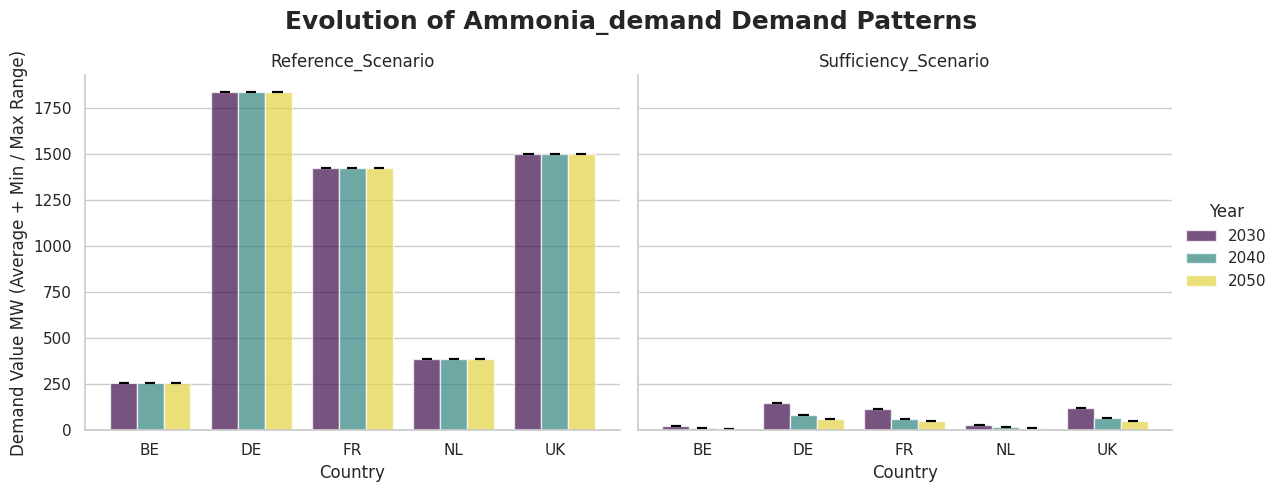

Visual summaries saved to: /home/ray/Downloads/LoadHeatmaps/Visual_Summaries


In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Assuming 'final_df' is the DataFrame created in the previous step
# If not, ensure final_df has columns: Scenario, Country, Demand_Type, Year, Average, Maximum, Minimum

output_dir = "/home/ray/Downloads/LoadHeatmaps/Visual_Summaries"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Set styling
sns.set_theme(style="whitegrid")

for demand in final_df['Demand_Type'].unique():
    subset = final_df[final_df['Demand_Type'] == demand]
    
    # Create the plot: 2 Rows (Reference vs Sufficiency)
    g = sns.catplot(
        data=subset, kind="bar",
        x="Country", y="Average", hue="Year",
        col="Scenario", palette="viridis", alpha=0.7,
        height=5, aspect=1.2
    )

    # Add the Min-Max whiskers manually
    for ax_idx, ax in enumerate(g.axes.flat):
        scen = subset['Scenario'].unique()[ax_idx]
        scen_subset = subset[subset['Scenario'] == scen]
        
        # Determine the positions of the bars on the X-axis
        # This is a bit technical but ensures whiskers land exactly on the bars
        for i, year in enumerate(years):
            year_data = scen_subset[scen_subset['Year'] == year]
            
            # X positions for grouped bars in Seaborn
            # (Country index + offset for the hue)
            offsets = [-0.26, 0, 0.26] # Standard offsets for 3 grouped bars
            
            for j, country in enumerate(countries):
                row = year_data[year_data['Country'] == country]
                if not row.empty:
                    x_pos = j + offsets[i]
                    ax.vlines(x_pos, row['Minimum'].values[0], row['Maximum'].values[0], 
                              color='black', linestyle='-', linewidth=1.5, label='Min-Max Range' if i+j==0 else "")
                    # Add caps to the whiskers
                    ax.hlines([row['Minimum'].values[0], row['Maximum'].values[0]], 
                              x_pos-0.05, x_pos+0.05, color='black')

    g.set_axis_labels("Country", f"Demand Value MW (Average + Min / Max Range)")
    g.set_titles("{col_name}")
    plt.subplots_adjust(top=0.85)
    g.fig.suptitle(f"Evolution of {demand} Demand Patterns", fontsize=18, fontweight='bold')
#    g.fig.suptitle(f"Annual Demand Statistics: {demand} (MW)", fontsize=18, fontweight='bold')


    # Save each demand type to a PDF
    plt.savefig(os.path.join(output_dir, f"{demand}_Summary.pdf"), bbox_inches='tight')
    plt.show()

print(f"Visual summaries saved to: {output_dir}")

Successfully saved plot for Load_RealTime to: /home/ray/Downloads/LoadHeatmaps/Summary_Statistics_Plots/Summary_Load_RealTime.pdf


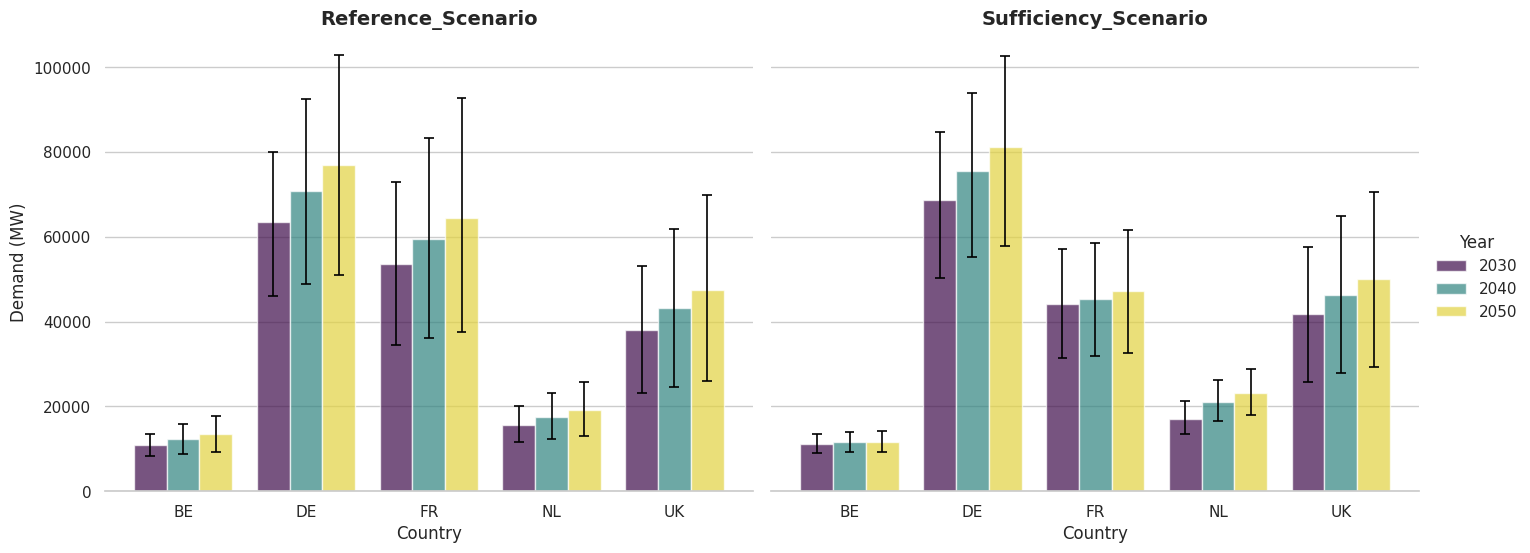

Successfully saved plot for Heat_demand to: /home/ray/Downloads/LoadHeatmaps/Summary_Statistics_Plots/Summary_Heat_demand.pdf


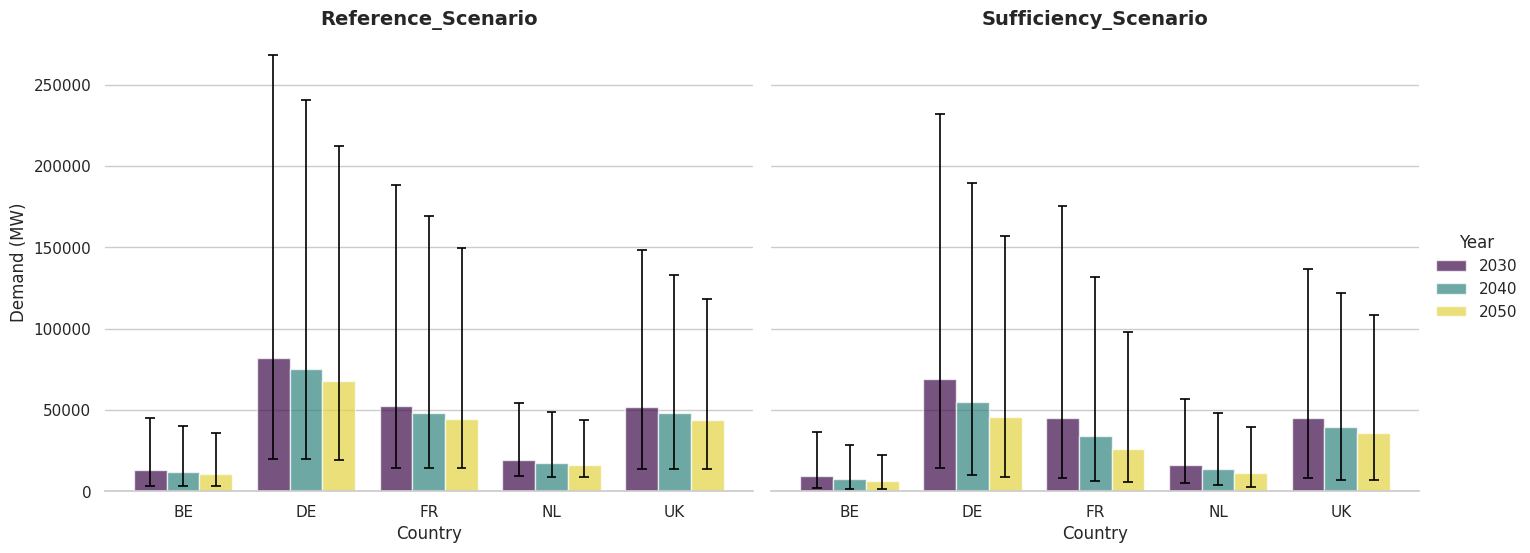

Successfully saved plot for H2_demand to: /home/ray/Downloads/LoadHeatmaps/Summary_Statistics_Plots/Summary_H2_demand.pdf


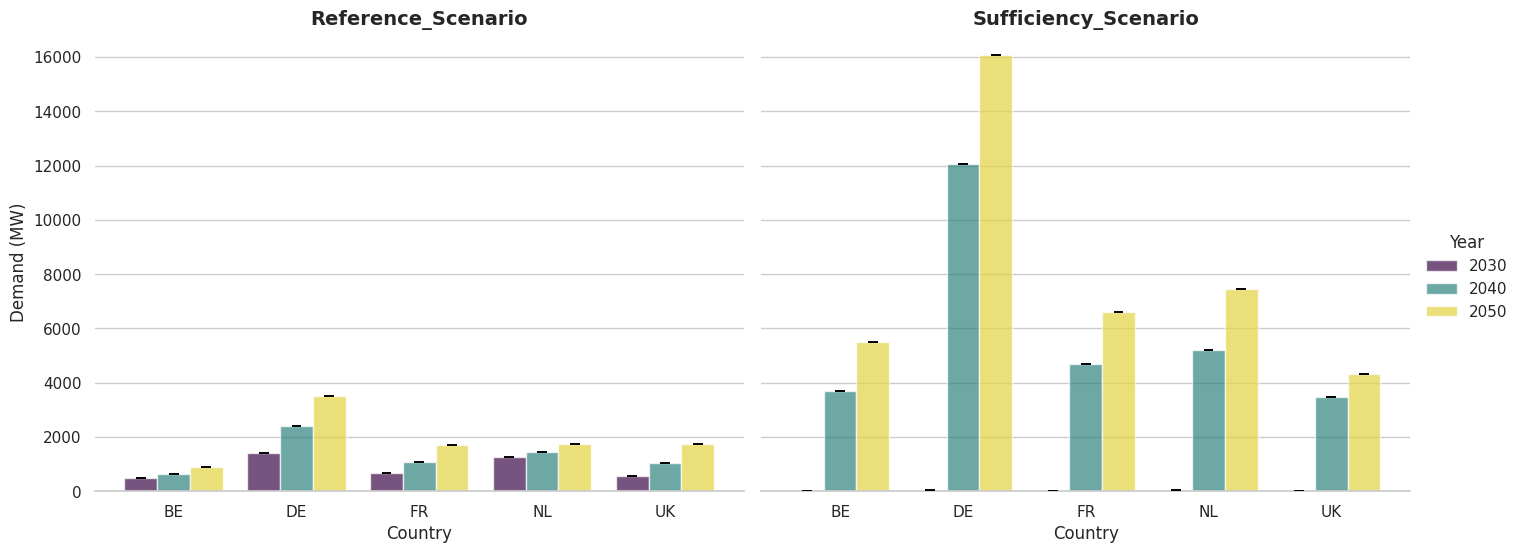

Successfully saved plot for Methanol_demand to: /home/ray/Downloads/LoadHeatmaps/Summary_Statistics_Plots/Summary_Methanol_demand.pdf


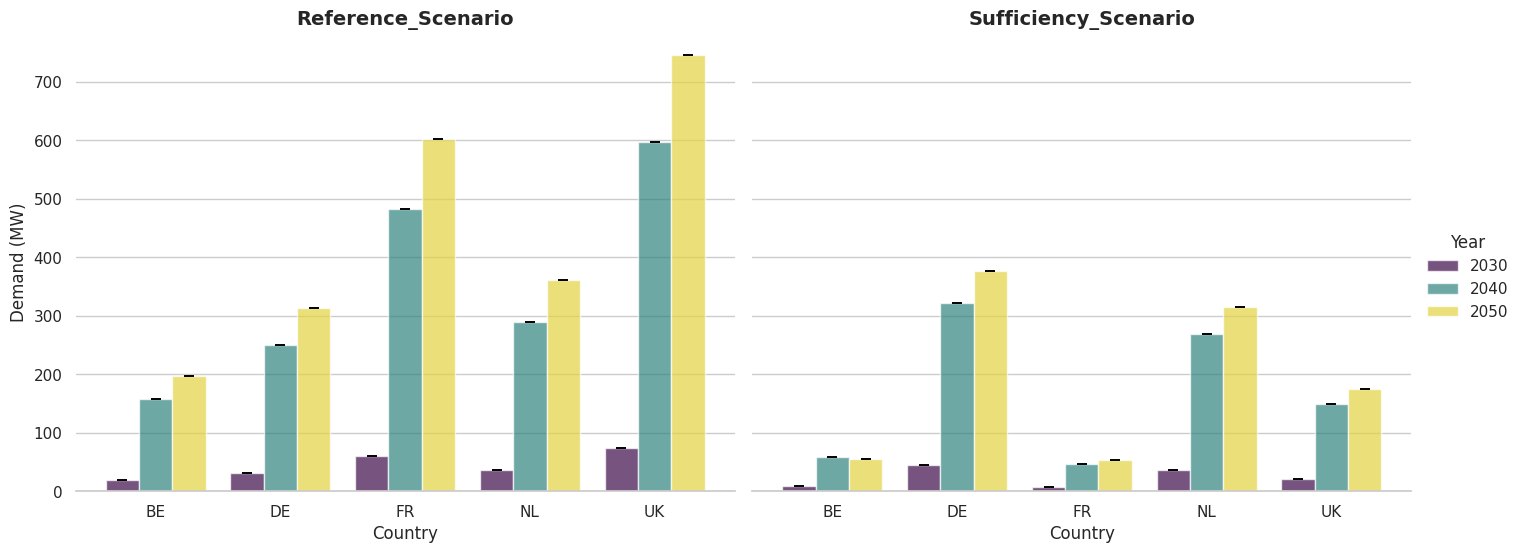

Successfully saved plot for Ammonia_demand to: /home/ray/Downloads/LoadHeatmaps/Summary_Statistics_Plots/Summary_Ammonia_demand.pdf


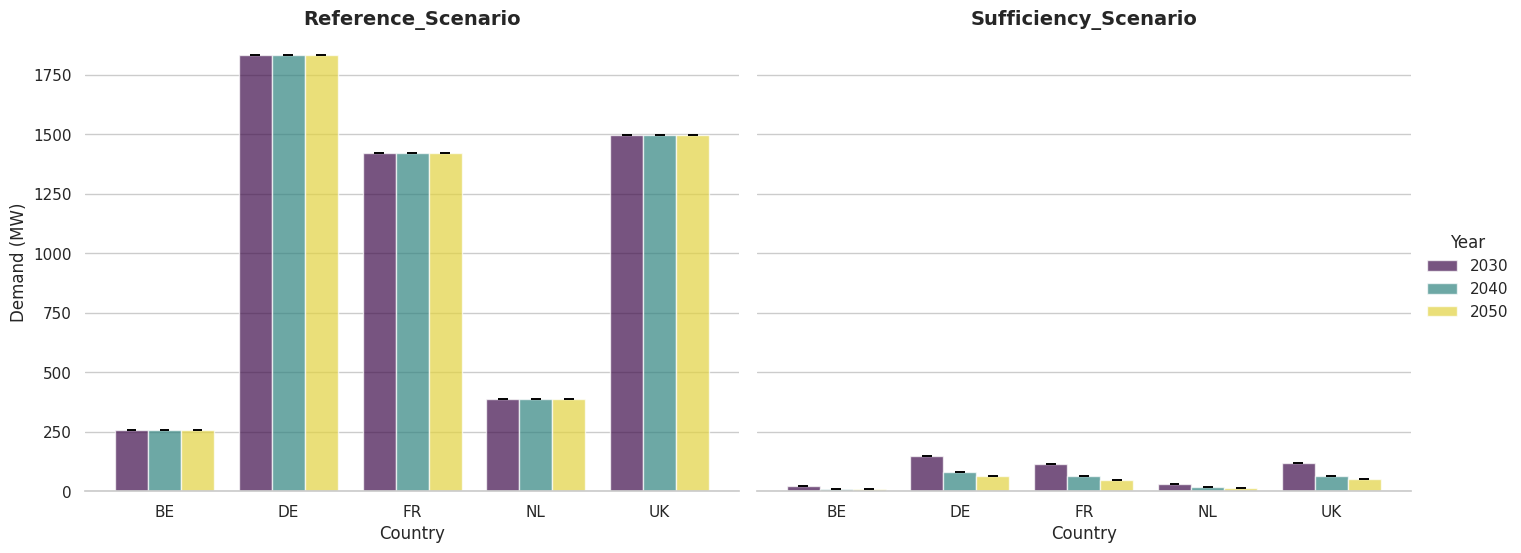

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. SETUP OUTPUT DIRECTORY
output_dir = "/home/ray/Downloads/LoadHeatmaps/Summary_Statistics_Plots"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 2. PLOTTING LOOP
# (This assumes 'final_df' from the previous step is in memory)
# final_df contains: Scenario, Country, Demand_Type, Year, Average, Maximum, Minimum

sns.set_theme(style="whitegrid")
years = sorted(final_df['Year'].unique())
countries = ["BE", "DE", "FR", "NL", "UK"]

for demand in final_df['Demand_Type'].unique():
    subset = final_df[final_df['Demand_Type'] == demand]
    
    # Create the FacetGrid: Reference vs Sufficiency
    g = sns.catplot(
        data=subset, kind="bar",
        x="Country", y="Average", hue="Year",
        col="Scenario", palette="viridis", alpha=0.7,
        height=6, aspect=1.2, order=countries
    )

    # 3. ADD CUSTOM MIN-MAX WHISKERS
    # Seaborn bars are positioned at integer locations with offsets for the 'hue' (Year)
    for ax_idx, ax in enumerate(g.axes.flat):
        scen = subset['Scenario'].unique()[ax_idx]
        scen_subset = subset[subset['Scenario'] == scen]
        
        # Offsets for 3 bars (2030, 2040, 2050)
        width = 0.8 / len(years) 
        offsets = [ (i - (len(years)-1)/2) * width for i in range(len(years)) ]
        
        for i, year in enumerate(years):
            year_data = scen_subset[scen_subset['Year'] == year]
            
            for j, country in enumerate(countries):
                row = year_data[year_data['Country'] == country]
                if not row.empty:
                    x_pos = j + offsets[i]
                    # Draw vertical line from Min to Max
                    ax.vlines(x_pos, row['Minimum'].values[0], row['Maximum'].values[0], 
                              color='black', linestyle='-', linewidth=1.2, zorder=5)
                    # Add small horizontal caps at the ends
                    ax.hlines([row['Minimum'].values[0], row['Maximum'].values[0]], 
                              x_pos-0.04, x_pos+0.04, color='black', linewidth=1.2, zorder=5)

    # 4. FINAL FORMATTING
    g.set_axis_labels("Country", "Demand (MW)")
    g.set_titles("{col_name}", size=14, weight='bold')
    g.despine(left=True)
    
    plt.subplots_adjust(top=0.88)
#    g.fig.suptitle(f"Annual Demand Statistics: {demand} (MW)", fontsize=18, fontweight='bold')

    # 5. SAVE AS PDF
    file_name = f"Summary_{demand}.pdf"
    save_path = os.path.join(output_dir, file_name)
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    
    print(f"Successfully saved plot for {demand} to: {save_path}")
    plt.show()